# OR–odorant functional landscape

Two activation matrices, each clustered (Jaccard + PAM, k=6) with hypergeometric + BH enrichment:

- **hybrid_density** — M2OR ground truth over a **density-calibrated, rank-based** fill ← main matrix
- **baseline** — predictions at the model default, p ≥ 0.50 (supplementary, for reference)

`hybrid_density` is the main matrix and its figures render inline. `baseline` is written to
`Figures/` only.

**How the main matrix is built.** Earlier versions thresholded the whole grid at the
rate-matched cut (~0.915). That cut is a *classification* threshold: it is the right number
to report for per-pair model performance, and `01.model_behaviour` still reports it there.
It is the wrong tool for filling a grid, because recall at that cut is ~0.6 — so roughly 40%
of real binders are dropped and the matrix comes out systematically under-filled.

`hybrid_density` separates the two questions. *How many* cells should be on is answered by
calibration (isotonic regression, fitted once on the tested cells); *which* cells are on is
answered by rank. The density cut is an **output** of that procedure, never a chosen input.
See `../../scripts/calibration.py`.

In [192]:
import numpy as np, pandas as pd, matplotlib, re
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import hypergeom, mannwhitneyu
from collections import Counter
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors, Lipinski
np.random.seed(0)

import sys
sys.path.append("../../scripts")
sys.path.append("../../../scripts")
from plotting_functions import custom_plots, FIGSIZE
plt.rcParams.update(custom_plots())

PROB   = "../../predictions/aggregated/Reference_Tree_Predictions/reference_median_probability_wide.csv"
PAIRS  = "../../../Model_Inputs/Data_Preparation/processed/m2or_pairs_model.csv"   # smiles_id <-> SMILES, experimental Responsive, Sequence
ODORS  = "../../../Chemicals/odor_datasets/inchi_odors_smiles.csv"   # SMILES -> Odors
FASTA  = "../../../Phylogenetic_Analysis/data/ReferenceTree/PF13853.9606_7955_7740_7764_75743_137246.fa"
CLASSES= "../../../Phylogenetic_Analysis/data/HumanTree/human433_OR_classes.csv"
TREE   = "../../../Phylogenetic_Analysis/data/HumanTree/human433_MFP_reorder.tree"
CLASS_I_COL='#7f1734'; CLASS_II_COL='#557c99'
OUTDIR = 'Figures'
K = 6

## 1 · Data: probability matrix, human ORs

In [193]:
import os; os.makedirs(OUTDIR, exist_ok=True)
prob=pd.read_csv(PROB,index_col=0)
hum_pids=[i for i in prob.index if str(i).startswith('9606')]
P=prob.loc[hum_pids]; lig_cols=list(P.columns); Pv=P.values
print('human probability matrix:',Pv.shape)

human probability matrix: (433, 754)


## 2 · Experimental layer — exact amino-acid sequence match (23,782 pairs)

In [194]:
pid2seq={}; pid=None; buf=[]
for line in open(FASTA):
    line=line.rstrip()
    if line.startswith('>'):
        if pid: pid2seq[pid]=''.join(buf).upper()
        pid=line[1:].split()[0]; buf=[]
    else: buf.append(line)
if pid: pid2seq[pid]=''.join(buf).upper()
seq2pid={}
for p in hum_pids: seq2pid.setdefault(pid2seq[p],[]).append(p)
m=pd.read_csv(PAIRS,usecols=['Species','UniProt ID','Sequence','Responsive','smiles_id','mutation'])
hs=m[m['Species'].str.lower().str.contains('homo')].copy()
hs['Sequence']=hs['Sequence'].str.upper().str.strip()
hs['pid']=hs['Sequence'].map(lambda s: seq2pid.get(s,[None])[0])
matched=hs[hs['pid'].notna() & hs['smiles_id'].isin(set(lig_cols))]
exp=matched.groupby(['pid','smiles_id'])['Responsive'].max().reset_index()
print('overlapping human pairs:',len(exp),'(ground truth 23,782)')

overlapping human pairs: 23782 (ground truth 23,782)


## 3 · The calibration map (and the cut that is only reported)

**The calibration map.** Isotonic regression from model score → empirically measured binding
frequency, fitted once on the 23,782 tested cells and never refitted. This is what fills the
grid, via `calibration.density_fill`. The ancestral notebooks import the identical map, so
both binarisations answer to one calibration.

**The rate-matched cut (`CALIB_THR`, ~0.915)** is computed here only so the number stays
visible next to the data it comes from. It is the per-pair classification operating point
reported in `01.model_behaviour`. **It builds nothing in this notebook.**

*Methods:* at a fixed model score, tested and untested pairs are assumed to bind at the same
rate. This is what licenses transporting the map off the tested cells. It is weaker than
assuming the tested cells are a random sample of the grid — they are not, being enriched for
well-studied, broadly-tuned receptors — because it conditions on the score.

In [195]:
from calibration import (fit_calibration_map, density_fill,
                         receptor_weighted_prevalence, bin_reweighted_prevalence)

ridx={p:i for i,p in enumerate(hum_pids)}; cidx={c:j for j,c in enumerate(lig_cols)}
rr=np.array([ridx[p] for p in exp['pid']]); cc=np.array([cidx[c] for c in exp['smiles_id']])
y_true=exp['Responsive'].values.astype(int)
y_prob=Pv[rr,cc]

# tested mask + experimental layer over the full grid
tested=np.zeros(Pv.shape,bool); tested[rr,cc]=True
E=np.zeros(Pv.shape,np.int8); E[rr,cc]=y_true

# (a) rate-matched cut — REPORTED classification operating point, supplementary matrices only
grid=np.arange(0.50,0.9990,0.0001)
CALIB_THR=float(grid[np.abs(np.array([(y_prob>t).mean() for t in grid])-y_true.mean()).argmin()])

# (b) calibration map — fitted ONCE here, on tested cells only; never refit
ISO=fit_calibration_map(y_prob,y_true)

print('tested cells               : %d  (positives %d)'%(tested.sum(),y_true.sum()))
print('measured binding proportion: %.4f%%'%(100*y_true.mean()))
print('rate-matched cut CALIB_THR : %.4f   [reported only — does not build the main matrix]'%CALIB_THR)
print('calibration map            : isotonic, %d tested cells'%len(y_prob))

tested cells               : 23782  (positives 1128)
measured binding proportion: 4.7431%
rate-matched cut CALIB_THR : 0.9150   [reported only — does not build the main matrix]
calibration map            : isotonic, 23782 tested cells


## 4 · Odor-tag map

In [196]:
pairs=pd.read_csv(PAIRS,usecols=['SMILES','smiles_id'])
sml2smiles=pairs.drop_duplicates('smiles_id').set_index('smiles_id')['SMILES'].to_dict()
odo=pd.read_csv(ODORS)
smiles2tags={s:[t.strip().lower() for t in o.split(',') if t.strip()]
             for s,o in zip(odo['SMILES'],odo['Odors']) if isinstance(o,str) and o.strip()}
sml2tags_all={sid:smiles2tags[sml2smiles[sid]] for sid in lig_cols if sml2smiles.get(sid) in smiles2tags}
print('tagged odorants:',len(sml2tags_all),'/',len(lig_cols))

tagged odorants: 575 / 754


In [197]:
sml2tags_all

{'SML0000': ['herbal', 'orange', 'peppery', 'terpenic', 'pine'],
 'SML0001': ['minty', 'bready', 'spicy'],
 'SML0002': ['mentholic'],
 'SML0003': ['alcoholic',
  'solvent',
  'winey',
  'sweet',
  'fermented',
  'oily',
  'balsamic'],
 'SML0005': ['citrus',
  'fatty',
  'floral',
  'oily',
  'waxy',
  'honey',
  'coconut',
  'earthy',
  'soapy'],
 'SML0006': ['alcoholic',
  'fermented',
  'sweet',
  'musty',
  'fruity',
  'apple',
  'pear'],
 'SML0007': ['buttery', 'cheesy', 'fatty', 'sweet', 'oily'],
 'SML0008': ['chocolate',
  'earthy',
  'roasted',
  'musty',
  'medicinal',
  'cocoa',
  'nutty',
  'grassy',
  'powdery',
  'woody'],
 'SML0009': ['alcoholic',
  'ethereal',
  'fermented',
  'solvent',
  'winey',
  'fatty',
  'cocoa',
  'leathery'],
 'SML0010': ['ethereal', 'grape', 'winey', 'sweet', 'rummy', 'fruity', 'waxy'],
 'SML0011': ['ethereal',
  'fermented',
  'fruity',
  'sweet',
  'herbal',
  'nutty',
  'oily'],
 'SML0012': ['pine',
  'sweet',
  'herbal',
  'terpenic',
  'cam

## 5 · Receptor classes and phylogenetic row order

In [198]:
cls=pd.read_csv(CLASSES)
pid2class={r.leaf_id:('I' if r.OR_class.split('_')[1]=='I' else 'II') for r in cls.itertuples()}
n_I=sum(v=='I' for v in pid2class.values()); n_II=sum(v=='II' for v in pid2class.values())
tree_order=re.findall(r'[\(,]([^(),:;]+):', open(TREE).read())   # ladderized tip order
assert set(tree_order)==set(hum_pids)
print('Class I:',n_I,'Class II:',n_II,'| tree tips:',len(tree_order))

Class I: 62 Class II: 371 | tree tips: 433


## 6 · Palette and helpers

In [199]:
theme_rules = [
    (('acidic','sour','cheesy','dairy'),                       'Acid / Dairy / Cheese',       '#543005'),
    (('chemical','potato','vanilla','roasted','phenolic','popcorn','spicy'),'Roasted / Phenolic / Spice','#ae7121'),
    (('plum','jasmine','floral','balsamic'),                   'Floral / Balsamic',           '#e7cf94'),
    (('lavender','violet','green','fresh','herbal','citrus'),  'Fresh / Green / Herbal',      '#98d7cd'),
    (('cognac','coconut','pineapple','aldehydic','fruity','waxy','buttery'),'Fruity / Fatty / Aldehydic','#98d7cd'),
    (('alcoholic','ethereal','medicinal','fermented','smoky','rummy','solvent'),'Fermented / Solvent','#24877f'),
    (('musk','animal','grapefruit'),                           'Musk / Animal',               '#003c30')]
SHORT={'Acid / Dairy / Cheese':'Acid·Dairy','Roasted / Phenolic / Spice':'Roasted·Spice','Floral / Balsamic':'Floral',
       'Fresh / Green / Herbal':'Fresh·Green','Fruity / Fatty / Aldehydic':'Fruity·Fatty','Fermented / Solvent':'Fermented','Musk / Animal':'Musk·Animal'}

SHOW=False          # run_matrix flips this for the matrix shown inline

def save(fig,name):
    fig.savefig(f'{OUTDIR}/{name}.svg', bbox_inches='tight')
    if SHOW: plt.show()
    else: plt.close(fig)

def _cliffs(a,b):
    a=np.asarray(a,float); b=np.asarray(b,float)
    return float(np.sign(a[:,None]-b[None,:]).mean())   # >0 => first group larger

# n_init=6000: the point at which PAM converges here. Across 5 seeds the cost spread is
# 0.169 at 1500, 0.009 at 3000, and 0.000 from 6000 up (12000 and 24000 are identical).
def kmedoids(D,k,n_init=6000,seed=0):
    rng=np.random.default_rng(seed); n=len(D); best=None
    for _ in range(n_init):
        med=rng.choice(n,k,replace=False)
        for _ in range(300):
            lab=D[:,med].argmin(1); nm=med.copy()
            for c in range(k):
                idx=np.where(lab==c)[0]
                if len(idx): nm[c]=idx[D[np.ix_(idx,idx)].sum(1).argmin()]
            if set(nm)==set(med): med=nm; break
            med=nm
        lab=D[:,med].argmin(1); cost=D[np.arange(n),med[lab]].sum()
        if best is None or cost<best[0]: best=(cost,lab.copy())
    return best[1]

def bh(p):
    p=np.asarray(p); m=len(p); o=np.argsort(p); r=p[o]
    q=np.minimum.accumulate((r*m/(np.arange(m)+1))[::-1])[::-1]; out=np.empty(m); out[o]=np.clip(q,0,1); return out

def cluster_and_enrich(X,K=6):
    cols=np.array(lig_cols); keep=X.sum(0)>0; lig,Xn=cols[keep],X[:,keep]
    Dj=np.nan_to_num(squareform(pdist(Xn.T,'jaccard'))); lab=kmedoids(Dj,K)
    s2t={s:sml2tags_all[s] for s in lig if s in sml2tags_all}
    tagged=np.array([s in s2t for s in lig]); tagN=Counter([t for s in lig[tagged] for t in s2t[s]]); N=int(tagged.sum())
    tags=[t for t,c in tagN.items() if c>=5]; rows=[]
    for c in range(K):
        mem=[s for s in lig[lab==c] if s in s2t]; n=len(mem); ct=Counter([t for s in mem for t in s2t[s]])
        for t in tags:
            kk=ct.get(t,0); Kt=tagN[t]; e=n*Kt/N; oe=kk/e if e>0 else 0
            p=hypergeom.sf(kk-1,N,Kt,n) if kk>0 else 1.0
            rows.append([c,n,t,kk,Kt,round(e,3),round(oe,3),p])
    enr=pd.DataFrame(rows,columns=['cluster','n','tag','obs','tag_total','exp','obs_exp','p'])
    enr['fdr']=bh(enr['p'].values); sig=enr[(enr.fdr<0.05)&(enr.obs_exp>1)]
    # bijective theme assignment: every cluster gets a DISTINCT colour
    score={}
    for c in range(K):
        s=sig[sig.cluster==c]
        for ti,(keys,nm,col) in enumerate(theme_rules):
            hit=s[s.tag.isin(keys)]
            if len(hit): score[(c,ti)]=float(hit.obs_exp.max())
    meta={c:None for c in range(K)}; used=set()
    for (c,ti),sc in sorted(score.items(),key=lambda x:-x[1]):
        keys,nm,col=theme_rules[ti]
        if meta[c] is None and col not in used:
            meta[c]=dict(name=nm,color=col,size=int((lab==c).sum())); used.add(col)
    palette=list(dict.fromkeys(col for _,_,col in theme_rules))
    for c in range(K):
        if meta[c] is None:
            col=next((x for x in palette if x not in used),'#8a8a8a')
            top=sig[sig.cluster==c].sort_values('obs_exp',ascending=False).tag.tolist()
            meta[c]=dict(name=top[0].capitalize() if top else f'cluster{c}',color=col,size=int((lab==c).sum())); used.add(col)
    order={col:i for i,col in enumerate(palette)}
    cl_order=sorted(range(K),key=lambda c: order.get(meta[c]['color'],99))
    return lig,Xn,lab,enr,sig,meta,cl_order

### Activation heatmap — class stripe (left), breadth (right); rows in co-tuning **or** phylogenetic order

In [200]:
def activation_heatmap(lig,Xn,lab,meta,cl_order,name,title,subtitle,roworder='cotuning',K=6):
    if roworder=='tree':
        ridx={p:i for i,p in enumerate(hum_pids)}; row_pos=np.array([ridx[p] for p in tree_order])
        ylab='433 human ORs (phylogenetic order)'; fname=f'heatmap_{name}_tree_order'
    else:
        row_pos=leaves_list(linkage(squareform(np.nan_to_num(squareform(pdist(Xn,'jaccard')))),'average'))
        ylab='433 human ORs (co-tuning order)'; fname=f'heatmap_{name}'
    col_index=[]; bounds=[]; pos=0
    for c in cl_order:
        idx=np.where(lab==c)[0]
        if len(idx)>2: idx=idx[leaves_list(linkage(np.nan_to_num(pdist(Xn[:,idx].T,'jaccard')),'average'))]
        col_index+=idx.tolist(); pos+=len(idx); bounds.append(pos)
    col_index=np.array(col_index); M=Xn[np.ix_(row_pos,col_index)]; starts=[0]+bounds[:-1]
    fig=plt.figure(figsize=(12.4,7.6))
    gs=fig.add_gridspec(2,3,width_ratios=[0.11,4,0.11],height_ratios=[0.14,4],hspace=0.028,wspace=0.02,left=0.055,right=0.94,top=0.83,bottom=0.135)
    ax=fig.add_subplot(gs[1,1])
    ax.imshow(M,aspect='auto',cmap=ListedColormap(['#F4F1EA','#2E4057']),interpolation='nearest',rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_edgecolor('#bbb'); sp.set_linewidth(0.6)
    for i in range(1,len(bounds)): ax.axvline(starts[i]-0.5,color='white',lw=1.8)
    ax.set_xlabel(f'{len(lig)} odorants — co-tuning cluster (Jaccard, PAM, k={K})',fontsize=10.5,labelpad=8,color='#8a8a86')
    ax.set_ylabel(ylab,fontsize=10.5,color='#8a8a86')
    axtop=fig.add_subplot(gs[0,1],sharex=ax)
    axtop.imshow(np.array([[matplotlib.colors.to_rgb(meta[lab[j]]['color']) for j in col_index]]),aspect='auto',interpolation='nearest',extent=[0,len(col_index),0,1])
    axtop.set_xlim(0,len(col_index)); axtop.set_ylim(0,1); axtop.set_xticks([]); axtop.set_yticks([])
    for sp in axtop.spines.values(): sp.set_visible(False)
    for i,c in enumerate(cl_order):
        axtop.text((starts[i]+bounds[i])/2,1.55,SHORT.get(meta[c]['name'],meta[c]['name'][:10]),ha='center',va='bottom',fontsize=9,color=meta[c]['color'],fontweight='bold',clip_on=False)
    axcls=fig.add_subplot(gs[1,0],sharey=ax)
    axcls.imshow(np.array([[matplotlib.colors.to_rgb(CLASS_I_COL if pid2class[hum_pids[j]]=='I' else CLASS_II_COL)] for j in row_pos]),aspect='auto',interpolation='nearest')
    axcls.set_xticks([]); axcls.set_yticks([])
    for sp in axcls.spines.values(): sp.set_visible(False)
    axcls.set_xlabel('class',fontsize=7.5,color='#8a8a86',labelpad=4)
    axbr=fig.add_subplot(gs[1,2],sharey=ax)
    axbr.imshow(Xn.sum(1)[row_pos].reshape(-1,1),aspect='auto',cmap='Greys',interpolation='nearest',rasterized=True)
    axbr.set_xticks([]); axbr.set_yticks([])
    for sp in axbr.spines.values(): sp.set_visible(False)
    axbr.set_xlabel('breadth',fontsize=7.5,color='#8a8a86',labelpad=4)
    ax.legend(handles=[Patch(fc=CLASS_I_COL,label='Class I'),Patch(fc=CLASS_II_COL,label='Class II'),Patch(fc='#2E4057',label='binding'),Patch(fc='#F4F1EA',ec='#bbb',label='no binding')],
              loc='upper left',bbox_to_anchor=(0,-0.05),ncol=4,frameon=False,fontsize=9,handlelength=1.1,columnspacing=1.4,labelcolor='#8a8a86')
    fig.suptitle(title,fontsize=12.5,y=0.965,x=0.5,fontweight='bold',color='#6b6b67')
    fig.text(0.5,0.905,subtitle,ha='center',fontsize=9.5,color='#a5a5a0')
    save(fig,fname)

### PCoA — principal coordinate analysis of the co-tuning space
Classical (metric) MDS: embeds the molecules from their pairwise **Jaccard** dissimilarity (shared receptor activation — the same distance used for clustering) into Euclidean axes that best preserve those distances. PCoA rather than PCA because Jaccard is non-Euclidean. Axes are ordered by variance explained (eigenvalue share); points close together activate similar receptor sets; colour = PAM cluster.

In [201]:
def pcoa(D):
    D=np.asarray(D,float); n=len(D); D2=D**2
    J=np.eye(n)-np.ones((n,n))/n; B=-0.5*J.dot(D2).dot(J)
    ev,evec=np.linalg.eigh((B+B.T)/2); idx=np.argsort(ev)[::-1]; ev=ev[idx]; evec=evec[:,idx]
    pos=ev>1e-9; return evec[:,pos]*np.sqrt(ev[pos]), ev
def pcoa_plot(Xn,lab,meta,cl_order,name,title):
    Dj=np.nan_to_num(squareform(pdist(Xn.T,"jaccard"))); coords,ev=pcoa(Dj)
    tot=ev[ev>0].sum(); v1,v2=100*ev[0]/tot,100*ev[1]/tot
    neg=100*(-ev[ev<0].sum())/(np.abs(ev).sum())
    fig,ax=plt.subplots(figsize=(7.6,6.8))
    for c in cl_order:
        m=lab==c; P=coords[m,:2]
        ax.scatter(P[:,0],P[:,1],s=15,color=meta[c]["color"],alpha=0.75,edgecolor="none",label=f'{meta[c]["name"]} (n={meta[c]["size"]})',zorder=3)
    ax.axhline(0,color="#e5e5e2",lw=0.6,zorder=0); ax.axvline(0,color="#e5e5e2",lw=0.6,zorder=0)
    ax.set_xlabel(f"PCo1 ({v1:.1f}%)",fontsize=10.5,color="#8a8a86"); ax.set_ylabel(f"PCo2 ({v2:.1f}%)",fontsize=10.5,color="#8a8a86")
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)
    ax.tick_params(labelsize=8); ax.legend(frameon=False,fontsize=8.3,loc="best",labelcolor="#6b6b67")
    ax.set_title(title,fontsize=12.5,fontweight="bold",color="#6b6b67")
    ax.text(0.99,0.01,f"non-Euclidean (neg. eigenvalue mass {neg:.0f}%)",transform=ax.transAxes,ha="right",va="bottom",fontsize=7,color="#b5b5b0")
    save(fig,f"pcoa_{name}")

### Enrichment bar plot and table — fold enrichment and significance stars,
with the counts the hypergeometric ran on

In [202]:
from matplotlib.patches import Rectangle

# Significance stars, one definition for the whole notebook. Returns '' when nothing
# survives correction; the bar and table figures only ever see already-significant rows,
# so there every row carries at least one star.
def _stars(q):
    return '***' if q<1e-3 else '**' if q<1e-2 else '*' if q<0.05 else ''

def enrichment_bars(enr,sig,meta,cl_order,name,title):
    rows=[]
    for c in cl_order:
        for r in sig[sig.cluster==c].sort_values('obs_exp',ascending=False).itertuples():
            rows.append((c,r.tag,r.obs_exp,r.fdr))
    if not rows: return
    ys=[]; labels=[]; colors=[]; folds=[]; qs=[]; y=0; last=None
    for c,tag,fold,q in rows:
        if last is not None and c!=last: y-=1
        ys.append(y); labels.append(tag); colors.append(meta[c]['color']); folds.append(fold); qs.append(q); y-=1; last=c
    ys=np.array(ys); folds=np.array(folds)
    fig,ax=plt.subplots(figsize=(8.6,0.3*(len(labels)+len(cl_order))+1))
    ax.barh(ys,folds,color=colors,alpha=0.92,height=0.74)
    ax.axvline(1,color='#8a8a86',ls='--',lw=1.0)
    xm=folds.max()
    # -0.12 nudge: asterisks sit high in the glyph box, so 'center' reads as floating
    for yi,f,q in zip(ys,folds,qs):
        ax.text(f+xm*0.02,yi-0.12,_stars(q),va='center',ha='left',fontsize=10,color='#8a8a86')
    ax.set_yticks(ys); ax.set_yticklabels(labels,fontsize=8.5)
    for tl,c in zip(ax.get_yticklabels(),colors): tl.set_color(c)
    ax.set_xlim(0,xm*1.14); ax.set_ylim(ys.min()-1,ys.max()+1)
    ax.set_xlabel('fold enrichment of odour descriptor  (observed / expected)\n'
                  'BH-corrected q:   * < 0.05      ** < 0.01      *** < 0.001',fontsize=10)
    ax.set_title(title,fontsize=12,fontweight='bold',color='#6b6b67')
    for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
    ax.tick_params(left=False)
    save(fig,f'enrichbar_{name}')


# Column layout of the enrichment table: (key, header, x in axes fraction, alignment).
_ETAB=[('cluster','cluster',0.000,'left'),
       ('theme','theme',0.075,'left'),
       ('tag','odour tag',0.290,'left'),
       ('obs','in cluster',0.470,'right'),
       ('n','cluster n',0.570,'right'),
       ('tag_total','tag total',0.668,'right'),
       ('exp','expected',0.762,'right'),
       ('fold','fold',0.838,'right'),
       ('p','p',0.912,'right'),
       ('q','q (BH)',0.982,'right')]


def _fmtp(x):
    return '%.1e'%x if x<1e-3 else '%.3f'%x


def enrichment_table(enr,sig,meta,cl_order,name,title):
    """The enrichment bars as a table, with the counts the hypergeometric was run on.

    `obs` of the `n` tagged molecules in the cluster carry the tag; `tag_total` carry it
    across all tagged molecules; `expected` is n * tag_total / N under the null. Fold is
    obs/expected — the bar length in `enrichbar_{name}`. Rows are the BH-significant ones;
    `enrichment_{name}.csv` keeps every test, significant or not.
    """
    rows=[]
    for i,c in enumerate(cl_order):
        for r in sig[sig.cluster==c].sort_values('obs_exp',ascending=False).itertuples():
            rows.append(dict(cluster='C%d'%(i+1),theme=meta[c]['name'],tag=r.tag,
                             obs=int(r.obs),n=int(r.n),tag_total=int(r.tag_total),
                             exp=float(r.exp),fold=float(r.obs_exp),p=float(r.p),q=float(r.fdr),
                             stars=_stars(r.fdr),color=meta[c]['color']))
    if not rows: return None
    tab=pd.DataFrame(rows)
    tab.drop(columns='color').to_csv(f'{OUTDIR}/enrichment_table_{name}.csv',index=False)

    txt={'cluster':lambda r:r.cluster,'theme':lambda r:SHORT.get(r.theme,r.theme),
         'tag':lambda r:r.tag,'obs':lambda r:'%d'%r.obs,'n':lambda r:'%d'%r.n,
         'tag_total':lambda r:'%d'%r.tag_total,'exp':lambda r:'%.1f'%r.exp,
         'fold':lambda r:'%.1f'%r.fold,'p':lambda r:_fmtp(r.p),
         'q':lambda r:_fmtp(r.q)+r.stars}
    RH=0.30                                    # row height, inches
    fig,ax=plt.subplots(figsize=(11.4,RH*(len(tab)+3.4)))
    ax.set_xlim(0,1); ax.set_ylim(-len(tab)-0.5,1.6); ax.axis('off')

    for key,head,x,ha in _ETAB:
        ax.text(x,0.72,head,ha=ha,va='center',fontsize=9,fontweight='bold',color='#6b6b67')
    ax.plot([0,1],[0.2,0.2],color='#8a8a86',lw=1.0)

    for i,r in enumerate(tab.itertuples()):
        y=-i
        # one faint band per row, tinted with the cluster's colour: the table reads as blocks
        ax.add_patch(Rectangle((-0.008,y-0.45),1.016,0.9,facecolor=r.color,alpha=0.13,
                               edgecolor='none',zorder=0))
        if i and r.cluster!=tab.cluster.iloc[i-1]:
            ax.plot([0,1],[y+0.5,y+0.5],color='#dcdcd6',lw=0.8,zorder=2)
        for key,head,x,ha in _ETAB:
            bold=key in ('cluster','fold')
            ax.text(x,y,txt[key](r),ha=ha,va='center',fontsize=8.6,zorder=3,
                    color=r.color if key=='cluster' else '#4a4a46',
                    fontweight='bold' if bold else 'normal')
    ax.plot([0,1],[-len(tab)+0.5-0.03,-len(tab)+0.5-0.03],color='#8a8a86',lw=1.0)
    ax.text(0,1.45,title,ha='left',va='center',fontsize=12,fontweight='bold',color='#6b6b67')
    ax.text(1,-len(tab)-0.25,'hypergeometric, BH corrected over all cluster x tag tests   '
            '(*q<0.05  **q<0.01  ***q<0.001)',ha='right',va='center',fontsize=8,color='#8a8a86')
    save(fig,f'enrichment_table_{name}')
    return tab

## 7 · Build the matrices

`hybrid_density` is built by `calibration.density_fill`:

1. apply the isotonic map to every **untested** cell → its calibrated binding probability
2. `N` = sum of those probabilities = expected number of true binders among them
   (linearity of expectation, `E[Σ Xᵢ] = Σ pᵢ`) — no threshold involved
3. rank the untested cells by model score, set the top `N` to 1
4. overlay the 23,782 measurements; a measured value always beats a predicted one

The score of the `N`-th cell is the density cut. It falls out of the procedure and is
printed below as an output, not chosen. Two independent prevalence estimates are printed
alongside the resulting density as a check.

In [203]:
# --- main matrix: density-calibrated, rank-based fill + experimental overlay ---
FILL = density_fill(Pv, ISO, tested_mask=tested, experimental=E)
hybrid_density = FILL.matrix.astype(int)
DENSITY_CUT = FILL.cut

print('=== hybrid_density (main matrix) ===')
print(FILL.summary())
print('  expected true binders N   : %d  of %d untested cells'%(FILL.n_expected,FILL.n_untested))
print('  measured positives kept   : %d'%FILL.n_experimental_pos)
print('  orphaned ligands          : %d'%FILL.orphan_ligands)

# Why the orphan count is higher than a plain threshold at the same cut: the fill
# ranks only UNTESTED cells, then writes the measurements over the top. A receptor
# whose sole above-cut cell was tested and measured negative loses it, and the row
# goes to zero. Those are model false positives that M2OR already disproved.
_thr_orphan=int(((Pv>DENSITY_CUT).sum(1)==0).sum())
_created=int(sum(1 for i in np.where(hybrid_density.sum(1)==0)[0] if (Pv[i]>DENSITY_CUT).any()))
print('\n  orphan decomposition')
print('    plain threshold Pv > %.4f would leave : %d'%(DENSITY_CUT,_thr_orphan))
print('    of our %d, created by the overlay      : %d  (all above-cut cells tested and measured 0)'
      %(FILL.orphan_receptors,_created))
print('    orphan regardless of the overlay       : %d'%(FILL.orphan_receptors-_created))

print('\n--- density corroboration (neither feeds the fill) ---')
print('  receptor-weighted estimate : %.4f%%'%(100*receptor_weighted_prevalence(rr,y_true)))
print('  bin-reweighted estimate    : %.4f%%'%(100*bin_reweighted_prevalence(y_prob,y_true,Pv.ravel())))
print('  density_fill result        : %.4f%%'%(100*FILL.density))

# --- supplementary: the released model default, kept for reference ---
baseline=(Pv>=0.50).astype(int)
print('\ndensities  hybrid_density=%.4f  baseline=%.4f'%(hybrid_density.mean(),baseline.mean()))

def run_matrix(name,X,title,subtitle,show=False):
    global SHOW; SHOW=show
    lig,Xn,lab,enr,sig,meta,cl_order=cluster_and_enrich(X)
    enr.sort_values(['cluster','fdr']).to_csv(f'{OUTDIR}/enrichment_{name}.csv',index=False)
    activation_heatmap(lig,Xn,lab,meta,cl_order,name,title,subtitle,'cotuning')
    activation_heatmap(lig,Xn,lab,meta,cl_order,name,title,subtitle,'tree')
    enrichment_bars(enr,sig,meta,cl_order,name,'Odour-descriptor enrichment — '+name)
    enrichment_table(enr,sig,meta,cl_order,name,'Odour-descriptor enrichment — '+name)
    pcoa_plot(Xn,lab,meta,cl_order,name,'PCoA of odorant co-tuning (Jaccard) — '+name)
    print('%-18s sizes %s  #sig %d'%(name,sorted([meta[c]['size'] for c in cl_order],reverse=True),len(sig)))
    # returned so section 9 can ask what the clusters are made of
    return dict(lig=lig,Xn=Xn,lab=lab,enr=enr,sig=sig,meta=meta,cl_order=cl_order)

=== hybrid_density (main matrix) ===
grid density        : 2.7453%
density cut (output): 0.8917
orphaned receptors  : 58
  expected true binders N   : 7835  of 302700 untested cells
  measured positives kept   : 1128
  orphaned ligands          : 67

  orphan decomposition
    plain threshold Pv > 0.8917 would leave : 5
    of our 58, created by the overlay      : 55  (all above-cut cells tested and measured 0)
    orphan regardless of the overlay       : 3

--- density corroboration (neither feeds the fill) ---
  receptor-weighted estimate : 2.6013%
  bin-reweighted estimate    : 2.7951%
  density_fill result        : 2.7453%

densities  hybrid_density=0.0275  baseline=0.1356


## 8 · Density fill, and the baseline for reference

`hybrid_density` renders inline; `baseline` is written to `Figures/` only.

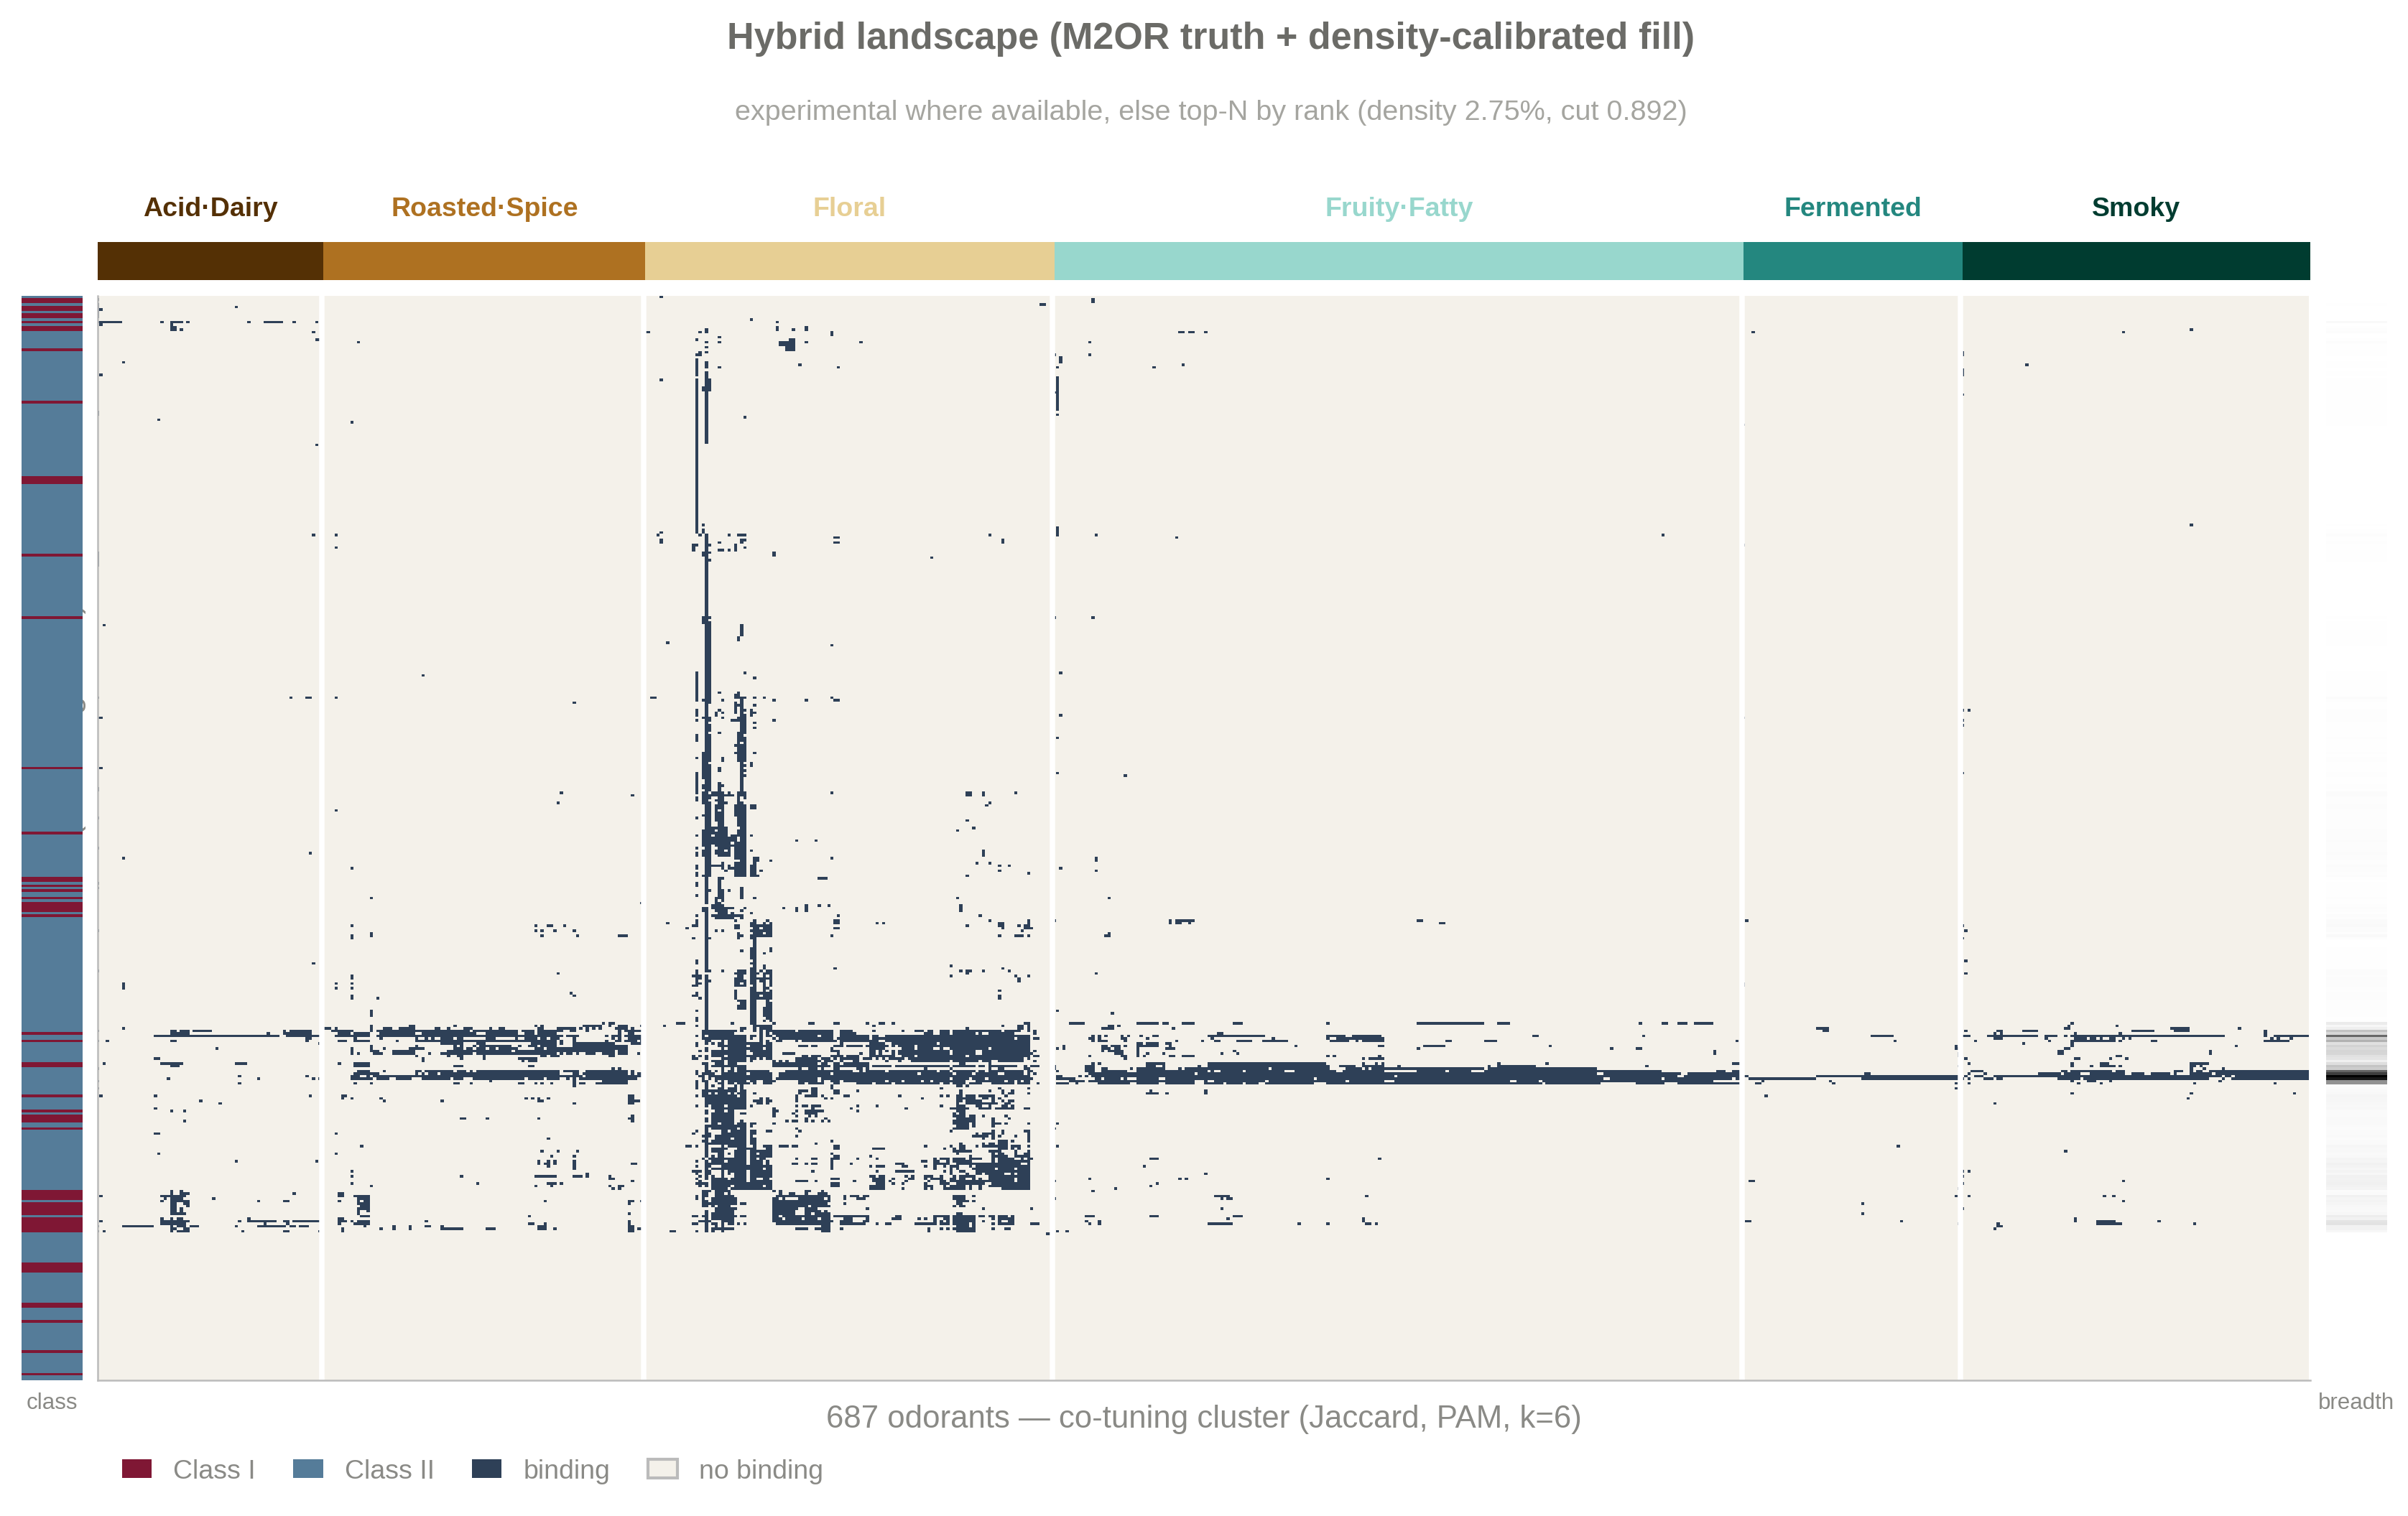

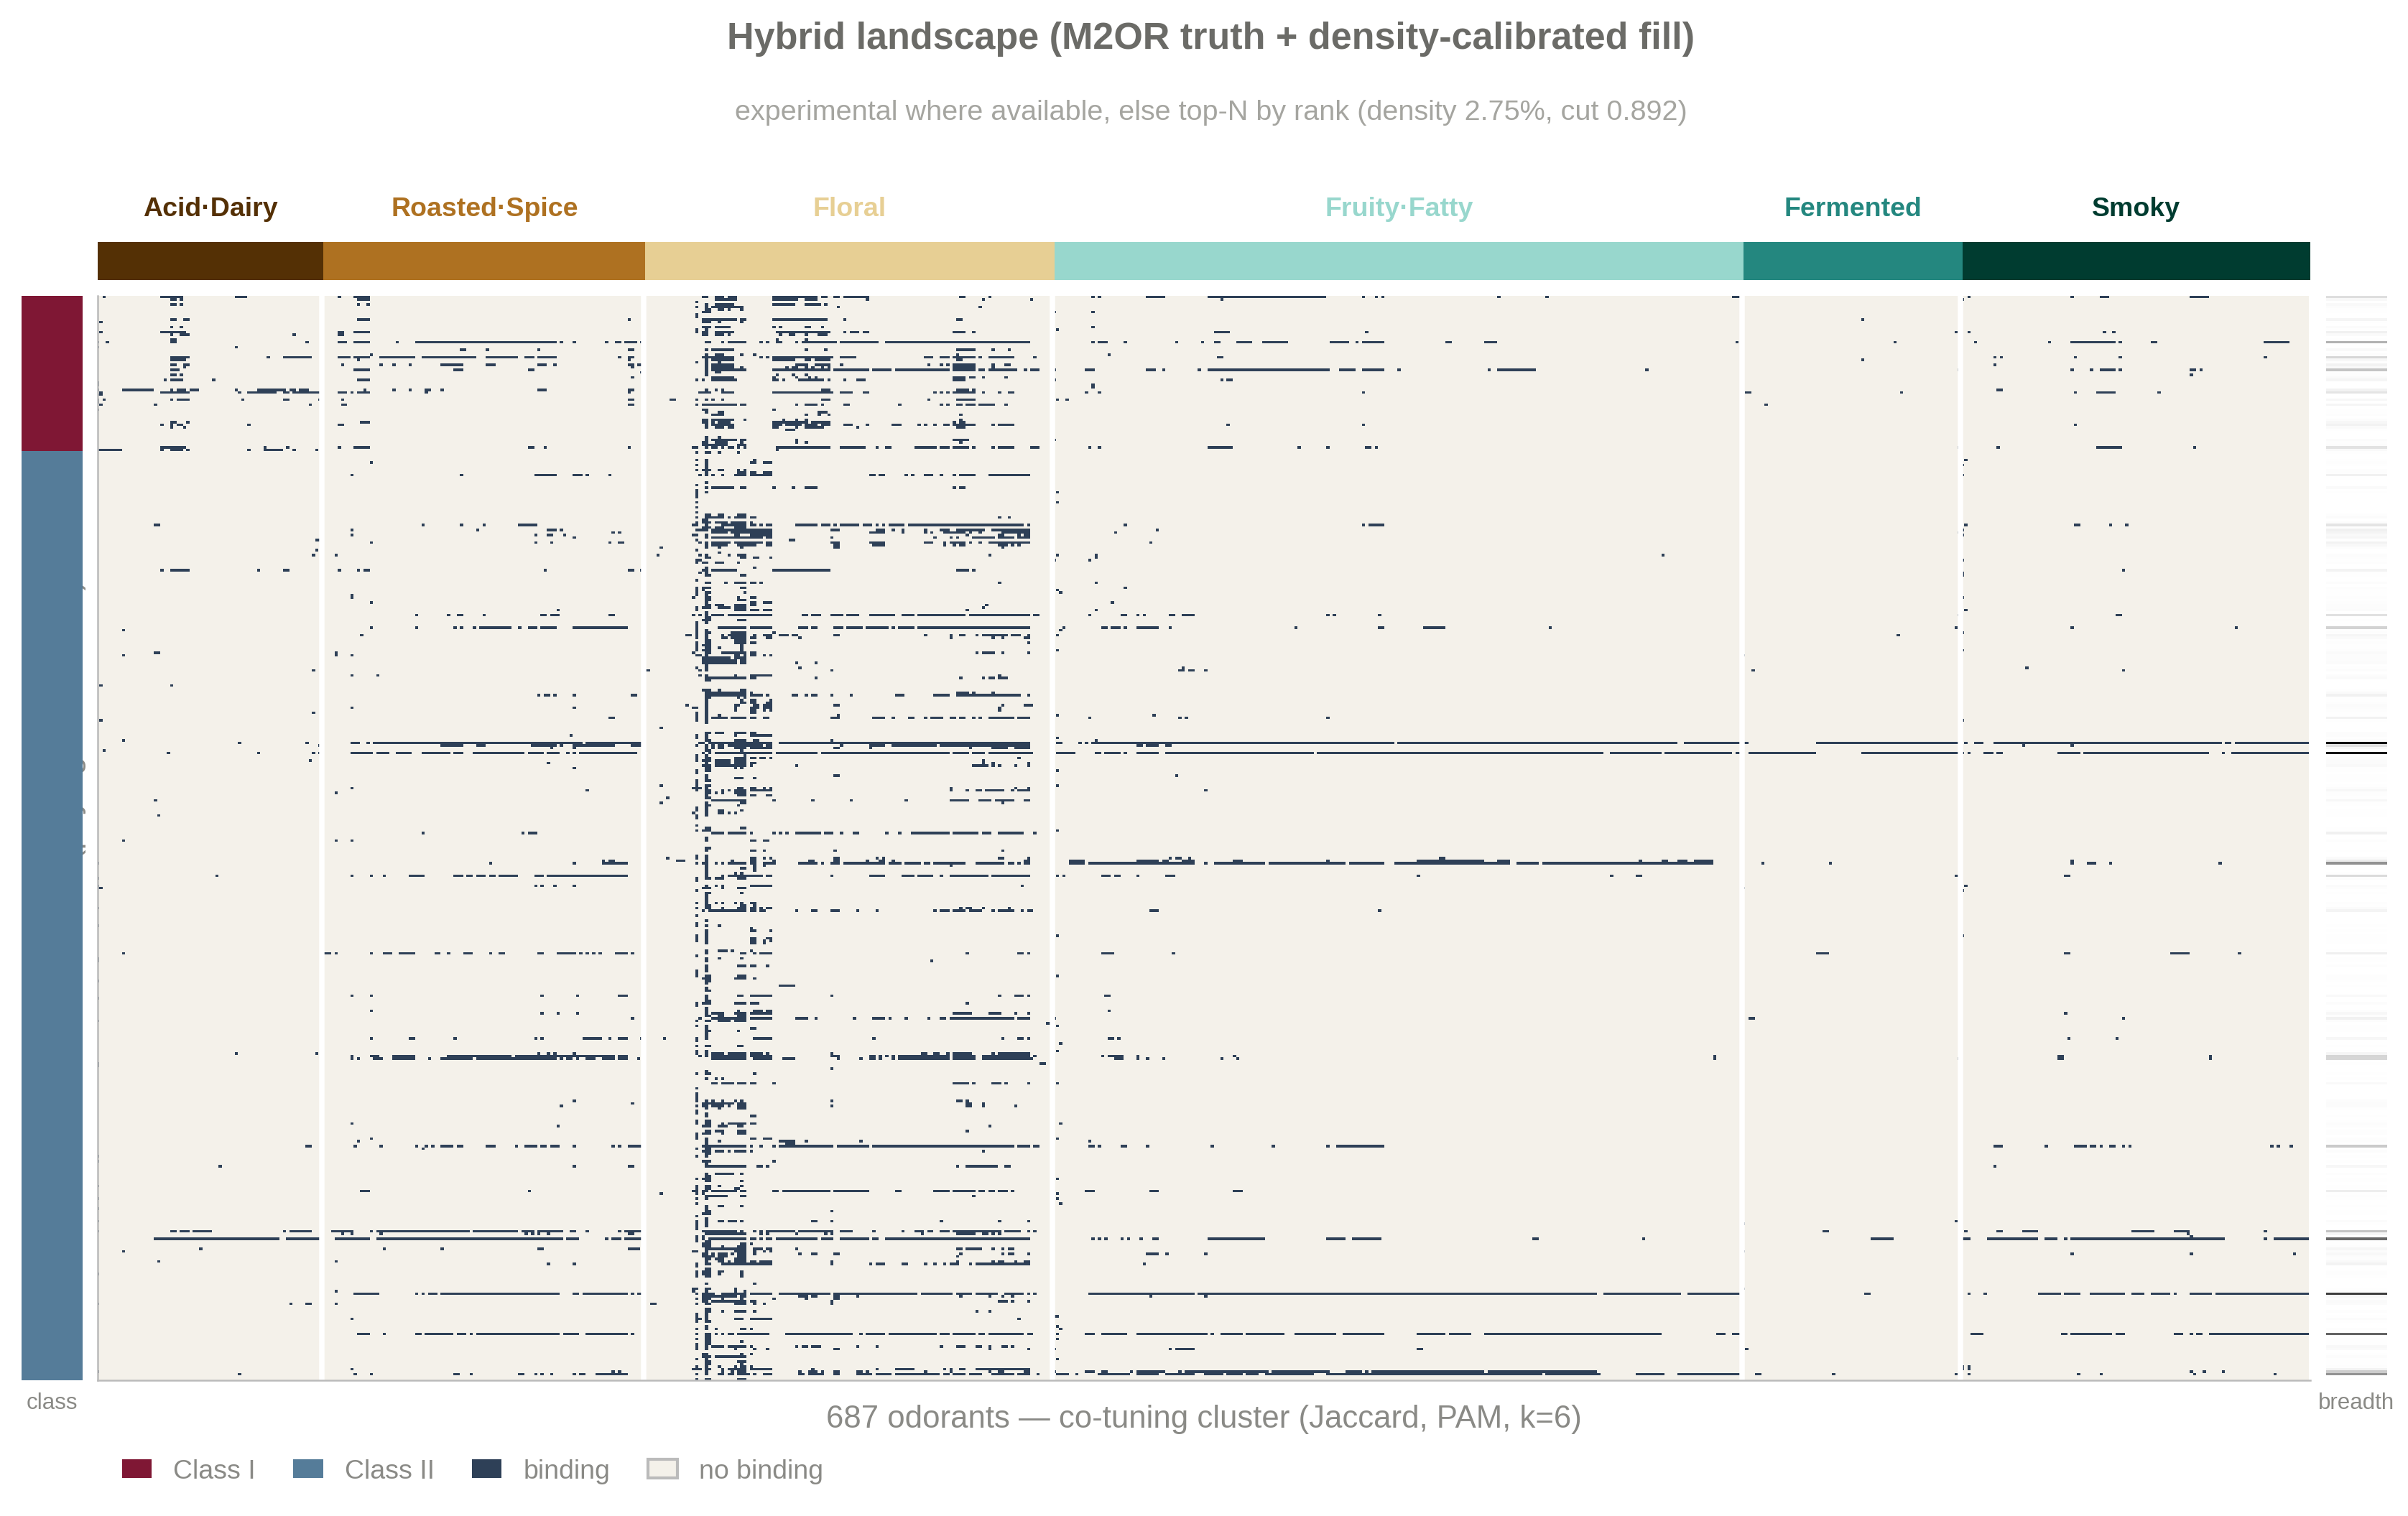

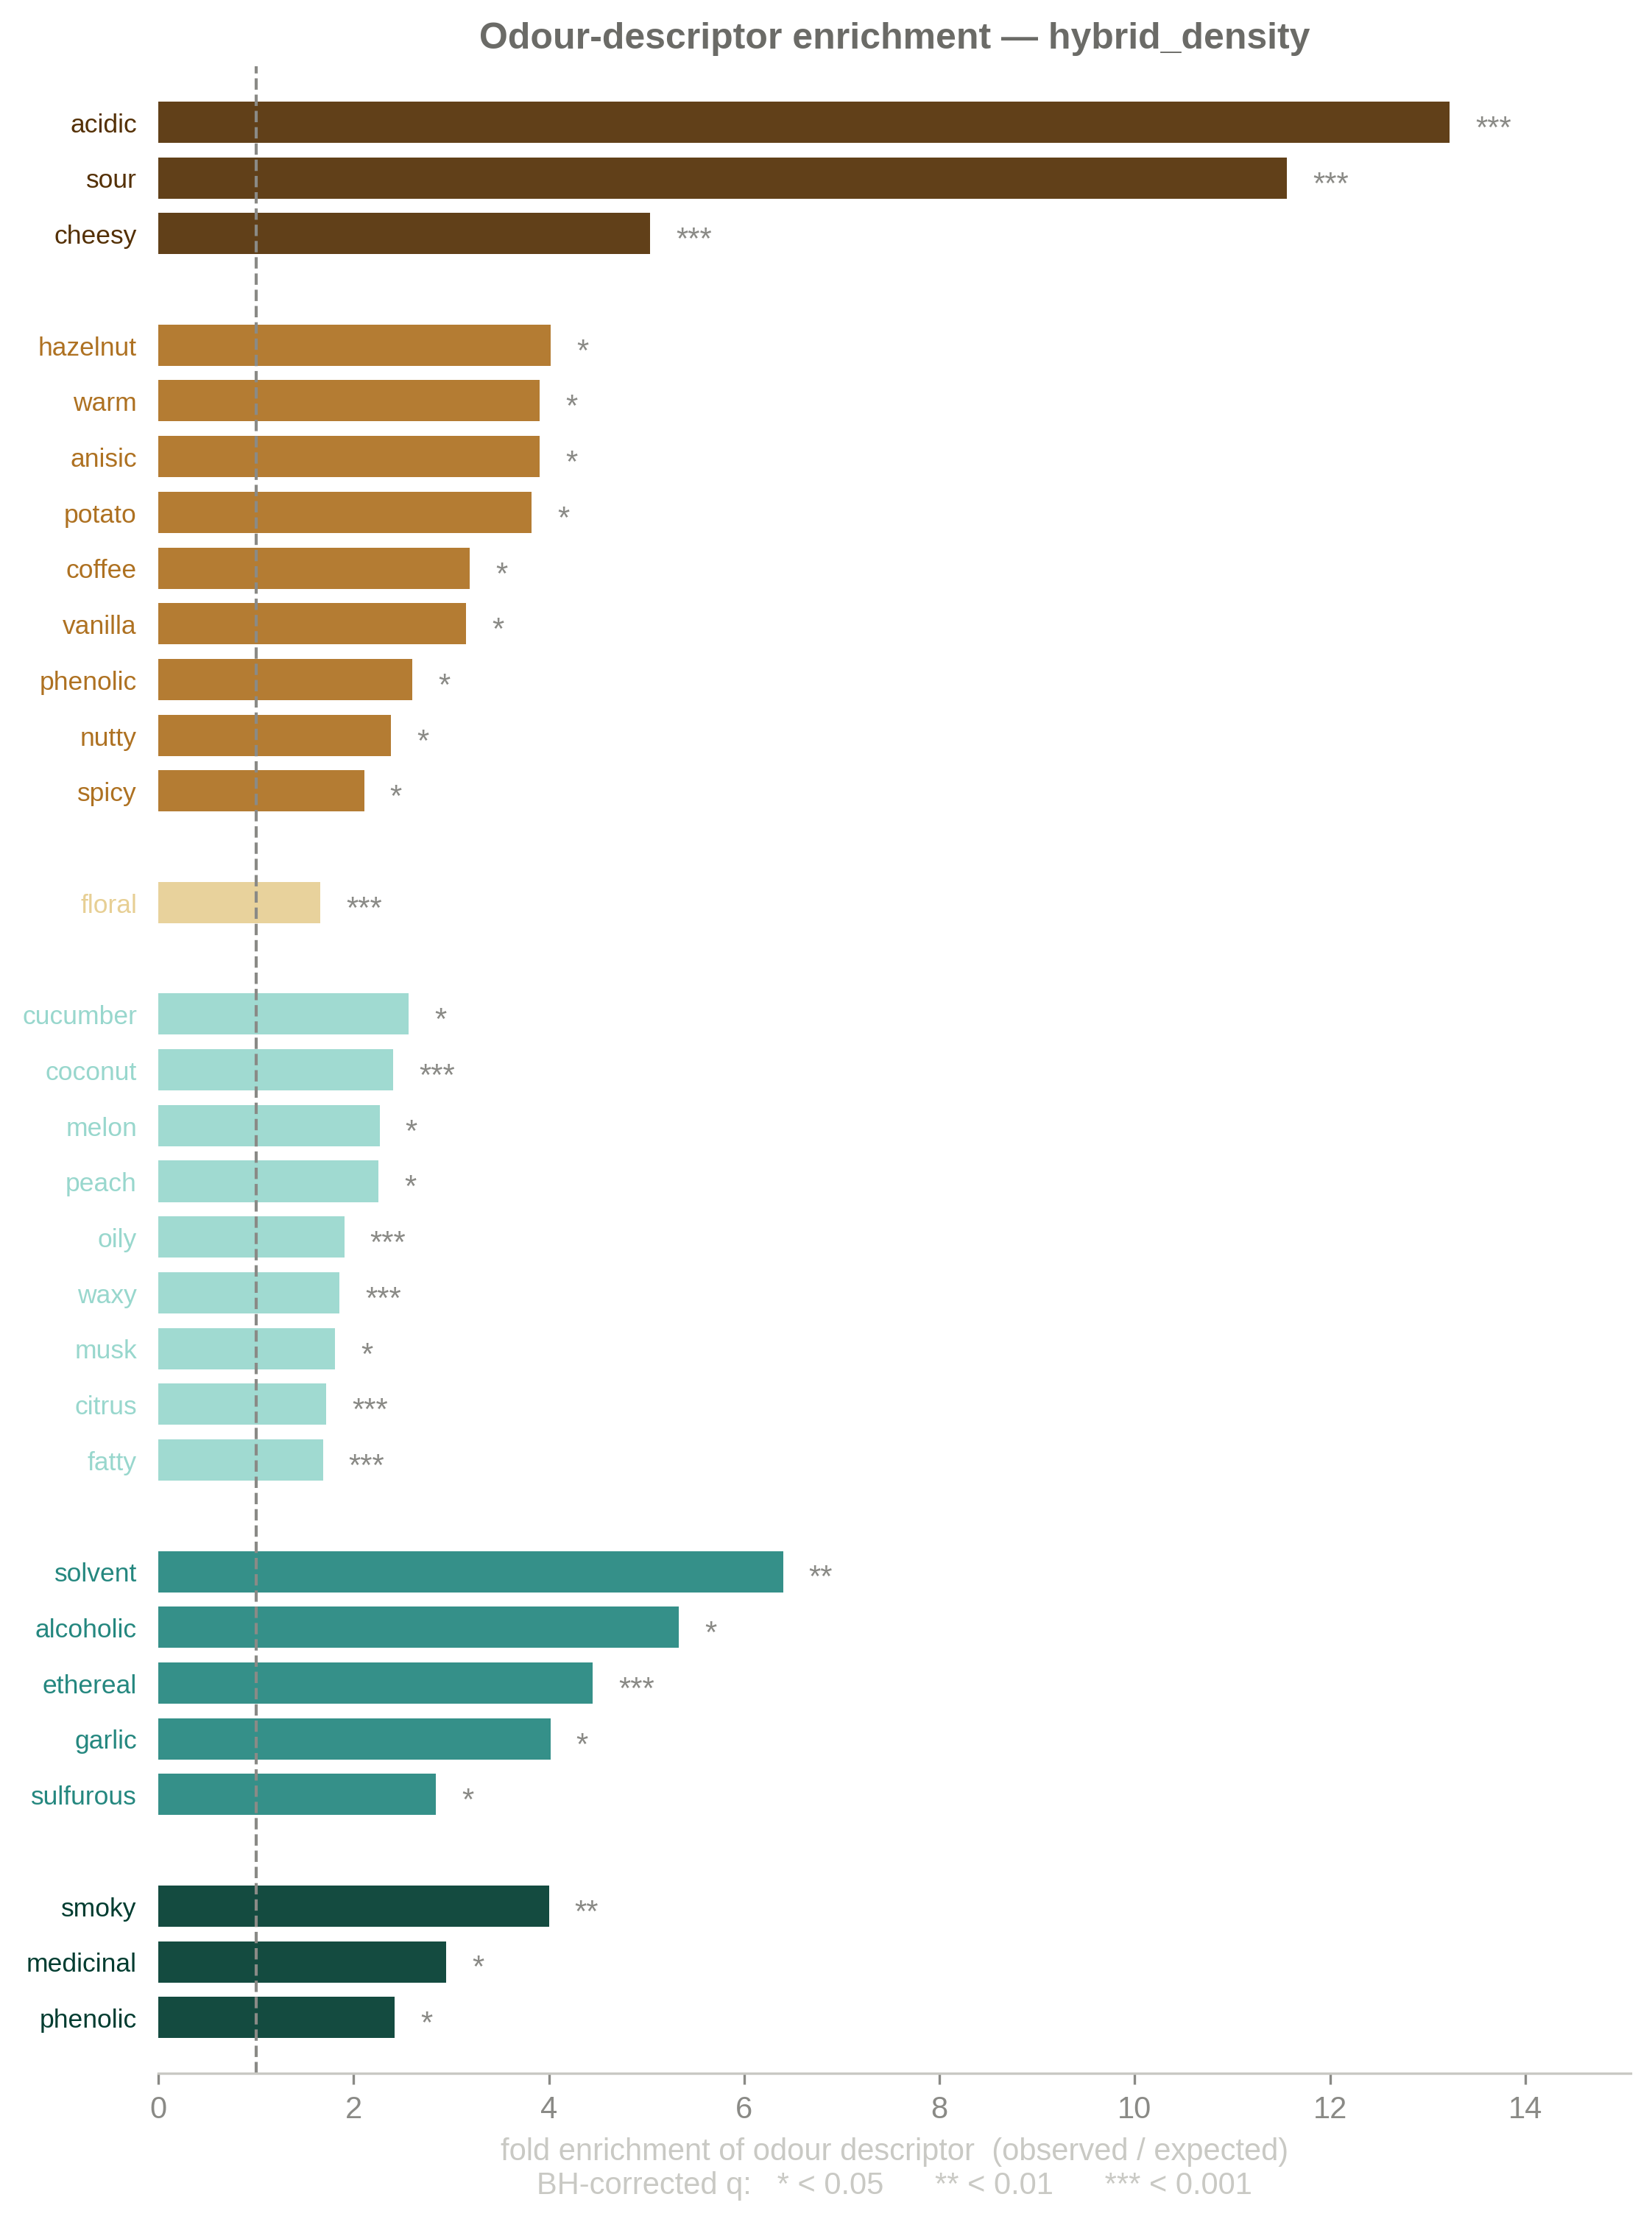

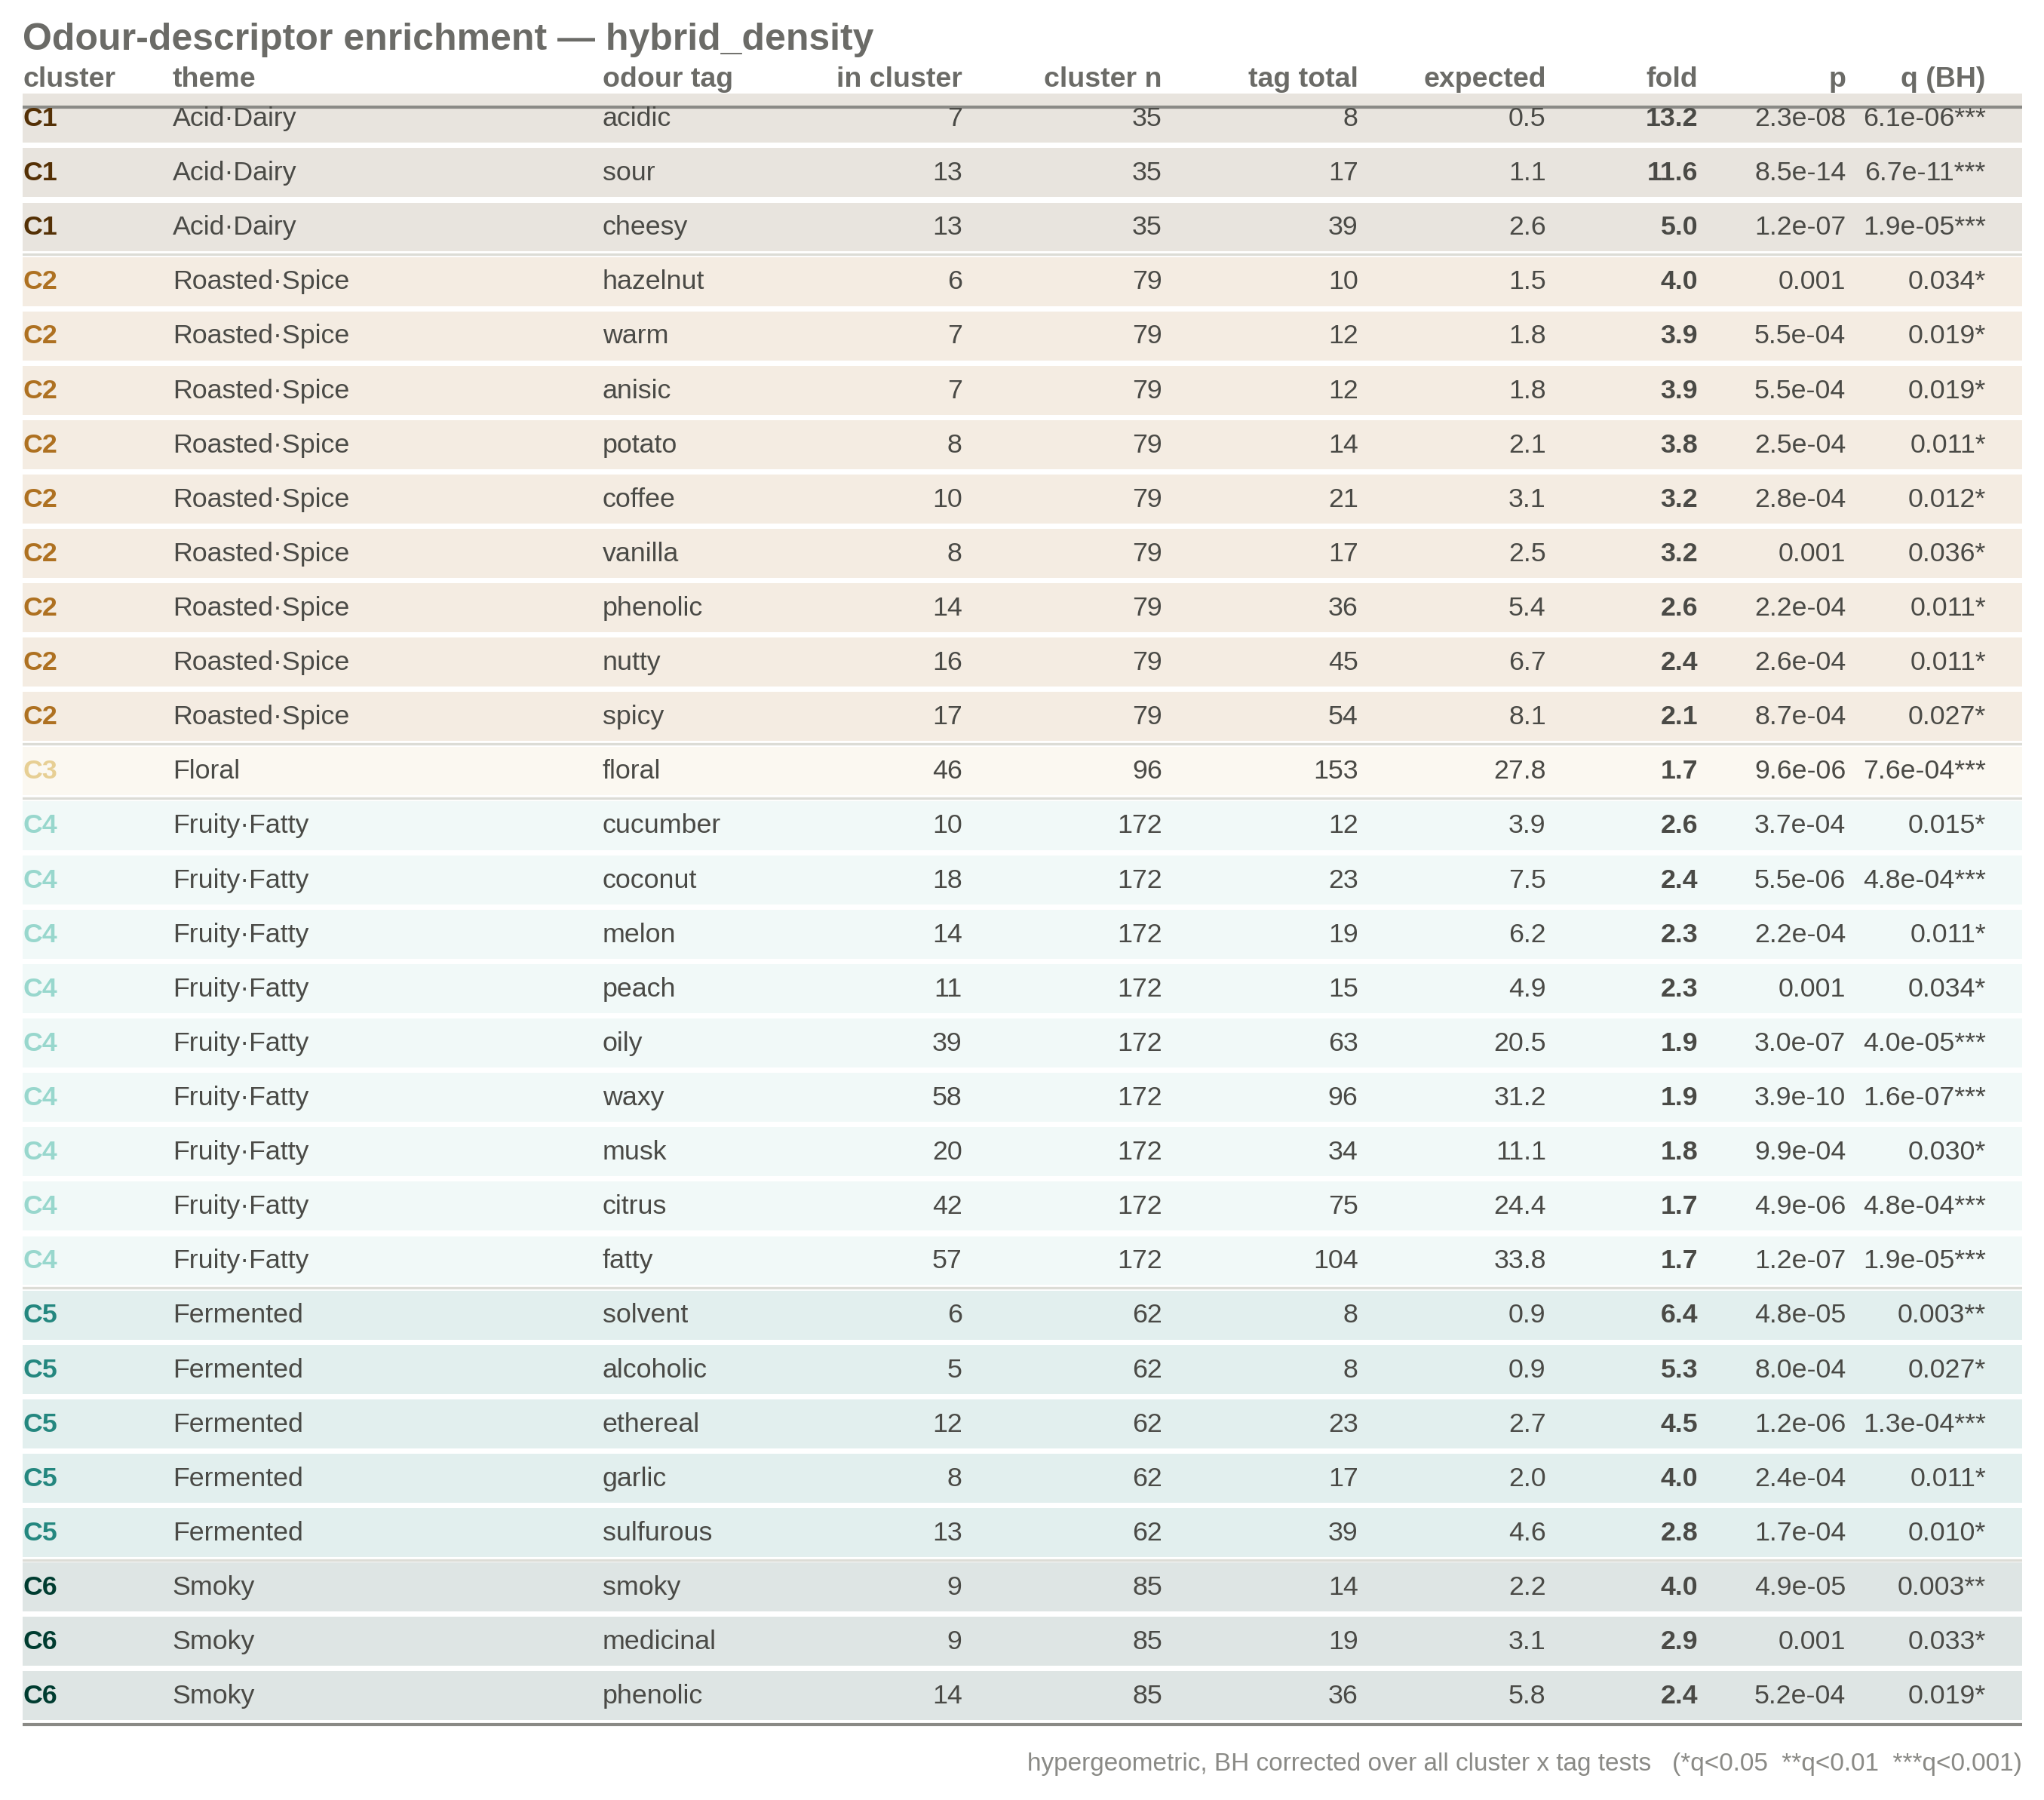

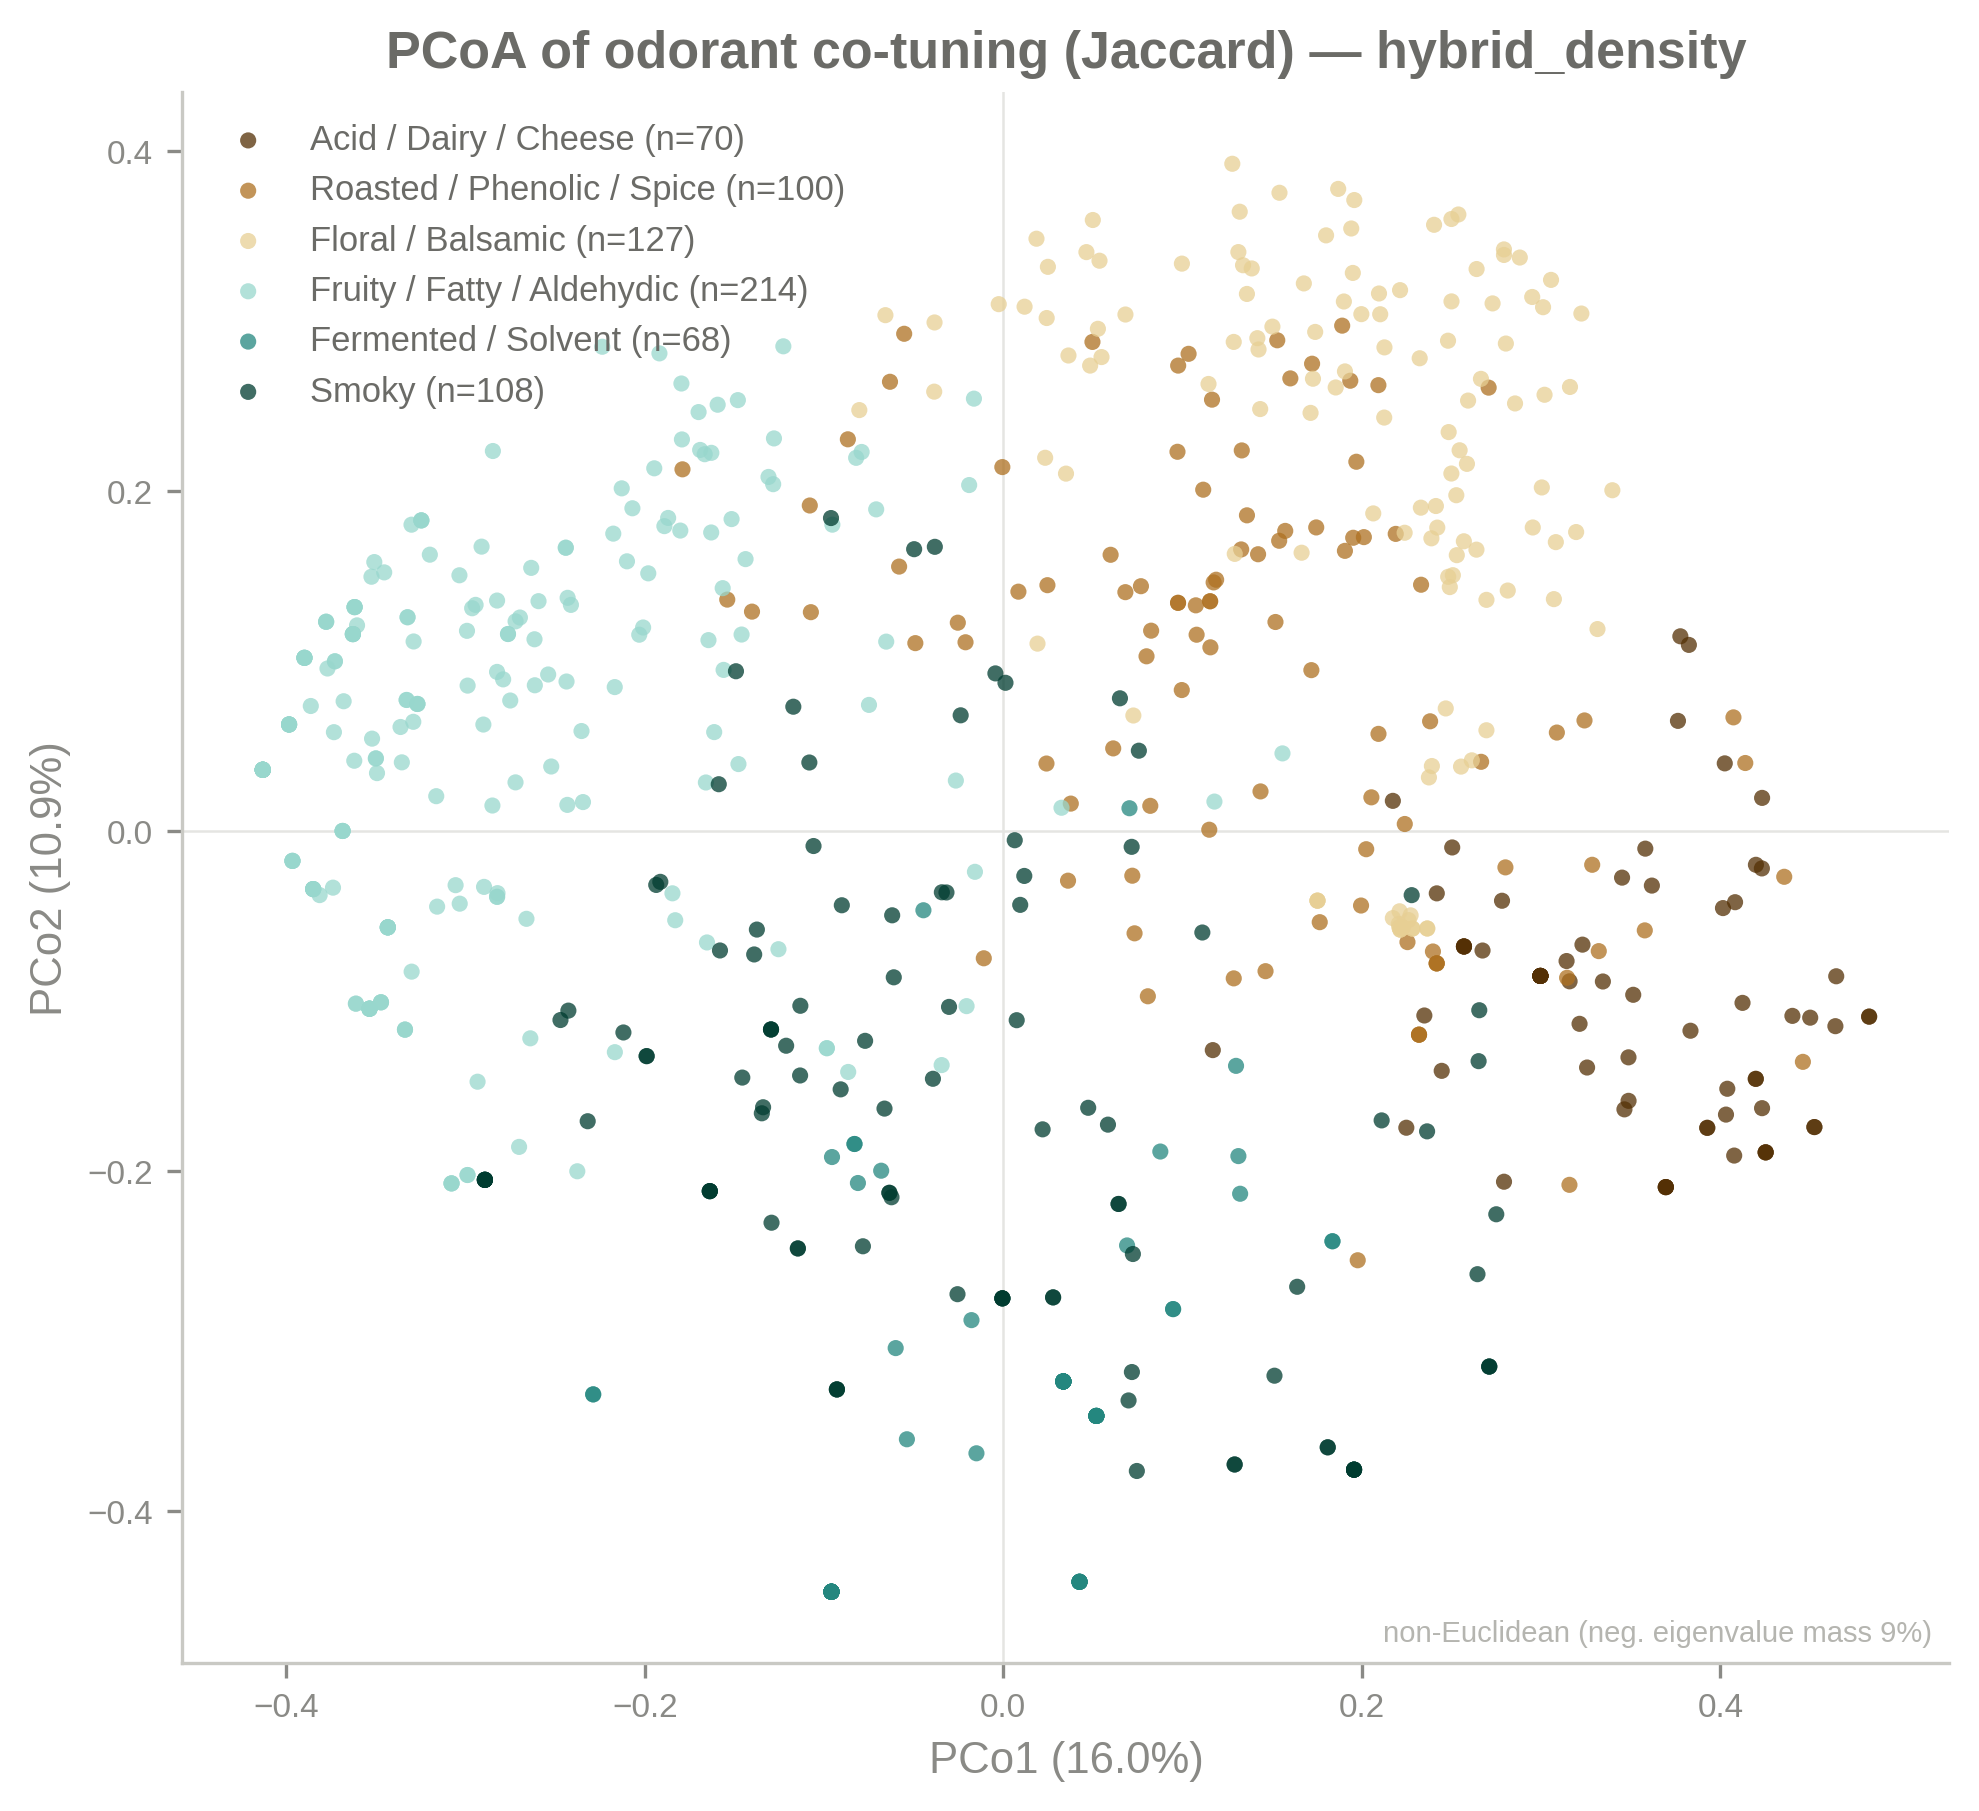

hybrid_density     sizes [214, 127, 108, 100, 70, 68]  #sig 30
baseline           sizes [159, 149, 145, 142, 89, 67]  #sig 38


{'lig': array(['SML0000', 'SML0001', 'SML0002', 'SML0003', 'SML0004', 'SML0005',
        'SML0006', 'SML0007', 'SML0008', 'SML0009', 'SML0010', 'SML0011',
        'SML0012', 'SML0013', 'SML0014', 'SML0015', 'SML0016', 'SML0017',
        'SML0018', 'SML0019', 'SML0020', 'SML0021', 'SML0022', 'SML0023',
        'SML0024', 'SML0025', 'SML0026', 'SML0027', 'SML0028', 'SML0029',
        'SML0030', 'SML0031', 'SML0032', 'SML0033', 'SML0034', 'SML0035',
        'SML0036', 'SML0037', 'SML0038', 'SML0039', 'SML0040', 'SML0041',
        'SML0042', 'SML0043', 'SML0044', 'SML0045', 'SML0046', 'SML0047',
        'SML0048', 'SML0049', 'SML0051', 'SML0052', 'SML0053', 'SML0054',
        'SML0055', 'SML0056', 'SML0057', 'SML0058', 'SML0059', 'SML0060',
        'SML0061', 'SML0062', 'SML0063', 'SML0064', 'SML0065', 'SML0066',
        'SML0067', 'SML0068', 'SML0069', 'SML0070', 'SML0071', 'SML0072',
        'SML0073', 'SML0074', 'SML0075', 'SML0076', 'SML0077', 'SML0078',
        'SML0079', 'SML0080', '

In [204]:
CL = run_matrix('hybrid_density', hybrid_density,
           'Hybrid landscape (M2OR truth + density-calibrated fill)',
           f'experimental where available, else top-N by rank (density {FILL.density:.2%}, cut {DENSITY_CUT:.3f})',
           show=True)

# --- supplementary ---
run_matrix('baseline', baseline, 'Baseline landscape (p ≥ 0.50)',
           'released prediction file', show=False)

## 9 · Chemical space of the activation clusters

Computed on the `hybrid_density` matrix only, from the partition `run_matrix` returned above.

Section 10 asks what separates the odorants the two receptor **classes** prefer. This asks the
same of the **clusters**: what is each set of co-activating molecules actually made of. Every
test here is one-vs-rest — cluster `c` against the pooled remaining molecules — BH corrected
over the whole grid of tests in each figure, so a star means the cluster stands out from the
rest of the landscape, not from one chosen neighbour.

Three figures, mirroring section 10:

| output | what it shows |
|---|---|
| `chemspace_clusters_{name}` | the descriptor panel, one violin per cluster, Kruskal-Wallis across all six |
| `chemspace_clusters_{name}_groups` | % of each cluster carrying each functional group, grouped bars, Fisher one-vs-rest |
| `chemspace_clusters_{name}_effects` | Cliff's delta per descriptor per cluster — a column reads as *this cluster is greasier / flatter / more polar than the rest* |

plus `chemspace_clusters_{name}_descriptors.csv` (per molecule) and
`chemspace_clusters_{name}_summary.csv` (per cluster: median descriptor, % carrying each group).

**Significance is stars, everywhere.** Kruskal-Wallis on the violins, Fisher on the
functional groups, Mann-Whitney on the effect matrix — each BH corrected over its own
figure, each drawn as `*` < 0.05, `**` < 0.01, `***` < 0.001. The exact q values are in
the CSVs. `ns` on a violin means the descriptor is distributed the same way in all six
clusters.

**Descriptor names.** The panel is labelled by the property first and the cheminformatics
quantity second — *greasiness (cLogP)*, *polar surface (TPSA)*, *saturation (fraction sp³)* —
so the figure reads without a glossary. `Heteroatoms` is replaced by `OxygenAtoms`: for
odorants the heteroatom that matters is almost always oxygen, and nitrogen and sulfur are
already counted as functional groups.

**`aromatic ring` is `[a]`, not `c1ccccc1`.** The SMARTS used to be benzene, which matches
a six-carbon aromatic ring and nothing else — so 50 of the 233 aromatic odorants here did
not count as aromatic: the pyrazines above all, plus furans, pyridines and thiophenes, which
between them are a large slice of roasted and green odour chemistry. Worse, it put the flag
in direct contradiction with the `AromaticRings` descriptor two rows above it in the same
figure, which has always counted every aromatic ring. `[a]` matches any aromatic atom, and
in RDKit's model an aromatic atom exists only inside an aromatic ring, so the flag now says
what its name says. Everything downstream of `_FG` — this figure, section 10's group figure
and its fold-change panel — changed with it.

This section replaces the `chemistry_clusters_*` violin figure that `run_matrix` used to
emit, which showed three of these ten descriptors and no functional groups.

In [ ]:
from scipy.stats import kruskal, fisher_exact
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

# Functional groups as SMARTS. Defined here and reused by section 10.
# 'aromatic ring' is [a], any aromatic atom — which in RDKit's model exists only inside
# an aromatic ring, so the flag is exactly "this molecule has one". It used to be
# c1ccccc1, which matches benzene and nothing else: that missed 50 of the 233 aromatic
# odorants here, all of them heteroaromatic (pyrazines above all, plus furans, pyridines,
# thiophenes), and made the flag disagree with the AromaticRings descriptor counted two
# rows above it.
_FG={'carboxylic acid':'[CX3](=O)[OX2H1]','ester':'[CX3](=O)[OX2H0][#6]','aldehyde':'[CX3H1](=O)[#6]',
     'ketone':'[#6][CX3](=O)[#6]','alcohol':'[#6;!$([CX3]=O)][OX2H1]','ether':'[OD2]([#6])[#6]',
     'aromatic ring':'[a]','amine':'[NX3;!$([NX3][CX3]=[OX1])]','sulfur':'[#16]'}
_FGP={k:Chem.MolFromSmarts(v) for k,v in _FG.items()}

# The descriptor panel, in plain terms: size, greasiness, polarity, flexibility, shape.
# Each label names the property first and the cheminformatics quantity second, so the
# figure reads without a glossary.
PROPS=[('MolWt','size (MW, Da)'),
       ('LogP','greasiness (cLogP)'),
       ('TPSA','polar surface (TPSA, Å$^2$)'),
       ('HBD','H-bond donors (-OH, -NH)'),
       ('HBA','H-bond acceptors'),
       ('OxygenAtoms','oxygen atoms'),
       ('RotBonds','flexibility (rotatable bonds)'),
       ('FracCSP3','saturation (fraction sp$^3$)'),
       ('AromaticRings','aromatic rings'),
       ('RingCount','rings')]

# Diverging ramp built from the notebook palette, so the effect matrix sits next to the
# heatmaps and enrichment bars without introducing new hues.
CMAP_DIV=LinearSegmentedColormap.from_list('div',['#24877f','#f2f0ea','#8c4a1e'])


def odorant_descriptors(sids,labels=None):
    """One row per parseable molecule: the descriptor panel plus functional-group flags."""
    recs=[]
    for i,sid in enumerate(sids):
        sm=sml2smiles.get(sid); mol=Chem.MolFromSmiles(sm) if isinstance(sm,str) else None
        if mol is None: continue
        d=dict(sml=sid,SMILES=sm)
        if labels is not None: d['cluster']=int(labels[i])
        d.update(MolWt=Descriptors.MolWt(mol),LogP=Crippen.MolLogP(mol),
                 TPSA=rdMolDescriptors.CalcTPSA(mol),
                 HBD=Lipinski.NumHDonors(mol),HBA=Lipinski.NumHAcceptors(mol),
                 OxygenAtoms=sum(a.GetAtomicNum()==8 for a in mol.GetAtoms()),
                 RotBonds=Descriptors.NumRotatableBonds(mol),
                 FracCSP3=rdMolDescriptors.CalcFractionCSP3(mol),
                 AromaticRings=rdMolDescriptors.CalcNumAromaticRings(mol),
                 RingCount=rdMolDescriptors.CalcNumRings(mol))
        for g,patt in _FGP.items(): d[g]=int(mol.HasSubstructMatch(patt))
        recs.append(d)
    return pd.DataFrame(recs)


def cluster_chemistry(CL,name):
    """Physicochemical panel and functional groups of every activation cluster.

    Section 10 asks the same question of the two receptor classes. Here the grouping is
    the PAM partition, so every test is one-vs-rest: cluster c against the pooled
    remaining molecules, BH corrected over the whole grid of tests in each figure.
    """
    lig,lab,meta,cl_order=CL['lig'],CL['lab'],CL['meta'],CL['cl_order']
    df=odorant_descriptors(lig,lab)
    df['cluster_name']=[meta[c]['name'] for c in df.cluster]
    df.to_csv(f'{OUTDIR}/chemspace_clusters_{name}_descriptors.csv',index=False)

    keys=[k for k,_ in PROPS]; labs=[l for _,l in PROPS]; fgs=list(_FG)
    cols=[meta[c]['color'] for c in cl_order]
    tags=['C%d'%(i+1) for i in range(len(cl_order))]
    names=[SHORT.get(meta[c]['name'],meta[c]['name']) for c in cl_order]
    print('cluster chemistry %-15s %d molecules  sizes %s'
          %(name,len(df),[int((df.cluster==c).sum()) for c in cl_order]))

    # ---- (a) descriptor distributions, one violin per cluster -----------------
    # Kruskal-Wallis across all K clusters: is this descriptor distributed differently
    # anywhere in the partition? BH over the panel, reported as stars.
    data={k:[df.loc[df.cluster==c,k].values for c in cl_order] for k in keys}
    q=bh(np.array([kruskal(*data[k])[1] for k in keys]))
    ncol=5; nrow=int(np.ceil(len(keys)/ncol))
    fig,axes=plt.subplots(nrow,ncol,figsize=(2.9*ncol,2.9*nrow)); axes=np.atleast_1d(axes).ravel()
    for ax,k,lb,qq in zip(axes,keys,labs,q):
        vp=ax.violinplot(data[k],positions=range(len(cl_order)),widths=0.9,
                         showmedians=False,showextrema=False)
        for pc,col in zip(vp['bodies'],cols):
            pc.set_facecolor(col); pc.set_alpha(0.85); pc.set_edgecolor('none')
        for j,vv in enumerate(data[k]):
            a1,md,a3=np.percentile(vv,[25,50,75])
            ax.vlines(j,a1,a3,color='#4a4a46',lw=1.5,zorder=4)
            ax.plot(j,md,'o',mfc='white',mec='#4a4a46',mew=1.0,ms=3.6,zorder=5)
        ax.set_title('%s   %s'%(lb,_stars(qq) or 'ns'),fontsize=9.5,color='#6b6b67',pad=6)
        ax.set_xticks(range(len(cl_order))); ax.set_xticklabels(tags,fontsize=8.5)
        for tl,col in zip(ax.get_xticklabels(),cols): tl.set_color(col)
        ax.yaxis.set_major_locator(MaxNLocator(4)); ax.tick_params(axis='y',labelsize=8)
        ax.tick_params(axis='x',length=0)
        for sp in ['top','right']: ax.spines[sp].set_visible(False)
    for ax in axes[len(keys):]: ax.axis('off')
    fig.legend(handles=[Patch(facecolor=c,label='%s  %s'%(t,n)) for c,t,n in zip(cols,tags,names)],
               loc='upper center',bbox_to_anchor=(0.5,0.945),ncol=len(cl_order),frameon=False,
               fontsize=9,handlelength=1.1,handleheight=1.1,columnspacing=1.8)
    fig.suptitle('Chemical space of the activation clusters — %s'%name,
                 fontsize=12,fontweight='bold',color='#6b6b67',y=0.995)
    fig.text(0.5,0.012,'violin = distribution, bar = IQR, dot = median   ·   '
             'Kruskal-Wallis across the %d clusters, BH:  * < 0.05   ** < 0.01   *** < 0.001'
             %len(cl_order),ha='center',fontsize=8.5,color='#8a8a86')
    fig.tight_layout(rect=[0,0.028,1,0.915]); save(fig,f'chemspace_clusters_{name}')

    # ---- (b) functional groups, % of cluster carrying each -------------------
    Fpct=np.zeros((len(fgs),len(cl_order))); Fp=np.ones_like(Fpct)
    for i,g in enumerate(fgs):
        for j,c in enumerate(cl_order):
            inn=df.cluster==c; a=int(df.loc[inn,g].sum()); b=int(inn.sum())-a
            cc=int(df.loc[~inn,g].sum()); dd=int((~inn).sum())-cc
            Fpct[i,j]=100*a/max(int(inn.sum()),1)
            Fp[i,j]=fisher_exact([[a,b],[cc,dd]])[1]
    Fq=bh(Fp.ravel()).reshape(Fp.shape)
    o=np.argsort(Fpct.mean(1))                       # rarest at the bottom, as in section 10
    fgs_o=[fgs[i] for i in o]; Fpct=Fpct[o]; Fq=Fq[o]

    yy=np.arange(len(fgs_o)); hh=0.84/len(cl_order); xm=Fpct.max()
    fig,ax=plt.subplots(figsize=(9.2,0.92*len(fgs_o)+1.7))
    for j,c in enumerate(cl_order):
        off=((len(cl_order)-1)/2-j)*hh               # C1 at the top of each group
        ax.barh(yy+off,Fpct[:,j],height=hh*0.9,color=cols[j],alpha=0.92,
                label='%s  %s'%(tags[j],names[j]))
        for i in range(len(fgs_o)):
            s=_stars(Fq[i,j])
            if s: ax.text(Fpct[i,j]+xm*0.012,yy[i]+off-0.06,s,va='center',ha='left',
                          fontsize=7.5,color='#8a8a86')
    for i in yy[:-1]:
        ax.axhline(i+0.5,color='#ecebe6',lw=0.8,zorder=0)
    ax.set_yticks(yy); ax.set_yticklabels(fgs_o,fontsize=9.5)
    ax.set_ylim(-0.5,len(fgs_o)-0.5); ax.set_xlim(0,xm*1.10)
    ax.set_xlabel('% of cluster carrying the group\n'
                  'Fisher one-vs-rest, BH:   * < 0.05      ** < 0.01      *** < 0.001',fontsize=10)
    ax.set_title('Functional groups by activation cluster — %s'%name,
                 fontsize=12,fontweight='bold',color='#6b6b67')
    ax.legend(frameon=False,fontsize=8.5,loc='lower right',ncol=2,handlelength=1.2)
    for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
    ax.tick_params(left=False)
    save(fig,f'chemspace_clusters_{name}_groups')

    # ---- (c) what each cluster is made of, as effect size -------------------
    # Cliff's delta of cluster c against every other molecule, so a column reads as
    # "this cluster is greasier / heavier / flatter than the rest".
    Dm=np.zeros((len(keys),len(cl_order))); Pm=np.ones_like(Dm)
    for i,k in enumerate(keys):
        for j,c in enumerate(cl_order):
            a=df.loc[df.cluster==c,k].values; b=df.loc[df.cluster!=c,k].values
            Dm[i,j]=_cliffs(a,b)
            try: Pm[i,j]=mannwhitneyu(a,b).pvalue
            except Exception: Pm[i,j]=np.nan
    Qm=bh(np.nan_to_num(Pm.ravel(),nan=1.0)).reshape(Pm.shape)
    v=np.abs(Dm).max()
    fig,ax=plt.subplots(figsize=(1.15*len(cl_order)+4.4,0.55*len(keys)+2.0))
    im=ax.imshow(Dm,cmap=CMAP_DIV,aspect='auto',vmin=-v,vmax=v)
    for i in range(len(keys)):
        for j in range(len(cl_order)):
            ax.text(j,i,'%+.2f%s'%(Dm[i,j],_stars(Qm[i,j])),ha='center',va='center',fontsize=8,
                    color='white' if abs(Dm[i,j])>0.62*v else '#4a4a46')
    ax.set_xticks(range(len(cl_order)))
    ax.set_xticklabels(['%s\n%s'%(t,n) for t,n in zip(tags,names)],fontsize=8.5)
    for tl,col in zip(ax.get_xticklabels(),cols): tl.set_color(col)
    ax.set_yticks(range(len(keys))); ax.set_yticklabels(labs,fontsize=9)
    ax.set_xticks(np.arange(-.5,len(cl_order),1),minor=True)
    ax.set_yticks(np.arange(-.5,len(keys),1),minor=True)
    ax.grid(which='minor',color='white',lw=1.6); ax.tick_params(which='minor',length=0)
    for sp in ax.spines.values(): sp.set_visible(False)
    cb=fig.colorbar(im,ax=ax,fraction=0.03,pad=0.02)
    cb.set_label("Cliff's delta, cluster vs all other molecules",fontsize=9); cb.outline.set_visible(False)
    ax.set_title('What each activation cluster is made of — %s\n'
                 'Mann-Whitney one-vs-rest, BH:  * < 0.05   ** < 0.01   *** < 0.001'%name,
                 fontsize=11,fontweight='bold',color='#6b6b67')
    fig.tight_layout(); save(fig,f'chemspace_clusters_{name}_effects')

    # ---- summary table -------------------------------------------------------
    rows=[]
    for j,c in enumerate(cl_order):
        s=df[df.cluster==c]
        r=dict(cluster=tags[j],theme=meta[c]['name'],n=len(s))
        r.update({k:round(float(np.median(s[k])),3) for k in keys})
        r.update({g:round(100*float(s[g].mean()),1) for g in fgs})
        rows.append(r)
    out=pd.DataFrame(rows); out.to_csv(f'{OUTDIR}/chemspace_clusters_{name}_summary.csv',index=False)
    return df,out


SHOW=True
clu_desc,clu_summary=cluster_chemistry(CL,'hybrid_density')
SHOW=False
clu_summary

## 10 · Chemical space of Class I- vs Class II-preferring odorants

Computed on the `hybrid_density` matrix only.

A molecule enters a class's bag when it activates at least `r = 1/62` of that class —
one Class I receptor, or six Class II receptors. Equal rates rather than equal counts,
so the 62/371 class-size difference does not decide membership. That yields three sets:
the two exclusive ones (111 and 112 molecules) and the shared set (276), the generalist
core both classes read.

**How many receptors sit behind each set.** Membership is a rate test on molecules; this is
the coverage behind it — a receptor counts here if it binds at least one molecule of the set.

| molecule set | Class I receptors | Class II receptors |
|---|---|---|
| shared, 276 | 53 / 62 (85%) | 317 / 371 (85%) |
| Class I only, 111 | 30 / 62 (48%) | 41 / 371 (11%), all below *r* |
| Class II only, 112 | **0 / 62** | 124 / 371 (33%) |

Two things follow. First, the shared core is not a fringe of either class: 85% of the
receptors on both sides read it, so the overlap between the bags is structural rather than
an artefact of where *r* was put. Second, the two exclusive sets are not symmetric. The
Class II-only molecules are bound by **no Class I receptor at all** — they are genuinely
outside Class I's range. The Class I-only molecules are still touched by 41 Class II
receptors, just by too few of them (fewer than 6 of 371) to clear the rate. So "Class I
only" means Class I-preferring, while "Class II only" means Class I-invisible.

Within the shared set the two classes also read at different depths: a shared molecule is
bound by a median of 3 Class I receptors (max 37) against 10.5 Class II receptors (max 263),
which is mostly the 62/371 class-size difference and the broader tuning of Class I reported
in section 11.

**Two different comparisons live in this section, and they are not interchangeable.**

| figure | what is compared |
|---|---|
| `chemspace_{name}` (violins), `chemspace_{name}_groups` | the three sets side by side; the test is the two **exclusive** sets against each other |
| `chemspace_{name}_effects` | the two **full bags** — every molecule Class I binds (387) against every molecule Class II binds (388), with the 276 shared molecules counted in both |
| `chemspace_{name}_effects_exclusive` | the same figure on the two **exclusive sets** — 111 against 112, nothing in both |
| `chemspace_{name}_effects_cliffs` | the exclusive sets again, as **Cliff's delta** per descriptor, sorted by effect |

The two `_effects` figures are one function called twice, so every choice below applies to
both and they can be read against each other row for row. They answer different questions:
the full bags say what each class reads, the exclusive sets say what each class reads *that
the other does not*. The exclusive contrast is much the sharper of the two — a Class I-only
molecule has **12.9×** the water affinity of a Class II-only one, against 1.9× between the
bags — and the full-bag one is the honest description of the repertoire. Neither replaces
the other.

### How `_effects` measures a property

Not as a rank statistic. Every row is a **fold change**, Class I bag ÷ Class II bag, on a
log₂ axis, so the number reads in the units a chemist already has: *1.7× the H-bond
donors*, *half the partition coefficient*, *5.7× as likely to be a carboxylic acid*. The
two group values are printed beside the bars in their own units, so nothing has to be
back-calculated off the axis.

Which summary the ratio is taken of depends on the quantity, because one rule does not fit
all of them:

| how | applied to | why |
|---|---|---|
| ratio of **medians** | MW, TPSA, boiling point | strictly positive, skewed; the median is the honest centre |
| ratio of **means** | counts, fractions, and the % carrying each functional group | the median of *aromatic rings* or *carboxylic acid* is 0 in both bags, so a ratio of medians is 1 or undefined. For a 0/1 flag the mean **is** the prevalence, so the functional-group rows are prevalence ratios |
| 10^(median difference) | water affinity, vapour pressure | these are already logarithms. Ratios of logarithms mean nothing; the ratio belongs to the quantity they are logs of — the vapour pressure in atm, and 1/*P*, the water/octanol partition coefficient |

**Water affinity is 1/*P*, not *P*.** cLogP runs the wrong way for this figure: it rises
with greasiness, so plotting the octanol/water partition coefficient *P* put the one row
that most directly means *water-soluble* pointing in the opposite direction to TPSA, H-bond
donors and oxygen atoms, which sit right beside it in the same block and mean the same
thing. The row is therefore 10^(−cLogP) = 1/*P*, the water/octanol partition coefficient:
higher is more at home in water, like every other row of the block. Class I's bag comes out
at **1.9× the water affinity** of Class II's — the same fact as "half the *P*", read from
the side the block is about.

**`aromatic rings per molecule` and `aromatic ring` are not the same row twice.** The first
is a count — `CalcNumAromaticRings`, averaged over the bag, so a naphthalene contributes 2.
The second is a prevalence — the % of the bag carrying at least one. A count can move while
a prevalence does not, when the difference sits in molecules that carry several rings. Both
now use the same definition of *aromatic* (see section 9: the flag used to be benzene-only,
which is what made them disagree), and both now point the same way: Class II binds 1.18×
the aromatic rings per molecule and is 1.13× as likely to bind an aromatic molecule at all.

**Volatility** enters through the Joback boiling point and the vapour pressure derived from
it by Clausius-Clapeyron with Trouton's rule, imported from `Chemicals/chemspace.py`
so the repository has one definition of it. Both are group-contribution estimates rather
than measurements, and they drift for large decorated molecules; odorants sit in the
small-molecule range where the method holds.

**Significance.** The two bags overlap by 276 molecules, so a Mann-Whitney between them is
not valid — a shared molecule would be counted as evidence on both sides, and the test
would read `n = 387 + 388` when only 223 molecules distinguish the bags at all. Under *the
two classes prefer the same chemistry* the shared molecules are fixed: they enter both bags
whatever the labels are. The null is therefore built by reassigning the exclusive labels
among the exclusive molecules and holding the shared block in both bags — 5000 draws, each
recomputing the same all-vs-all fold change the bars show, on sets of exactly the observed
size and overlap. BH over the panel. The CI is a bootstrap in three blocks (Class I only,
Class II only, shared) with one shared draw entering both bags, for the same reason;
resampling the two bags independently would treat the shared molecules as two independent
samples and inflate every interval.

**A ratio with nothing in the denominator.** In the exclusive panel no Class II-only
molecule carries a carboxylic acid at all — 52 of 111 against 0 of 112 — so the fold change
is infinite. It is drawn as a bar running off the axis with an arrowhead and `∞`, not
dropped and not fudged with a continuity correction that would put it at 106× and flatten
every other row into the centre. The permutation handles it without special-casing: a
permuted split only matches an infinite statistic by being infinite itself, which needs all
52 acids on one side, so *p* lands on the floor of 1/(5000+1). The two group values, 47%
and 0%, are printed beside it as always. A property with no value in *either* set is the
one case that is dropped, with a printed note.

Each figure writes a CSV beside it with the fold change, the CI, the two group values, the
permutation *p* and *q*, and Cliff's delta — the bars answer *how much more*, the delta
answers *how consistently*, and the two disagree whenever a difference sits in a tail.

### What it says

**Class I binds the water-soluble end, Class II the greasy end.** Class I molecules have
1.9× the water affinity (1/*P*; cLogP 2.38 vs 2.67), 1.3× the polar surface, 1.7× the
H-bond donors and 1.2× the oxygen atoms, and are **5.7× as likely to carry a carboxylic
acid** (16% vs 3%) — the single largest effect in the panel, and the one that carries the
polarity axis. Class II leans the other way on ring chemistry: 1.2× the aromatic rings per
molecule, 1.13× the prevalence of aromatic molecules (36% vs 41%), 1.1× the rings overall
and 1.25× the ketones. Sulfur runs the other way, 1.4× in the Class I bag off a small base
(7% vs 5%).

**Volatility does not separate them.** Molecular weight, boiling point and vapour pressure
are flat (0.99×, 1.00×, 1.03×, all ns): the two classes read molecules of the same size and
the same volatility, and differ in how polar those molecules are. The Class I / Class II
split is a **polarity** axis, not a volatility axis.

**The full-bag comparison is the attenuated one.** Because 71% of each bag is shared, every
fold change there is smaller than the same row in the exclusive panel — the shared core is
chemistry both classes read, and it pulls the two bags together. Same rows clear
significance in both figures, at very different sizes:

| | full bags | exclusive sets |
|---|---|---|
| water affinity 1/*P* | 1.92× | **12.9×** |
| H-bond donors | 1.68× | 4.70× |
| polar surface | 1.30× | 1.84× |
| carboxylic acid | 5.74× (16% vs 3%) | **∞** (47% vs 0%) |
| sulfur | 1.42× | 9.08× |
| aromatic rings per molecule | 0.85× | 0.42× |
| aromatic ring (prevalence) | 0.89× (36% vs 41%) | 0.50× (16% vs 32%) |
| ketone | 0.80× | 0.49× |

Nothing changes sign, and nothing significant in one figure is absent from the other — the
exclusive panel is the same story told at four to ten times the volume.

**Why Cliff's delta is still drawn.** `_effects_cliffs` is the exclusive comparison as an
effect size rather than a ratio, and the two are not interchangeable. A delta is *how
consistently* one set exceeds the other — the probability a random Class I-only molecule is
greasier than a random Class II-only one, minus the reverse — bounded at ±1, so no tail can
run away with it. A fold change is *by how much*, in the units of the property, unbounded.
They part company exactly when a difference sits in a tail rather than in the bulk, and the
carboxylic acid row is the clean example: an infinite fold change (47% against 0%) and a
Cliff's delta of +0.47, because a delta only ever counts pairs. Report the delta when the
question is *how separable are these two sets*, the fold change when it is *how different
are these molecules*.

That figure keeps cLogP as **hydrophobicity**, the direction chemists read it in, rather
than the 1/*P* of the fold-change panels. Nothing is inconsistent between them: its rows
are sorted by effect and carry no thematic grouping, so each row is free to point whichever
way its own quantity runs. The fold-change panels group five rows into a *water affinity*
block, and a block only reads as one idea if every row in it means "more of this = more at
home in water". Which to show
depends on the claim: *Class I receptors prefer water-soluble odorants* is the full bags,
*what only Class I reads is acidic and what only Class II reads is aromatic* is the
exclusive sets. Volatility stays flat in both.


In [ ]:
# _FG / _FGP: the same nine SMARTS as section 9, defined there.
SHARED_COL='#9a8f80'
GRP_ORDER=['Class I only','shared','Class II only']
GRP_COL={'Class I only':CLASS_I_COL,'shared':SHARED_COL,'Class II only':CLASS_II_COL}

# Volatility. Joback adds up a fitted contribution per chemical group; the vapour
# pressure follows from it by Clausius-Clapeyron with Trouton's rule. Both are the
# functions the COCONUT chemical-space pipeline uses, imported rather than restated so
# there is one definition of "how volatile is this molecule" in the repository. They are
# estimates, not measurements, and they drift for large decorated molecules — odorants
# sit in the small-molecule range where the method is trustworthy.
sys.path.append('../../../Chemicals')
from chemspace import boiling_point, log_vapour_pressure

# The fold-change panel, in blocks. Each row is (key, label, how the fold change is
# taken, how the two group values print):
#   mean     ratio of group means       counts, fractions, group prevalences — the
#                                       median is 0 for most of them, so a ratio of
#                                       medians is either 1 or undefined
#   median   ratio of group medians     strictly positive continuous quantities
#   antilog  10 ** (median difference)  quantities that are already logarithms, so the
#                                       ratio belongs to the thing they are logs of:
#                                       the partition coefficient, the vapour pressure
FOLD_BLOCKS=[
 ('water affinity',[
   ('WaterAff','water affinity  1/$P$ = 10$^{-\\mathrm{cLogP}}$','antilog','%.1e'),
   ('TPSA','polar surface (TPSA, Å$^2$)','median','%.1f'),
   ('HBD','H-bond donors (-OH, -NH)','mean','%.2f'),
   ('HBA','H-bond acceptors','mean','%.2f'),
   ('OxygenAtoms','oxygen atoms','mean','%.2f')]),
 ('size and volatility',[
   ('MolWt','molecular weight (Da)','median','%.0f'),
   ('Tb','boiling point (Joback, K)','median','%.0f'),
   ('VP','vapour pressure at 25 °C (atm)','antilog','%.1e'),
   ('RotBonds','flexibility (rotatable bonds)','mean','%.2f')]),
 ('shape',[
   ('AromaticRings','aromatic rings per molecule','mean','%.2f'),
   ('RingCount','rings','mean','%.2f'),
   ('FracCSP3','saturation (fraction sp$^3$)','mean','%.2f')]),
 ('functional groups — % of the set carrying it',[(g,g,'mean','%.0f%%') for g in
   ['carboxylic acid','alcohol','ester','aldehyde','ketone','ether','aromatic ring',
    'amine','sulfur']]),
]
FOLD_PCT={k for _,it in FOLD_BLOCKS for k,_,_,f in it if f.endswith('%%')}


def class_partition(Xbind,rate=None):
    """Three-way split of odorants by binding rate within each receptor class."""
    isI=np.array([pid2class[p]=='I' for p in hum_pids]); isII=~isI
    NI,NII=isI.sum(),isII.sum()
    r0=1.0/NI if rate is None else rate
    rI=Xbind[isI].sum(0)/NI; rII=Xbind[isII].sum(0)/NII
    bI,bII=rI>=r0,rII>=r0
    grp=np.full(len(lig_cols),'',dtype=object)
    grp[bI&~bII]='Class I only'; grp[bI&bII]='shared'; grp[~bI&bII]='Class II only'
    # bI / bII are the two OVERLAPPING sets — every molecule the class binds, shared
    # molecules included. grp is the three-way split. Panels (a) and (b) use grp; the
    # fold-change panel uses bI / bII.
    return grp,r0,rI,rII,bI,bII


# The descriptor panel of the Cliff's-delta figure: the ten it has always shown, labelled
# property first the way the fold-change panel labels its rows.
CLIFF_PROPS=[('MolWt','MW (Da)'),('LogP','hydrophobicity (cLogP)'),
             ('TPSA','polar surface (TPSA)'),('HBD','H-bond donors'),
             ('HBA','H-bond acceptors'),('AromaticRings','aromatic rings'),
             ('RotBonds','rotatable bonds'),('RingCount','ring count'),
             ('FracCSP3','fraction sp$^3$'),('Heteroatoms','heteroatoms')]


def cliffs_figure(df,inI,inII,fname,title):
    """Cliff's delta per descriptor between two DISJOINT molecule sets, sorted by effect.

    This is the figure the section drew before the fold-change panels, kept beside them
    because the two answer different questions. A delta is *how consistently* one set
    exceeds the other -- the probability a random Class I-only molecule is greasier than
    a random Class II-only one, minus the reverse -- and it is bounded at +-1, so a tail
    cannot run away with it. A fold change is *by how much*, in the units of the property.
    They disagree exactly when a difference lives in a tail rather than in the bulk.

    Mann-Whitney needs two independent samples, so this is only ever called on the
    exclusive sets. The full bags share 276 molecules and cannot be tested this way --
    that is what the permutation in `fold_change_figure` is for.
    """
    a=df[inI]; b=df[inII]
    desc=[k for k,_ in CLIFF_PROPS]; labm=dict(CLIFF_PROPS); eff=[]; pv=[]
    for k in desc:
        eff.append(_cliffs(a[k].values,b[k].values))
        try: pv.append(mannwhitneyu(a[k].values,b[k].values).pvalue)
        except Exception: pv.append(np.nan)
    q=bh(np.nan_to_num(np.array(pv),nan=1.0))
    idx=np.argsort(eff); eff=np.array(eff)[idx]
    dl=[labm[desc[i]] for i in idx]; q=q[idx]

    fig,ax=plt.subplots(figsize=(8,0.5*len(dl)+1.2))
    ax.barh(range(len(dl)),eff,color=[CLASS_I_COL if e>0 else CLASS_II_COL for e in eff],alpha=0.9)
    ax.axvline(0,color='#c9c9c4',lw=0.8)
    xr=max(abs(eff.min()),abs(eff.max()),0.05)
    for i,(e,qq) in enumerate(zip(eff,q)):
        s=_stars(qq) or 'ns'
        ax.text(e+0.03*xr*(1 if e>=0 else -1),i,s,va='center',ha='left' if e>=0 else 'right',
                fontsize=8.5,color='#8a8a86')
    ax.set_yticks(range(len(dl))); ax.set_yticklabels(dl,fontsize=9)
    ax.set_xlim(-xr*1.3,xr*1.3)
    ax.set_xlabel('effect size (Cliff delta)    $\\leftarrow$ Class II only higher   |   '
                  'Class I only higher $\\rightarrow$',fontsize=9.5)
    ax.set_title(title,fontsize=12,fontweight='bold',color='#6b6b67')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    save(fig,fname)
    print('  %-42s %s'%(fname,'  '.join('%s %+.2f%s'%(l,e,_stars(qq))
          for l,e,qq in zip(dl,eff,q) if qq<0.05)))


def fold_change_figure(df,inI,inII,fname,title,subtitle,nameI,nameII,blocks=None):
    """Fold change per property, Class I set over Class II set, on a log2 axis.

    Takes the two molecule sets as boolean masks over `df`, so it serves both comparisons
    this section makes: the two full bags, which overlap, and the two exclusive sets,
    which do not. The statistics below are written for the overlapping case and degenerate
    correctly when there is no overlap.

    A ratio, not a rank statistic, so the axis is in the units a chemist reads -- 1.7x the
    H-bond donors, 1.9x the water affinity, 5.7x as likely to be a carboxylic acid.
    """
    # `blocks` defaults to the descriptor panel; section 12 passes its own spec so the
    # aquatic-origin figure comes out in the same shape as the chemistry ones.
    blocks=FOLD_BLOCKS if blocks is None else blocks
    keys=[k for _,it in blocks for k,*_ in it]
    modes=[m for _,it in blocks for _,_,m,_ in it]
    flab=[l for _,it in blocks for _,l,_,_ in it]
    ffmt=[f for _,it in blocks for _,_,_,f in it]
    pctset={k for _,it in blocks for k,_,_,f in it if f.endswith('%%')}
    MEAN=np.array([m=='mean' for m in modes]); ALOG=np.array([m=='antilog' for m in modes])
    Mx=df[keys].values.astype(float)
    sh=inI&inII; xI=inI&~inII; xII=inII&~inI

    # Per property: the mean or the median, whichever its fold change is built on.
    def _gval(rows):
        with np.errstate(all='ignore'):
            return np.where(MEAN,np.nanmean(rows,0),np.nanmedian(rows,0))

    def _fold(a,b):
        # inf when the Class II set has none of something the Class I set has (and 0 for
        # the mirror). Kept rather than dropped: a group at 47% against 0% is the loudest
        # thing in the exclusive panel, and it is drawn as a bar running off the axis.
        with np.errstate(all='ignore'):
            return np.where(ALOG,10.0**(a-b),a/b)

    gI,gII=_gval(Mx[inI]),_gval(Mx[inII])
    with np.errstate(all='ignore'):
        fc=_fold(gI,gII); lfc=np.log2(fc)

    # p values. When the sets overlap a rank test between them is not valid -- a shared
    # molecule would be counted as evidence on both sides. Under "the two classes prefer
    # the same chemistry" the shared molecules are fixed: they enter both sets whatever
    # the labels are, and only the exclusive molecules carry information. So the null is
    # built by reassigning the exclusive labels among the exclusive molecules, holding the
    # shared block in both sets; every permuted statistic is the same fold change the bars
    # show, on sets of exactly the observed size and overlap. With disjoint sets there is
    # no shared block to hold and this is the ordinary two-sample permutation test.
    NPERM=5000; rng=np.random.default_rng(0)
    exc=np.where(xI|xII)[0]; nxI=int(xI.sum()); hit=np.zeros(len(keys))
    for _ in range(NPERM):
        pm=rng.permutation(exc)
        a=np.zeros(len(df),bool); b=np.zeros(len(df),bool)
        a[pm[:nxI]]=True; b[pm[nxI:]]=True
        with np.errstate(all='ignore'):
            f=np.abs(np.log2(_fold(_gval(Mx[sh|a]),_gval(Mx[sh|b]))))
        hit+=np.nan_to_num(f,nan=-1.0)>=np.abs(lfc)-1e-12
    fp=(hit+1)/(NPERM+1); fq=bh(fp)

    # CI. Resampled in three blocks -- Class I only, Class II only, shared -- with one
    # shared draw entering both sets, as it does in the data. Resampling the two sets
    # independently would treat the shared molecules as two independent samples.
    NB=4000; iI,iII,ish=np.where(xI)[0],np.where(xII)[0],np.where(sh)[0]
    bsr=np.empty((NB,len(keys)))
    for i in range(NB):
        shb=Mx[rng.choice(ish,len(ish))] if len(ish) else Mx[:0]
        with np.errstate(all='ignore'):
            bsr[i]=np.log2(_fold(_gval(np.vstack([Mx[rng.choice(iI,len(iI))],shb])),
                                 _gval(np.vstack([Mx[rng.choice(iII,len(iII))],shb]))))
    flo,fhi=np.nanpercentile(np.where(np.isfinite(bsr),bsr,np.nan),[2.5,97.5],axis=0)

    # A property with no fold change at all (0/0 -- absent from both sets, or a Joback
    # boiling point that came back nan for every molecule) is dropped rather than drawn
    # as an empty row. An infinite one is kept and drawn running off the axis.
    good=~np.isnan(fc)
    if not good.all():
        print('  %s: dropped %s — no value in either set'%(fname,', '.join(np.array(keys)[~good])))
    ys=[]; rows=[]; blocky=[]; y=0.0; pos=0
    for bname,items in blocks:
        idx=[pos+t for t in range(len(items)) if good[pos+t]]; pos+=len(items)
        if not idx: continue
        blocky.append((y+0.78,bname))
        for t in idx: rows.append(t); ys.append(y); y-=1
        y-=1.5
    ys=np.array(ys); rows=np.array(rows)

    # Height follows the row count, and the margins are held in inches rather than in
    # figure fractions so a six-row panel keeps the same title block and the same row
    # pitch as a twenty-one-row one instead of squeezing both.
    import matplotlib.transforms as mtrans
    HT,HB=1.44,1.56                                   # inches reserved above and below
    H=max(5.0,HT+HB+0.267*(len(rows)+1.5*len(blocky)))
    inch=lambda v: v/H
    fig=plt.figure(figsize=(12.8,H))
    gsf=fig.add_gridspec(1,2,width_ratios=[3.05,0.95],wspace=0.02,left=0.30,right=0.965,
                         top=1-inch(HT),bottom=inch(HB))
    ax=fig.add_subplot(gsf[0,0]); axr=fig.add_subplot(gsf[0,1],sharey=ax)
    blend=mtrans.blended_transform_factory(ax.transAxes,ax.transData)
    span=np.concatenate([lfc[rows],flo[rows],fhi[rows]])
    XL=float(np.nanmax(np.abs(span[np.isfinite(span)])))+0.95
    ax.axvline(0,color='#9a9a96',lw=1.0,zorder=1)
    for i,yv in zip(rows,ys):
        s=_stars(fq[i]) or 'ns'
        col=CLASS_I_COL if lfc[i]>=0 else CLASS_II_COL
        if np.isfinite(lfc[i]):
            ax.barh(yv,lfc[i],height=0.62,color=col,alpha=0.92,zorder=3)
            if np.isfinite(flo[i]) and np.isfinite(fhi[i]):
                ax.plot([flo[i],fhi[i]],[yv,yv],color='#4a4a46',lw=1.0,zorder=4,
                        solid_capstyle='butt')
                for e in (flo[i],fhi[i]):
                    ax.plot([e,e],[yv-0.15,yv+0.15],color='#4a4a46',lw=1.0,zorder=4)
            side=1 if lfc[i]>=0 else -1
            xt=max(fhi[i],lfc[i]) if side>0 else min(flo[i],lfc[i])
            if not np.isfinite(xt): xt=lfc[i]
            txt=('%.2f×  %s' if fc[i]<10 else '%.1f×  %s')%(fc[i],s)
        else:
            # nothing of it in the other set: a bar with no end, run to the axis edge
            side=1 if lfc[i]>0 else -1
            xt=side*(XL-0.60)
            ax.barh(yv,xt,height=0.62,color=col,alpha=0.92,zorder=3)
            ax.plot([xt],[yv],marker='>' if side>0 else '<',ms=7,color=col,zorder=4)
            txt='$\\infty$  %s'%s
        ax.text(xt+0.11*side,yv,txt,va='center',ha='left' if side>0 else 'right',
                fontsize=8.6,zorder=5,color='#4a4a46' if s!='ns' else '#a5a5a0')
    # Ticks mirrored about 1x, so "twice as much" and "half as much" sit the same
    # distance from the centre. Powers of two only: every bar carries its own exact
    # value, so the axis is there for scale, and a finer ladder collides at the centre.
    tk=sorted({t for b in [1,2,4,8,16,32,64] for t in (b,1.0/b)
               if abs(np.log2(t))<=XL})
    ax.set_xticks([np.log2(t) for t in tk]); ax.set_xticklabels(['%.3g×'%t for t in tk],fontsize=9)
    ax.set_xlim(-XL,XL); ax.set_ylim(ys.min()-1.35,ys.max()+1.45)
    ax.set_yticks(ys); ax.set_yticklabels([flab[i] for i in rows],fontsize=9.6)
    ax.tick_params(axis='y',length=0)
    for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
    ax.spines['bottom'].set_color('#c9c9c4')
    for yv,bname in blocky:
        ax.text(-0.285,yv,bname.upper(),transform=blend,ha='left',va='center',fontsize=8.6,
                color='#8a8a86',fontweight='bold',clip_on=False)
        ax.plot([-0.285,1.0],[yv+0.42]*2,transform=blend,color='#e3e1db',lw=0.9,zorder=1,
                clip_on=False)
    ax.set_xlabel('fold change   (%s ÷ %s, log$_2$ axis)'%(nameI,nameII),fontsize=10.5,labelpad=7)
    ax.text(-XL*0.52,ys.min()-0.80,'$\\leftarrow$  more in %s'%nameII,ha='center',
            va='center',fontsize=9.6,color=CLASS_II_COL)
    ax.text(XL*0.52,ys.min()-0.80,'more in %s  $\\rightarrow$'%nameI,ha='center',
            va='center',fontsize=9.6,color=CLASS_I_COL)
    axr.set_xlim(0,1); axr.axis('off')
    axr.text(0.56,ys.max()+1.35,'group value',ha='center',fontsize=9,color='#8a8a86')
    axr.text(0.32,ys.max()+0.75,'Class I',ha='center',fontsize=9.4,color=CLASS_I_COL,
             fontweight='bold')
    axr.text(0.80,ys.max()+0.75,'Class II',ha='center',fontsize=9.4,color=CLASS_II_COL,
             fontweight='bold')
    for i,yv in zip(rows,ys):
        a,b=gI[i],gII[i]
        if modes[i]=='antilog': a,b=10.0**a,10.0**b
        if keys[i] in pctset: a,b=100*a,100*b
        axr.text(0.32,yv,ffmt[i]%a,ha='center',va='center',fontsize=8.8,color='#4a4a46')
        axr.text(0.80,yv,ffmt[i]%b,ha='center',va='center',fontsize=8.8,color='#4a4a46')
    fig.suptitle(title,fontsize=13,fontweight='bold',color='#6b6b67',y=1-inch(0.187))
    fig.text(0.5,1-inch(0.728),subtitle,ha='center',fontsize=9.6,color='#8a8a86',linespacing=1.5)
    fig.text(0.5,inch(0.312),'bars = ratio of group medians (means for counts, fractions and '
             'group prevalences%s)   ·   whiskers = 95%% bootstrap CI\n'
             'permutation of the set labels, %d draws, BH:  * < 0.05   ** < 0.01   *** < 0.001'
             %('; $10^{\\Delta}$ for the rows that are already logarithms' if ALOG.any() else '',
               NPERM),ha='center',fontsize=8.6,color='#8a8a86')
    save(fig,fname)

    # Cliff's delta is kept in the CSV: the bars answer "how much more", it answers
    # "how consistently", and the two disagree whenever a difference is driven by a tail.
    dispI=[10.0**v if m=='antilog' else v for v,m in zip(gI,modes)]
    dispII=[10.0**v if m=='antilog' else v for v,m in zip(gII,modes)]
    eff=pd.DataFrame(dict(property=keys,fold_change_I_over_II=fc,ci_lo=2**flo,ci_hi=2**fhi,
        class_I=dispI,class_II=dispII,summary=modes,perm_p=fp,perm_q=fq,
        cliffs_delta=[_cliffs(Mx[inI,i][np.isfinite(Mx[inI,i])],
                              Mx[inII,i][np.isfinite(Mx[inII,i])]) for i in range(len(keys))]))
    eff.to_csv(f'{OUTDIR}/{fname}.csv',index=False)
    print('  %-42s %s'%(fname,'  '.join('%s %.2fx%s'%(k,f,_stars(q))
          for k,f,q in zip(keys,fc,fq) if q<0.05)))
    return eff


def chemical_space(Xbind,name,rate=None):
    grp,r0,rI,rII,bI,bII=class_partition(Xbind,rate)
    recs=[]
    for j,sid in enumerate(lig_cols):
        if not grp[j]: continue
        sm=sml2smiles.get(sid); mol=Chem.MolFromSmiles(sm) if isinstance(sm,str) else None
        if mol is None: continue
        tb=boiling_point(sm); lp=Crippen.MolLogP(mol)
        # WaterAff is -cLogP, so the water-affinity block reads in one direction: every
        # row of it is "more of this = more at home in water". Its fold change is
        # 10**(median difference) like cLogP's, which makes it the ratio of 1/P, the
        # water/octanol partition coefficient.
        d=dict(sml=sid,group=grp[j],in_I=bool(bI[j]),in_II=bool(bII[j]),rate_I=rI[j],rate_II=rII[j],
            MolWt=Descriptors.MolWt(mol),LogP=lp,WaterAff=-lp,TPSA=rdMolDescriptors.CalcTPSA(mol),
            HBD=Lipinski.NumHDonors(mol),HBA=Lipinski.NumHAcceptors(mol),
            AromaticRings=rdMolDescriptors.CalcNumAromaticRings(mol),
            RotBonds=Descriptors.NumRotatableBonds(mol),RingCount=rdMolDescriptors.CalcNumRings(mol),
            FracCSP3=rdMolDescriptors.CalcFractionCSP3(mol),Heteroatoms=Lipinski.NumHeteroatoms(mol),
            OxygenAtoms=sum(a.GetAtomicNum()==8 for a in mol.GetAtoms()),
            Tb=tb,VP=log_vapour_pressure(tb))
        for g,patt in _FGP.items(): d[g]=int(mol.HasSubstructMatch(patt))
        recs.append(d)
    df=pd.DataFrame(recs); df.to_csv(f'{OUTDIR}/chemspace_{name}_descriptors.csv',index=False)
    G={g:df[df.group==g] for g in GRP_ORDER}
    n={g:len(G[g]) for g in GRP_ORDER}
    unbound=int((Xbind.sum(0)==0).sum())
    weak=int((grp=='').sum())-unbound          # bound, but below r in both classes
    print('chemspace %-17s r=%.4f  I only=%d  shared=%d  II only=%d  |  below r in both=%d  unbound=%d'
          %(name,r0,n['Class I only'],n['shared'],n['Class II only'],weak,unbound))

    # How many receptors are behind each molecule set. A receptor counts if it binds at
    # least one molecule of the set -- so these are not the rate test that defined the
    # sets, they are the coverage behind them.
    isI=np.array([pid2class[p]=='I' for p in hum_pids])
    def _recs(colmask):
        s=Xbind[:,colmask]
        return int((s[isI].sum(1)>0).sum()),int((s[~isI].sum(1)>0).sum())
    NIr,NIIr=int(isI.sum()),int((~isI).sum())
    RSH=_recs(bI&bII); RXI=_recs(bI&~bII); RXII=_recs(~bI&bII)
    print('  receptors behind      shared %d mol: %d/%d Class I, %d/%d Class II'
          %(n['shared'],RSH[0],NIr,RSH[1],NIIr))
    print('                   Class I only %d mol: %d/%d Class I, %d/%d Class II (all below r)'
          %(n['Class I only'],RXI[0],NIr,RXI[1],NIIr))
    print('                  Class II only %d mol: %d/%d Class I, %d/%d Class II'
          %(n['Class II only'],RXII[0],NIr,RXII[1],NIIr))
    nsh=Xbind[:,bI&bII]
    print('  per shared molecule   Class I receptors median %g (max %d)   Class II median %g (max %d)'
          %(np.median(nsh[isI].sum(0)),nsh[isI].sum(0).max(),
            np.median(nsh[~isI].sum(0)),nsh[~isI].sum(0).max()))

    props=[('MolWt','MW (Da)'),('LogP','cLogP'),('TPSA','TPSA (Å²)'),('HBD','H-bond donors'),
           ('HBA','H-bond acceptors'),('AromaticRings','aromatic rings'),('RotBonds','rotatable bonds'),
           ('RingCount','ring count'),('FracCSP3','fraction sp³'),('Heteroatoms','heteroatoms')]

    # (a) descriptor violins; p compares the two EXCLUSIVE sets, which are disjoint
    fig,axes=plt.subplots(2,5,figsize=(16,7)); axes=axes.ravel()
    for ax,(k,lab) in zip(axes,props):
        data=[G[g][k].values for g in GRP_ORDER]
        parts=ax.violinplot(data,showmedians=True,widths=0.85)
        for pc,g in zip(parts['bodies'],GRP_ORDER): pc.set_facecolor(GRP_COL[g]); pc.set_alpha(0.65); pc.set_edgecolor('#333')
        for key in ['cmedians','cmaxes','cmins','cbars']: parts[key].set_color('#555'); parts[key].set_linewidth(1.0)
        try: p=mannwhitneyu(G['Class I only'][k].values,G['Class II only'][k].values).pvalue
        except Exception: p=np.nan
        s='***' if p<1e-3 else '**' if p<1e-2 else '*' if p<0.05 else 'ns'
        ax.set_title('%s\nI-only vs II-only  %s'%(lab,s),fontsize=9.5,color='#6b6b67')
        ax.set_xticks([1,2,3]); ax.set_xticklabels(['I only','shared','II only'],fontsize=8)
        ax.tick_params(axis='y',labelsize=8)
        for sp in ['top','right']: ax.spines[sp].set_visible(False)
    fig.suptitle('Chemical space by receptor-class bag — %s  ·  I only n=%d, shared n=%d, II only n=%d'
                 %(name,n['Class I only'],n['shared'],n['Class II only']),
                 fontsize=13,fontweight='bold',y=1.0,color='#6b6b67')
    fig.tight_layout(rect=[0,0,1,0.97]); save(fig,f'chemspace_{name}')

    # (b) functional groups; Fisher on the exclusive sets, shared shown for context
    from scipy.stats import fisher_exact
    groups=list(_FG.keys())
    frac={g:[100*G[g][x].mean() if len(G[g]) else np.nan for x in groups] for g in GRP_ORDER}
    pg=[]
    for x in groups:
        a1=int(G['Class I only'][x].sum()); a2=int(G['Class II only'][x].sum())
        try: pg.append(fisher_exact([[a1,n['Class I only']-a1],[a2,n['Class II only']-a2]])[1])
        except Exception: pg.append(np.nan)
    o=np.argsort(frac['Class I only'])
    groups=[groups[i] for i in o]; pg=[pg[i] for i in o]
    frac={g:[frac[g][i] for i in o] for g in GRP_ORDER}
    yy=np.arange(len(groups)); hh=0.26
    fig,ax=plt.subplots(figsize=(8.6,0.72*len(groups)+1.2))
    for off,g in zip([hh,0,-hh],GRP_ORDER):
        ax.barh(yy+off,frac[g],height=hh,color=GRP_COL[g],alpha=0.9,label=g)
    xm=np.nanmax([np.nanmax(frac[g]) for g in GRP_ORDER])
    for yi,p in zip(yy,pg):
        s='***' if p<1e-3 else '**' if p<1e-2 else '*' if p<0.05 else 'ns'
        ax.text(xm*1.02,yi,s,va='center',fontsize=9,color='#8a8a86')
    ax.set_yticks(yy); ax.set_yticklabels(groups,fontsize=9)
    ax.set_xlabel('% of odorants containing group',fontsize=10); ax.set_xlim(0,xm*1.15)
    ax.legend(frameon=False,fontsize=8.5,loc='lower right')
    ax.set_title('Functional groups — %s   (significance: I-only vs II-only)'%name,
                 fontsize=12,fontweight='bold',color='#6b6b67')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    save(fig,f'chemspace_{name}_groups')

    # (c) fold change, twice. The full bags answer "what does each class read"; the
    # exclusive sets answer "what does each class read that the other does not". The
    # second is the sharper contrast and the first is the honest description of the
    # repertoire — neither replaces the other, so both are drawn.
    aI=df.in_I.values; aII=df.in_II.values
    fold_change_figure(df,aI,aII,f'chemspace_{name}_effects',
        'What Class I and Class II receptors bind, compared — %s'%name,
        'every molecule each class binds  ·  Class I n=%d, Class II n=%d, %d bind both '
        'and are counted in both sets\n'
        'the shared %d are read by %d of %d Class I receptors and %d of %d Class II; '
        'the %d Class II-only molecules are read by no Class I receptor at all'
        %(aI.sum(),aII.sum(),(aI&aII).sum(),(aI&aII).sum(),RSH[0],NIr,RSH[1],NIIr,
          int((aII&~aI).sum())),
        'Class I binders','Class II binders')

    fold_change_figure(df,aI&~aII,aII&~aI,f'chemspace_{name}_effects_exclusive',
        'What only Class I and only Class II receptors bind — %s'%name,
        'the exclusive sets, no molecule in both  ·  Class I only n=%d, Class II only n=%d\n'
        'read by %d of %d Class I and %d of %d Class II receptors respectively; the Class '
        'II-only molecules are read by no Class I receptor at all'
        %((aI&~aII).sum(),(aII&~aI).sum(),RXI[0],NIr,RXII[1],NIIr),
        'Class I-only molecules','Class II-only molecules')

    # And the same exclusive comparison as effect size, which is the figure this section
    # showed before the fold changes. Kept, not replaced: it is bounded and rank-based
    # where the fold change is unbounded and in real units, and the carboxylic acid row
    # is the case that shows why you want both — 47% against 0% is an infinite fold
    # change and a Cliff's delta of +0.47.
    cliffs_figure(df,aI&~aII,aII&~aI,f'chemspace_{name}_effects_cliffs',
        'What differs between the exclusive sets — %s'%name)


# Everything in this section is computed on the hybrid_density matrix only.
SHOW=True
chemical_space(hybrid_density,'hybrid_density')
SHOW=False

## 11 · Tuning breadth: how many ligands per receptor, by class

Section 10 asked which odorants each class prefers. This asks how *many* each receptor binds.
Counts come from the full `hybrid_density` matrix, so orphan receptors (no ligand) are kept and
reported rather than dropped.

Three views of the same 433 numbers. `class_tuning_breadth` draws every receptor as a
point. `class_tuning_breadth_hist` bins them into a grouped histogram, and
`class_tuning_breadth_overlay` draws the two distributions on top of each other at 45%
opacity, with a full-opacity step outline so neither silhouette is lost in the overlap.
Same bins, same numbers — pick whichever reads better in the figure it ends up in. Each
binned figure comes in a `% of class` and a `_counts` version.
`class_tuning_breadth_density` drops the bins altogether: a kernel density on
log10(ligands), medians marked, Mann-Whitney on the figure.

**Bars are % of class, not raw counts.** Class II has 371 receptors against Class I's 62,
so on a shared count axis Class I is a sliver in every bin and the two shapes cannot be
compared — which is the only thing these figures are for. The raw counts sit above the
bars in the grouped version, so nothing is hidden.

The shapes differ where it matters: Class II peaks at 4–7 ligands and falls away, while
Class I is flat through the narrow bins and peaks at 16–63. That tail is the whole effect,
which is also why *P* = 0.0185 across all receptors but 0.0017 with orphans excluded — the
`0` bin holds 15% of Class I against 13% of Class II and pulls the two together.

**Every figure in this section is over the same 433 receptors**, so the medians agree with
the print above: 8.5 for Class I, 4 for Class II, and the reported test is the all-receptor
one, *P* = 0.0185. The density's x axis is log10(ligands + 1) rather than log10(ligands),
because plain log has no position for an orphan and orphans are 58 of the 433. A kernel
still smooths them into the first bump instead of a spike at 0 — the binned figures keep
the `0` bar for that.

Class I's median is 8.5 and not 8 because 62 is even: ranks 31 and 32 of the sorted counts
are 8 and 9. Earlier versions of these figures printed `8` because `%.0f` rounds halves to
even. The formats are `%g` now, so halves survive and whole numbers stay whole.

In [207]:
from scipy.stats import mannwhitneyu

isI = np.array([pid2class[p] == 'I' for p in hum_pids])
n_lig = hybrid_density.sum(1)                      # ligands per receptor, all 433

brd = pd.DataFrame({"pid": hum_pids,
                    "OR_class": np.where(isI, "Class I", "Class II"),
                    "n_ligands": n_lig})
brd.to_csv(f"{OUTDIR}/class_tuning_breadth.csv", index=False)


def _cliffs(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    return float(np.sign(a[:, None] - b[None, :]).mean())


def hodges_lehmann(a, b, n_boot=5000, seed=0):
    """Median pairwise difference a - b with a bootstrap 95% CI, in ligands.

    Reported beside Cliff's delta because it is in the units of the data: the CI
    shows how close the all-receptor comparison sits to no difference at all.
    """
    a = np.asarray(a, float); b = np.asarray(b, float)
    est = float(np.median(a[:, None] - b[None, :]))
    rng = np.random.default_rng(seed)
    boot = [float(np.median(rng.choice(a, len(a))[:, None] - rng.choice(b, len(b))[None, :]))
            for _ in range(n_boot)]
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return est, float(lo), float(hi)


a_all, b_all = n_lig[isI], n_lig[~isI]
a_nz, b_nz = a_all[a_all > 0], b_all[b_all > 0]
p_all, d_all = mannwhitneyu(a_all, b_all).pvalue, _cliffs(a_all, b_all)
p_nz,  d_nz  = mannwhitneyu(a_nz,  b_nz ).pvalue, _cliffs(a_nz,  b_nz)
hl_all, hl_nz = hodges_lehmann(a_all, b_all), hodges_lehmann(a_nz, b_nz)

for lab, v in [("Class I", a_all), ("Class II", b_all)]:
    print(f"{lab:9s} n={len(v):3d}  median {np.median(v):>4g}  mean {v.mean():6.1f}  "
          f"max {v.max():4d}  orphans {(v == 0).sum():3d}")
print(f"\nall receptors    Mann-Whitney p = {p_all:.3g}   Cliff delta = {d_all:+.3f}"
      f"   shift {hl_all[0]:+.0f} ligands [95% CI {hl_all[1]:+.0f}, {hl_all[2]:+.0f}]")
print(f"orphans excluded Mann-Whitney p = {p_nz:.3g}   Cliff delta = {d_nz:+.3f}"
      f"   shift {hl_nz[0]:+.0f} ligands [95% CI {hl_nz[1]:+.0f}, {hl_nz[2]:+.0f}]"
      f"   (median {np.median(a_nz):.0f} vs {np.median(b_nz):.0f})")

Class I   n= 62  median  8.5  mean   27.4  max  221  orphans   9
Class II  n=371  median    4  mean   19.6  max  539  orphans  49

all receptors    Mann-Whitney p = 0.0185   Cliff delta = +0.186   shift +2 ligands [95% CI +0, +8]
orphans excluded Mann-Whitney p = 0.00167   Cliff delta = +0.269   shift +5 ligands [95% CI +1, +14]   (median 14 vs 5)


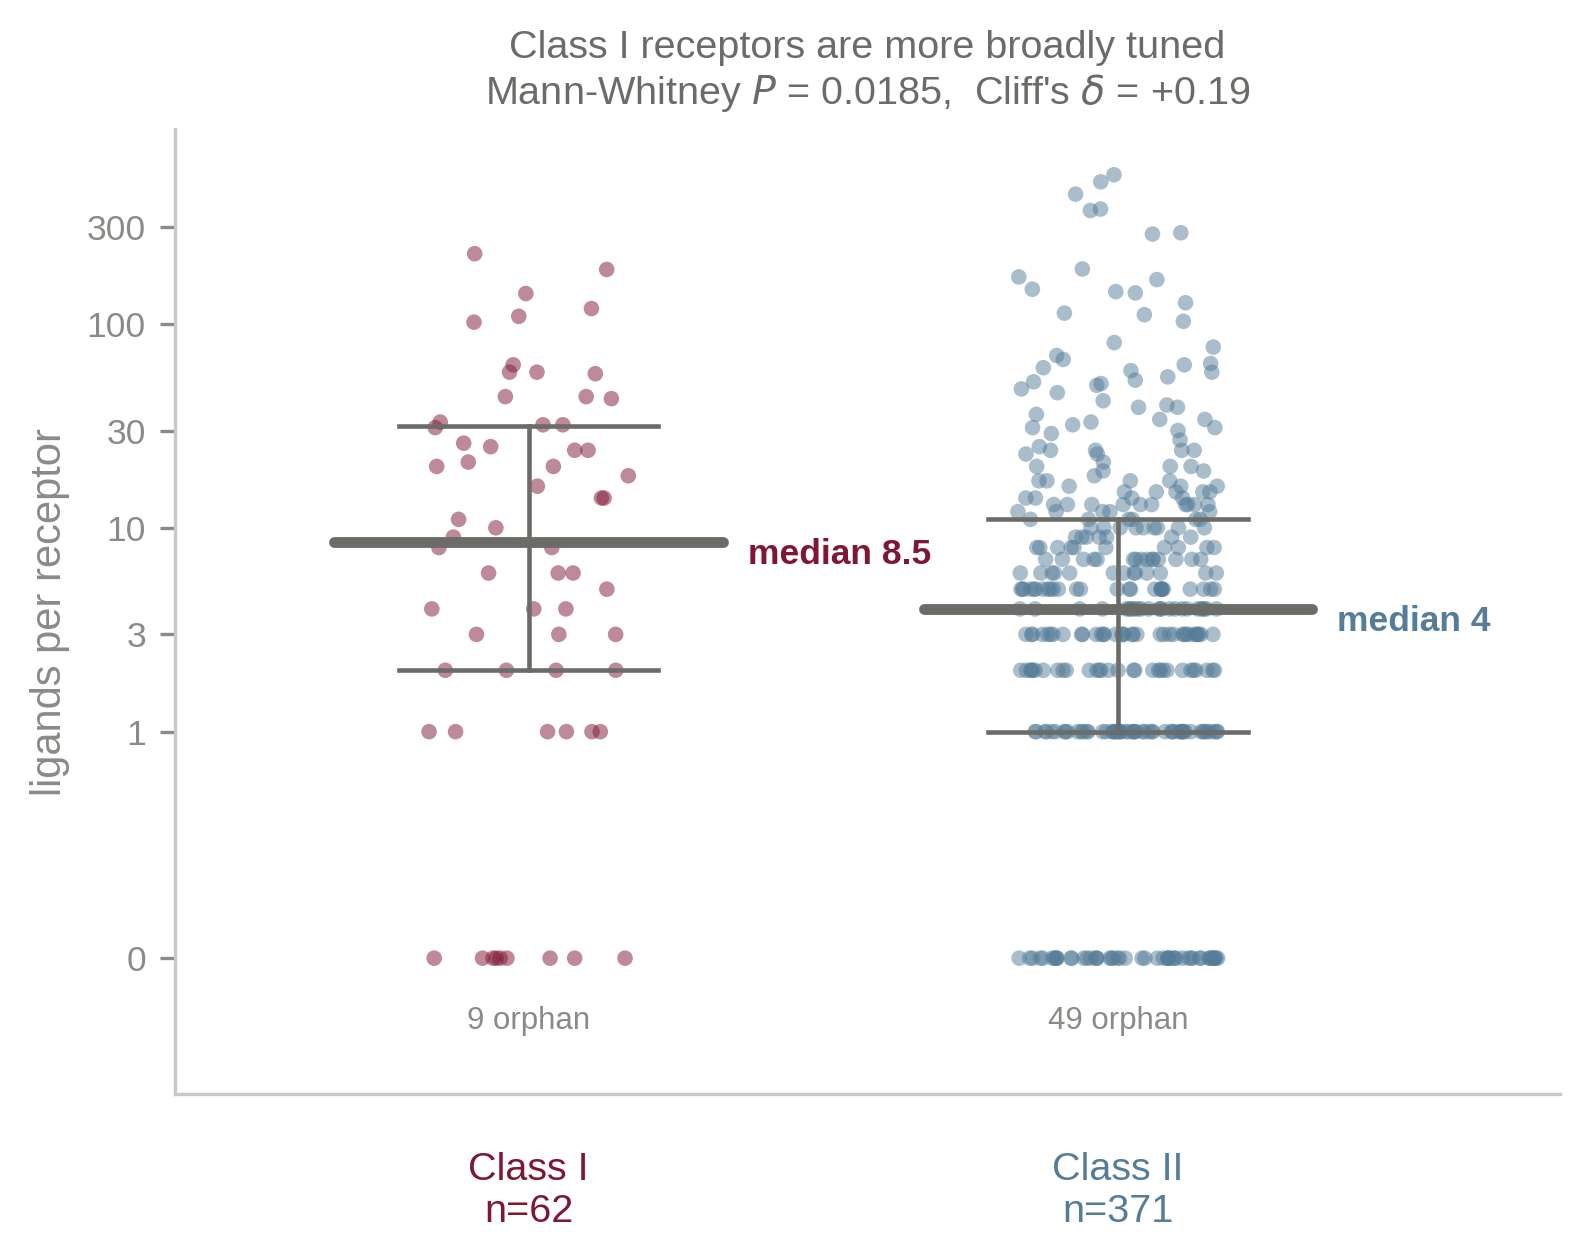

In [208]:
# Counts are discrete, zero-inflated and span 0-539, so no kernel and no bins: every receptor
# is drawn as one point, with median and IQR over the top. symlog keeps 0 a real position.
COLS = {"Class I": CLASS_I_COL, "Class II": CLASS_II_COL}
INK, MUTED = "#6b6b67", "#8a8a86"
TICKS = [0, 1, 3, 10, 30, 100, 300]
series = {"Class I": a_all, "Class II": b_all}

fig, ax = plt.subplots(figsize=(5.4, 4.3))
rng = np.random.default_rng(0)

for i, (k, v) in enumerate(series.items()):
    xj = i + rng.uniform(-0.17, 0.17, len(v))
    ax.scatter(xj, v, s=14, color=COLS[k], alpha=0.5, edgecolor="none", zorder=3)
    q1, med, q3 = np.percentile(v, [25, 50, 75])
    ax.plot([i - 0.33, i + 0.33], [med, med], color=INK, lw=2.6, zorder=5, solid_capstyle="round")
    ax.plot([i - 0.22, i + 0.22], [q1, q1], color=INK, lw=1.1, zorder=5)
    ax.plot([i - 0.22, i + 0.22], [q3, q3], color=INK, lw=1.1, zorder=5)
    ax.plot([i, i], [q1, q3], color=INK, lw=1.1, zorder=4)
    ax.annotate(f"median {med:g}", xy=(i + 0.33, med), xytext=(6, -3),
                textcoords="offset points", fontsize=8.5, color=COLS[k],
                fontweight="bold", va="center")
    ax.annotate(f"{(v == 0).sum()} orphan", xy=(i, 0), xytext=(0, -17),
                textcoords="offset points", fontsize=7.5, color=MUTED, ha="center")

ax.set_yscale("symlog", linthresh=1)
ax.set_yticks(TICKS); ax.set_yticklabels(TICKS, fontsize=8.5)
ax.set_ylim(-0.6, 900)
ax.set_xticks([0, 1])
ax.set_xticklabels([f"{k}\nn={len(v)}" for k, v in series.items()], fontsize=9.5)
for tl, k in zip(ax.get_xticklabels(), series): tl.set_color(COLS[k])
ax.set_xlim(-0.6, 1.75)
ax.set_ylabel("ligands per receptor", fontsize=10, color=MUTED)
ax.set_title(f"Class I receptors are more broadly tuned\n"
             f"Mann-Whitney $P$ = {p_all:.3g},  Cliff's $\\delta$ = {d_all:+.2f}",
             fontsize=9.5, color=INK)
ax.tick_params(axis="x", length=0, pad=14)
for sp in ["top", "right"]: ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTDIR}/class_tuning_breadth.svg", bbox_inches="tight")
plt.show()

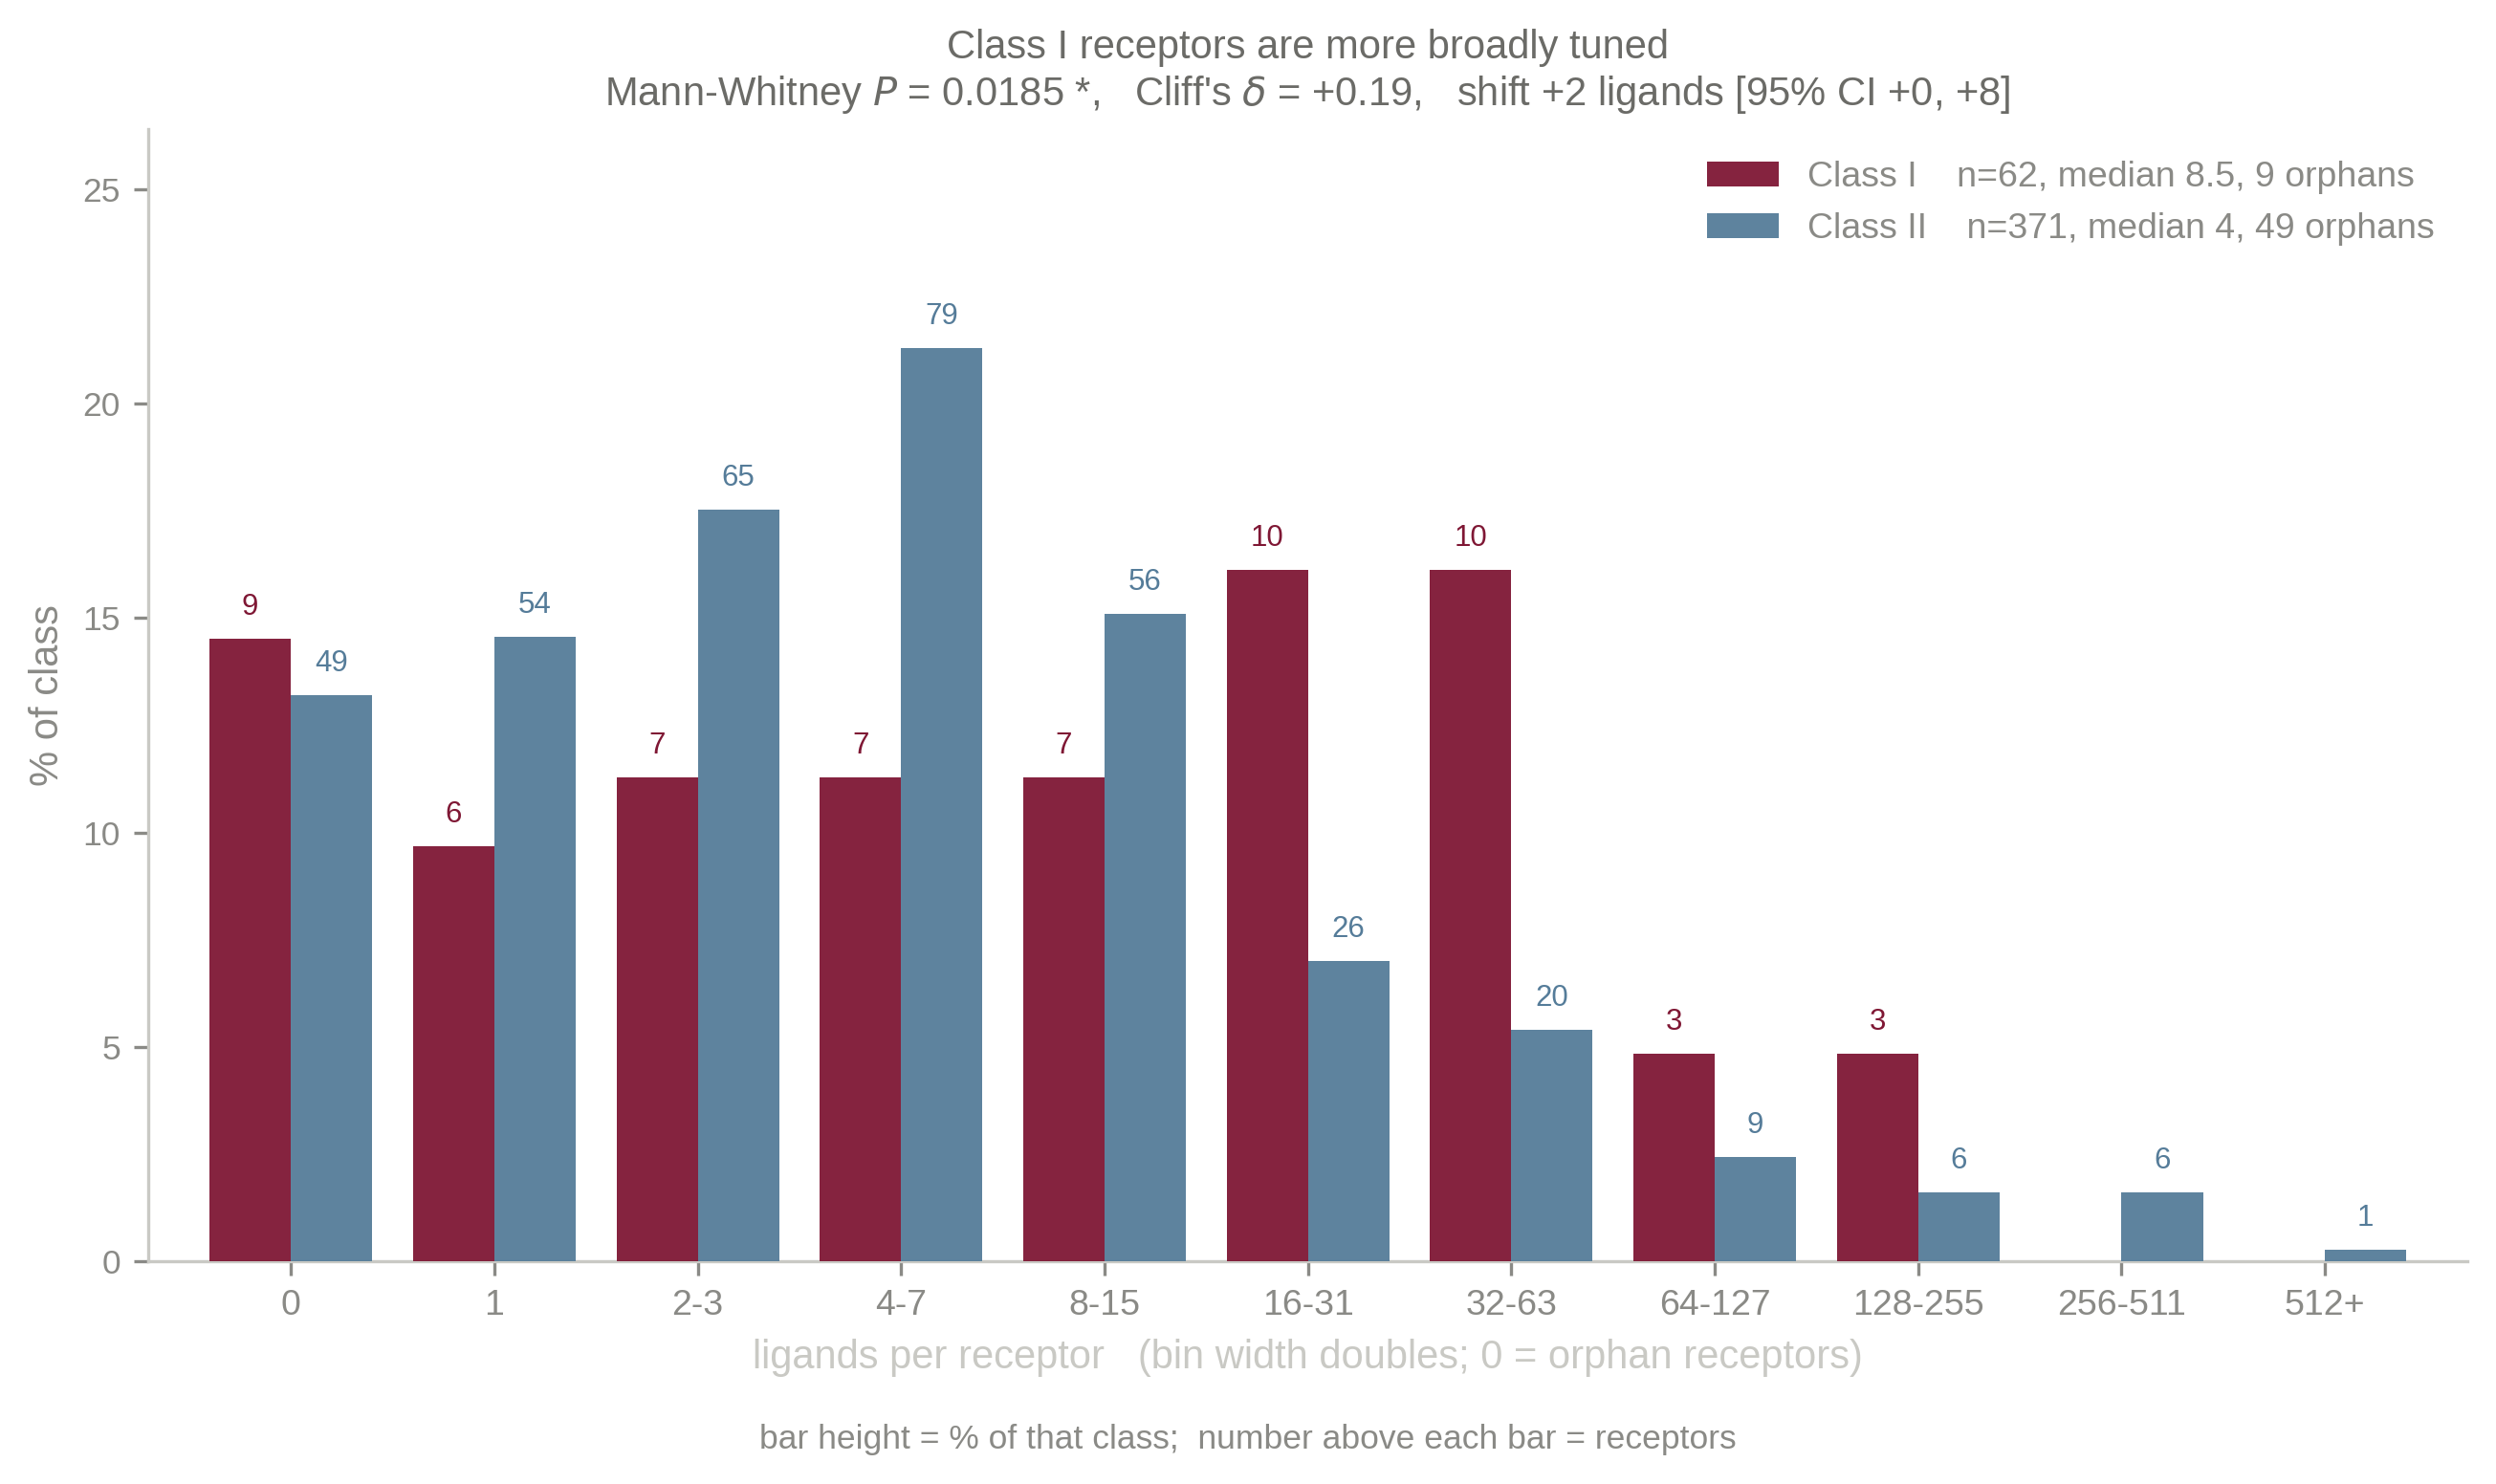

In [211]:
# The strip plot above shows every receptor as a point. This bins them, because "more
# broadly tuned" is a claim about where the mass of each class sits, and a pile of
# overlapping points is not the place to read that.
#
# Counts run 0-539 and are zero-inflated, so equal-width bins would put nearly every
# receptor in the first one. Bins double in width instead, and 0 keeps a bar of its own:
# an orphan is a different thing from a receptor with a single ligand, and lumping the
# two would hide exactly the tail this figure is about.
EDGES   = np.array([0, 1, 2, 4, 8, 16, 32, 64, 128, 256, 512, np.inf])
BIN_LBL = ["0", "1", "2-3", "4-7", "8-15", "16-31", "32-63", "64-127", "128-255",
           "256-511", "512+"]


def breadth_bins(v):
    """Receptors per doubling bin. Bin i holds EDGES[i] <= n < EDGES[i+1]."""
    return np.bincount(np.searchsorted(EDGES, v, side="right") - 1, minlength=len(BIN_LBL))


cnt = {"Class I": breadth_bins(a_all), "Class II": breadth_bins(b_all)}
last = max(np.nonzero(c)[0].max() for c in cnt.values()) + 1
cnt = {k: c[:last] for k, c in cnt.items()}
x = np.arange(last)
N = {"Class I": len(a_all), "Class II": len(b_all)}
MED = {"Class I": np.median(a_all), "Class II": np.median(b_all)}

# Bars are the % of each class, not raw counts. Class II has 371 receptors against Class
# I's 62, so on a shared count axis Class I is a sliver at every bin and the two shapes
# cannot be compared at all — which is the only thing this figure is for. The raw counts
# are printed above the bars, so nothing is hidden.
pct = {k: 100 * c / N[k] for k, c in cnt.items()}
LEG = {k: f"{k}    n={N[k]}, median {MED[k]:g}, {(v == 0).sum()} orphans"
       for k, v in [("Class I", a_all), ("Class II", b_all)]}
STAT = (f"Mann-Whitney $P$ = {p_all:.3g} {_stars(p_all)},   Cliff's $\\delta$ = {d_all:+.2f},"
        f"   shift {hl_all[0]:+.0f} ligands [95% CI {hl_all[1]:+.0f}, {hl_all[2]:+.0f}]")


def _finish(ax, note, ylab="% of class"):
    ax.set_xticks(x); ax.set_xticklabels(BIN_LBL[:last], fontsize=9)
    ax.set_xlim(-0.7, last - 0.3)
    ax.set_xlabel("ligands per receptor   (bin width doubles; 0 = orphan receptors)", fontsize=10)
    ax.set_ylabel(ylab, fontsize=10, color=MUTED)
    ax.tick_params(axis="y", labelsize=8.5)
    # fixed legend order: the overlay draws Class II first so Class I sits on top
    h, l = ax.get_legend_handles_labels()
    o = [l.index(LEG[k]) for k in ["Class I", "Class II"]]
    ax.legend([h[i] for i in o], [l[i] for i in o], frameon=False, fontsize=9, loc="upper right")
    ax.set_title(f"Class I receptors are more broadly tuned\n{STAT}", fontsize=10, color=INK)
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
    ax.figure.text(0.5, -0.02, note, ha="center", fontsize=8.5, color=MUTED)


# ---- grouped: one bar per class per bin, side by side ------------------------
w = 0.40
fig, ax = plt.subplots(figsize=(8.8, 5.0))
for off, k in [(-w / 2, "Class I"), (w / 2, "Class II")]:
    ax.bar(x + off, pct[k], width=w, color=COLS[k], alpha=0.95, zorder=3, label=LEG[k])
    for xi, (p, n) in enumerate(zip(pct[k], cnt[k])):
        if n:
            ax.text(xi + off, p + 0.4, str(n), ha="center", va="bottom", fontsize=7.5,
                    color=COLS[k], zorder=4)
ax.set_ylim(0, max(max(p) for p in pct.values()) * 1.24)
_finish(ax, "bar height = % of that class;  number above each bar = receptors")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/class_tuning_breadth_hist.svg", bbox_inches="tight")
plt.show()

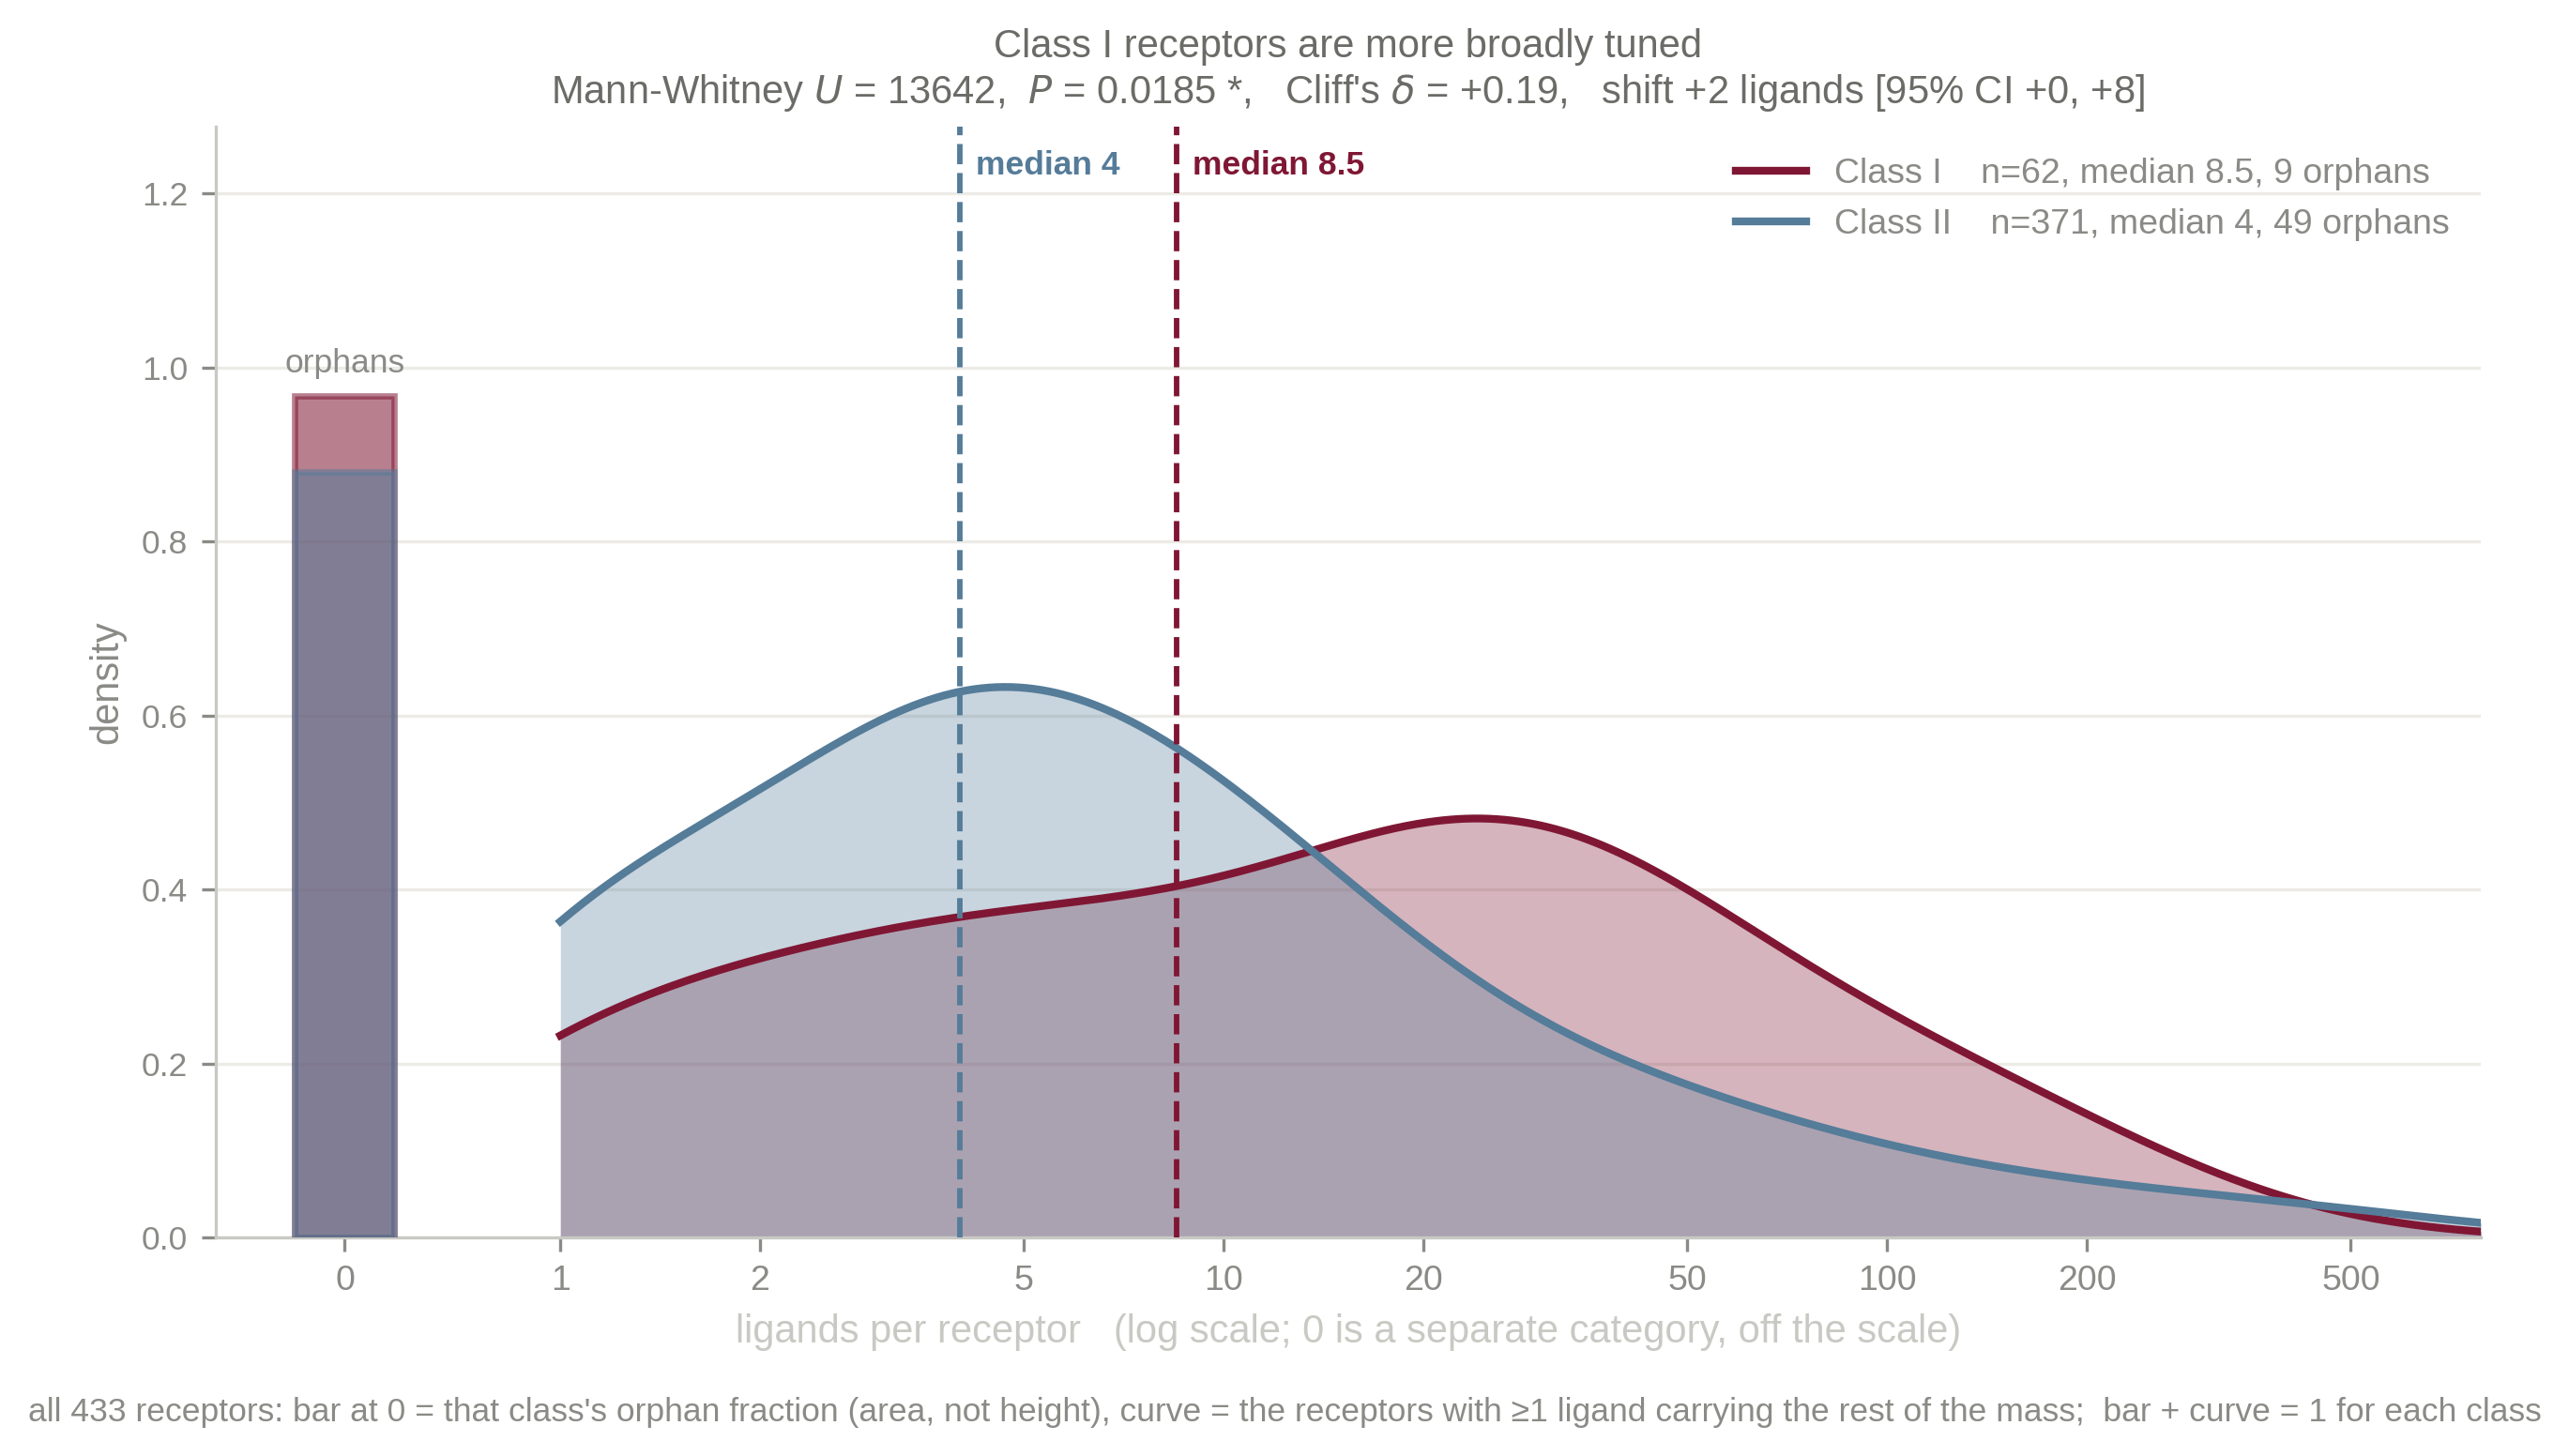

In [210]:
from scipy.stats import gaussian_kde

# Density instead of bins: no bin edges to argue about, and the two shapes lie over each
# other directly. Same 433 receptors as the print above and the binned figures, so the
# medians drawn here are the medians reported everywhere else in this section.
#
# Ligands per receptor is a zero-inflated variable: 13-15% of each class sits at exactly 0,
# and the rest runs over three orders of magnitude. Those are two different objects and the
# figure draws them as two:
#
#   * a BAR for the orphans, at 0. Its area is that class's orphan fraction, so it is a
#     probability, not a density height.
#   * a smooth DENSITY for the receptors with at least one ligand, scaled by the remaining
#     mass so bar + curve integrate to 1 for each class.
#
# Smoothing a point mass into the continuous part is what flattened the left of the earlier
# version: a kernel spread 58 receptors that bind nothing across the 0-3 ligand range, as if
# some of them bound one or two. Separating them is what lets each class show its actual
# shape, and log10 of the non-orphans is close to symmetric (skew -0.06 and +0.80).
U_all, _p = mannwhitneyu(a_all, b_all)
series = {"Class I": a_all, "Class II": b_all}
# The curve is on plain log10(ligands), NOT log10(ligands + 1). The +1 was only ever there
# to give zero a position on the axis, and the orphans have their own bar now. It is not a
# harmless shift: it compresses the low end — the gap between 1 and 2 ligands comes out 0.176
# against 0.301 between 16 and 32 — which inflates the density at 1-4 and buries the fact
# that Class II's mode is 4-7 ligands. On plain log10 every doubling is the same distance.
BAR_W = 0.15                       # bar width in log10 units; area = orphan fraction
BAR_X = -0.40                      # the orphan bar sits left of 1 ligand, off the log axis
LO = 0.0                           # log10(1): one ligand, lower bound of the continuous part
xs = np.linspace(LO, np.log10(max(a_all.max(), b_all.max())) * 1.06, 512)


def log_density(v, xs, frac=0.42):
    """Gaussian KDE of log10(v) over the non-orphans, truncated at one ligand.

    Gaussian for a smooth curve — Epanechnikov's discontinuous second derivative shows as
    ripples at these sample sizes.

    The kernel does not know the support stops at one ligand, so some mass falls to the
    left of it. Earlier versions folded that back by mirroring the sample about the bound.
    That is the right correction when nothing sits exactly on the bound, but 54 of Class
    II's 322 non-orphan receptors bind exactly one ligand, and reflecting them doubles the
    boundary and plants a false peak there: the binned counts (54, 65, 79, 56, 26, 20 over
    equal log-width bins) put Class II's mode at 4-7 ligands, and the reflected estimate
    said 1. So the estimate is truncated at the bound and renormalised instead, which
    reproduces 4-7 for Class II and 16-63 for Class I — both matching the bins.

    The curve is then scaled by the share of the class that is not an orphan, so it carries
    the right mass rather than integrating to 1 on its own.
    """
    v = np.asarray(v, float)
    nz = v[v > 0]
    d = gaussian_kde(np.log10(nz), bw_method=frac)(xs)
    return d / np.trapezoid(d, xs) * (len(nz) / len(v))


fig, ax = plt.subplots(figsize=(8.8, 5.0))
ymax = 0
for k, v in series.items():
    p0 = (v == 0).mean()
    ax.bar(BAR_X, p0 / BAR_W, width=BAR_W, align="edge", color=COLS[k], alpha=0.55,
           edgecolor=COLS[k], lw=1.6, zorder=3)
    d = log_density(v, xs); ymax = max(ymax, d.max(), p0 / BAR_W)
    ax.fill_between(xs, d, color=COLS[k], alpha=0.32, zorder=2, lw=0)
    ax.plot(xs, d, color=COLS[k], lw=2.0, zorder=4,
            label=f"{k}    n={len(v)}, median {np.median(v):g}, {(v == 0).sum()} orphans")
ax.set_ylim(0, ymax * 1.32)

# medians of the whole class, orphans included — the one number the eye cannot read off
for k, v in series.items():
    m = float(np.median(v))
    ax.axvline(np.log10(m), color=COLS[k], ls="--", lw=1.4, zorder=5)
    ax.annotate(f"median {m:g}", xy=(np.log10(m), ax.get_ylim()[1]), xytext=(4, -6),
                textcoords="offset points", fontsize=8.5, color=COLS[k],
                fontweight="bold", va="top")
ax.annotate("orphans", xy=(BAR_X + BAR_W / 2, ymax * 1.02), ha="center", va="bottom",
            fontsize=8.5, color=MUTED)

TICKS = [1, 2, 5, 10, 20, 50, 100, 200, 500]
ax.set_xticks([BAR_X + BAR_W / 2] + list(np.log10(TICKS)))
ax.set_xticklabels([0] + TICKS, fontsize=9)
ax.set_xlim(BAR_X - 0.12, xs[-1])
ax.set_xlabel("ligands per receptor   (log scale; 0 is a separate category, off the scale)",
              fontsize=10)
ax.set_ylabel("density", fontsize=10, color=MUTED)
ax.tick_params(axis="y", labelsize=8.5)
ax.grid(axis="y", color="#ecebe6", lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.set_title(f"Class I receptors are more broadly tuned\n"
             f"Mann-Whitney $U$ = {U_all:.0f},  $P$ = {p_all:.3g} {_stars(p_all)},   "
             f"Cliff's $\\delta$ = {d_all:+.2f},   shift {hl_all[0]:+.0f} ligands "
             f"[95% CI {hl_all[1]:+.0f}, {hl_all[2]:+.0f}]",
             fontsize=10, color=INK)
for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
fig.text(0.5, -0.02,
         "all 433 receptors: bar at 0 = that class's orphan fraction (area, not height), "
         "curve = the receptors with ≥1 ligand carrying the rest of the mass;  bar + curve = 1 "
         "for each class",
         ha="center", fontsize=8.5, color=MUTED)

plt.tight_layout()
plt.savefig(f"{OUTDIR}/class_tuning_breadth_density.svg", bbox_inches="tight")
plt.show()

## 12 · Where the odorants come from — aquatic or terrestrial sources

Class I receptors are the older branch and the one that dominates the fish repertoire, so
the standing reading is that they are tuned to the odour chemistry of water. Sections 9 and
10 support the **chemical** half of that: what Class I binds is the water-soluble,
acid-heavy end of the space. This section asks the **ecological** half, which is a separate
claim and does not follow from it — are the molecules Class I binds actually *isolated from
organisms that live in water*?

**Where habitat comes from.** COCONUT records the organisms a natural product was isolated
from but nothing about where those organisms live, so habitat is read off the organism's
place in the NCBI tree by `Chemicals/12_aquatic_sources.py`. Each organism's
lineage is walked from the tip upwards and the first labelled clade wins, which is what
makes the plant case work: COCONUT is overwhelmingly plants, and a seagrass or a lotus hits
its own aquatic family before it reaches `Embryophyta`. Macroalgae and the aquatic protists,
the entirely-aquatic animal phyla, fish, crustaceans and marine mammals are aquatic; land
plants, insects, arachnids and land vertebrates are terrestrial; mangroves are counted
separately, being land trees rooted in the intertidal; mammals and birds are *host* records
— compounds found in breath or milk rather than made by the animal — and are excluded, as
in `07_organism_source`. Bacteria and fungi are left unassigned: a *Streptomyces* is as likely to come from
marine sediment as from soil, and COCONUT does not say.

A molecule's **aquatic share** is aquatic ÷ (aquatic + terrestrial) over its source
organisms, so a molecule counts once no matter how well studied it is. `marine database` is
an independent check from a different kind of evidence — membership of CMNPD, Marine Natural
Products or SWMD — and never feeds the share.

**Coverage is the limit here, and it is severe.** Only 442 of the 499 molecules in the two
bags are in COCONUT with an organism annotation at all, and the exclusive sets come down to
69 and 51 molecules. Absence means nobody recorded a source, not that the compound has none.

### The answer is no

**Nothing separates the two classes by aquatic origin, and the measures do not even agree on
a direction.** The aquatic share is marginally higher for Class I (0.038 vs 0.032 in the
exclusive sets, *p* = 0.66) while its rank statistic points the other way; the prevalence of
molecules with any aquatic source is higher for Class II (54.9% vs 40.6%, *p* = 0.14); the
marine-database flag is higher for Class I (14.5% vs 7.8%, *p* = 0.39). Three measures,
three directions, nothing near significance. When the mean and the rank of the same quantity
disagree, and an independent flag disagrees with both, the honest reading is that there is
no signal — not that one of the three is the real one.

So the two halves of the standing reading come apart. **Class I prefers water-soluble
chemistry, but not chemistry from the water.** What it binds is mostly plant acids from dry
land, and its preference is a property of the molecules rather than of their ecology. That
is a cleaner statement than the panel could make before, and it is the same shape as the
volatility result in section 10: the class split is a chemical axis, and the things it is
*not* keep turning out to be the ones people assume it is.

**What is real in this data.** The one comparison that does separate them is whether the
molecule is a recorded natural product at all: **62.2% of Class I-only molecules against
45.5% of Class II-only** carry a COCONUT organism annotation (Fisher *p* = 0.016; it does
not survive in the diluted full bags, 59.4% vs 54.6%, *p* = 0.19). Class II's exclusive
ligands are the more synthetic set. That is worth stating carefully — COCONUT coverage is a
fact about the natural-products literature as much as about the molecules — but it is the
only row in this section that clears significance, and it is not the aquatic result.

**Power.** With 69 against 51 molecules, only a large effect would show. This rules out
Class I's ligands being *substantially* more aquatic in origin; it cannot rule out a small
difference, and it is not evidence that the two are identical.

Outputs: `aquatic_origin_hybrid_density` and `aquatic_origin_hybrid_density_exclusive`, plus
a CSV beside each, in the same shape as the section 10 panels so they sit together in a
figure.


In [ ]:
# Habitat of the source organisms, from Chemicals/12_aquatic_sources.py.
# That script needs the NCBI taxonomy dump; it writes one row per COCONUT molecule and is
# the only thing here that touches the 700 MB COCONUT csv.
CHEMSPACE = '../../../Chemicals'
AQ_SRC    = f'{CHEMSPACE}/results/aquatic_sources.csv'
PANEL_JOIN= f'{CHEMSPACE}/panel_universe_join.csv'

# Same shape as FOLD_BLOCKS. Two blocks because the denominators differ: the first row is
# over every molecule in the set, the rest only over those COCONUT knows a source for.
AQUATIC_BLOCKS=[
 ('found in nature at all',[
   ('in_coconut','recorded as a natural product','mean','%.0f%%')]),
 ('aquatic origin — among those with a recorded source',[
   ('any_aquatic','has an aquatic source organism','mean','%.0f%%'),
   ('share_aquatic','aquatic share of its sources','mean','%.3f'),
   ('marine_db','in a marine natural-product database','mean','%.0f%%'),
   ('n_aquatic','aquatic source organisms','mean','%.2f'),
   ('n_organisms','source organisms recorded','median','%.0f')]),
]


def aquatic_origin(Xbind,name,rate=None):
    """Do the two classes differ in how aquatic their odorants' source organisms are?"""
    grp,r0,rI,rII,bI,bII=class_partition(Xbind,rate)
    join=pd.read_csv(PANEL_JOIN)[['smiles_id','inchikey']]
    aq=pd.read_csv(AQ_SRC)
    df=(pd.DataFrame({'sml':lig_cols,'in_I':bI,'in_II':bII})
        .query('in_I or in_II')
        .merge(join,left_on='sml',right_on='smiles_id',how='left')
        .merge(aq,on='inchikey',how='left'))
    # A molecule COCONUT has never seen is not "zero aquatic sources", it is unknown --
    # so only in_coconut is filled in for it, and every other column stays NaN and drops
    # out of its own row's mean.
    df['in_coconut']=df.n_organisms.notna().astype(float)
    for c in ['any_aquatic','marine_db']:
        df[c]=df[c].map({True:1.0,False:0.0})
    print('aquatic origin %-13s molecules %d  in COCONUT %d  with a placed organism %d  '
          'with an aquatic source %d'
          %(name,len(df),int(df.in_coconut.sum()),int(df.share_aquatic.notna().sum()),
            int(np.nansum(df.any_aquatic))))

    aI=df.in_I.values; aII=df.in_II.values
    fold_change_figure(df,aI,aII,f'aquatic_origin_{name}',
        'Where the odorants come from — %s'%name,
        'every molecule each class binds  ·  Class I n=%d, Class II n=%d, %d in both\n'
        'habitat from the NCBI lineage of each recorded source organism; '
        'bacteria and fungi unassigned, mammals and birds excluded as host records'
        %(aI.sum(),aII.sum(),(aI&aII).sum()),
        'Class I binders','Class II binders',blocks=AQUATIC_BLOCKS)

    fold_change_figure(df,aI&~aII,aII&~aI,f'aquatic_origin_{name}_exclusive',
        'Where the odorants come from, exclusive sets — %s'%name,
        'the exclusive sets, no molecule in both  ·  Class I only n=%d, Class II only n=%d\n'
        'habitat from the NCBI lineage of each recorded source organism; '
        'bacteria and fungi unassigned, mammals and birds excluded as host records'
        %((aI&~aII).sum(),(aII&~aI).sum()),
        'Class I-only molecules','Class II-only molecules',blocks=AQUATIC_BLOCKS)
    return df


SHOW=True
aq_origin=aquatic_origin(hybrid_density,'hybrid_density')
SHOW=False


## 13 · What the two classes smell of — odour tags

The last view of the same two groupings, and the one that needs no chemistry to read. Every
molecule carrying an odour descriptor in `inchi_odors_smiles.csv` contributes its tags, and
the figure reports **the percentage of each class's tagged molecules that carry each tag**.

**The full-bag figure is percentages only; the exclusive figure is tested.** That is not a
change of mind, it is what the sets allow. A per-tag Fisher needs two independent samples:
the exclusive sets are disjoint and it holds, while the full bags share 276 molecules and it
does not — the same problem section 10 has, and there the fold-change panels solve it with a
permutation. So the exclusive figure carries stars and the full-bag one does not.

Read the stars with two things in mind. Tags are **not independent of one another** —
*sour*, *acidic* and *cheesy* largely travel on the same short-chain acids — so eight
significant rows are not eight separate findings; BH controls the false-discovery rate
across the family without making the rows independent. And 70 against 76 tagged molecules is
small: a tag at 10% against 3% is seven molecules against three.

**Denominator.** The percentage is over the molecules of that set that carry *any* tag, not
over the whole set: 295 of 387 in the Class I bag and 301 of 388 in the Class II bag; 70 of
111 and 76 of 112 in the exclusive sets. Untagged molecules are not counted as tagless, they
are simply absent from this figure.

**Which tags appear.** A tag is drawn if it reaches 8% of the tagged molecules in at least
one of the two sets — 21 tags for the full bags, 32 for the exclusive sets. The threshold is
a share rather than a count so the same rule works for both, and the full list of 144 tags,
plotted or not, is in the CSV. Rows are sorted by the gap, so the Class I side is at the top
and the Class II side at the bottom. BH runs over the tags drawn, which are exactly the tags
tested; the 8% cut is a prevalence filter applied before any *p* value is looked at, so
selecting on it does not bias the correction.

### What it shows

The exclusive sets separate on exactly the axis the chemistry predicted:

| Class I-only | | Class II-only | |
|---|---|---|---|
| sour | 20.0% vs 0.0% | floral | 14.3% vs 31.6% |
| cheesy | 18.6% vs 3.9% | powdery | 2.9% vs 19.7% |
| buttery | 15.7% vs 1.3% | fresh | 4.3% vs 21.1% |
| pineapple | 15.7% vs 1.3% | woody | 7.1% vs 21.1% |
| acidic | 11.4% vs 0.0% | citrus | 10.0% vs 23.7% |
| fatty | 25.7% vs 15.8% | musk | 1.4% vs 14.5% |

**Eight tags survive BH correction**, five on the Class I side — *sour* (`***`), *cheesy*,
*buttery*, *pineapple*, *acidic* — and three on the Class II side — *fresh*, *powdery*,
*musk*. *Floral* and *woody* miss at *q* = 0.061. *Fatty* and *fruity* carry the largest raw
gaps after the acids and do not come close: both are common in either set, and a ten-point
gap on a base of 30–40% is much weaker evidence than *sour* at 20% against zero.

**Class I-only is the sour, cheesy, buttery, fatty corner — which is what a set that is 47%
carboxylic acid smells like.** Butyric acid is cheesy, acetic is sour, and the short-chain
acids are exactly the molecules section 10 found there. *Pineapple* and *fruity* come with
the esters. **Class II-only is floral, woody, powdery, musky, citrus** — the terpenoid and
aromatic chemistry, matching its 2× aromatic rings. The odour language and the
cheminformatics are describing the same split.

In the full bags every gap collapses to a few points — *powdery* 7.5% vs 11.6% is the widest
— for the same reason as everywhere else in this notebook: 276 molecules sit in both sets.
The dilution is worth showing rather than hiding, since it is what makes the exclusive
figure the one to read.

Outputs: `odour_tags_hybrid_density` and `odour_tags_hybrid_density_exclusive`, plus
`odour_tags_hybrid_density_percentages.csv` with every tag and both comparisons — the
exclusive rows carry `p`, `q` and `stars`, the full-bag rows leave them empty.

To test the full bags too, `tag_percent_figure` would need section 10's permutation rather
than Fisher; `test=True` on overlapping sets raises instead of quietly returning the invalid
number.


In [ ]:
TAG_MIN_PCT = 8.0     # a tag is drawn if it reaches this share of one of the two sets


def tag_percentages(members):
    """tag -> % of this set's tagged molecules carrying it, plus the counts behind it."""
    tagged=[s for s in members if s in sml2tags_all]
    counts=Counter(t for s in tagged for t in sml2tags_all[s])
    n=len(tagged)
    return counts,n


def tag_percent_figure(mI,mII,fname,title,subtitle,nameI,nameII,min_pct=TAG_MIN_PCT,test=False):
    """Grouped bars: what share of each class's tagged molecules carries each odour tag."""
    cI,nI_=tag_percentages(np.array(lig_cols)[mI])
    cII,nII_=tag_percentages(np.array(lig_cols)[mII])
    rows=[]
    for t in set(cI)|set(cII):
        pI,pII=100*cI[t]/nI_,100*cII[t]/nII_
        rows.append(dict(tag=t,n_I=cI[t],n_II=cII[t],pct_I=pI,pct_II=pII,gap=pI-pII))
    tab=pd.DataFrame(rows).sort_values('gap',ascending=False).reset_index(drop=True)
    shown=tab[(tab.pct_I>=min_pct)|(tab.pct_II>=min_pct)].reset_index(drop=True)

    # Significance is opt-in and only offered where a per-tag test is actually valid.
    # Fisher needs two independent samples; the exclusive sets are disjoint, so it holds
    # there. The full bags share 276 molecules and it does not, which is why they are
    # drawn as percentages alone -- see section 10 for the same problem and the
    # permutation that solves it when the sets overlap.
    if test:
        if (mI&mII).any():
            raise ValueError('per-tag Fisher needs disjoint sets; these overlap')
        pv=[fisher_exact([[r.n_I,nI_-r.n_I],[r.n_II,nII_-r.n_II]])[1]
            for r in shown.itertuples()]
        # BH over the tags drawn, which are the tags tested. The 8% filter is a
        # prevalence cut applied before any p value is looked at, so selecting on it
        # does not bias the correction.
        shown['p']=pv; shown['q']=bh(np.array(pv))
        shown['stars']=[_stars(q) or 'ns' for q in shown.q]
        tab=tab.merge(shown[['tag','p','q','stars']],on='tag',how='left')

    yy=np.arange(len(shown))[::-1]; h=0.38
    H=max(4.6,3.1+0.40*len(shown))
    fig,ax=plt.subplots(figsize=(9.6,H))
    ax.barh(yy+h/2,shown.pct_I,height=h,color=CLASS_I_COL,alpha=0.92,label='%s  (n=%d tagged)'%(nameI,nI_))
    ax.barh(yy-h/2,shown.pct_II,height=h,color=CLASS_II_COL,alpha=0.92,label='%s  (n=%d tagged)'%(nameII,nII_))
    xm=max(shown.pct_I.max(),shown.pct_II.max())
    for y,r in zip(yy,shown.itertuples()):
        ax.text(r.pct_I+xm*0.012,y+h/2,'%.0f%%'%r.pct_I,va='center',fontsize=8,color='#4a4a46')
        ax.text(r.pct_II+xm*0.012,y-h/2,'%.0f%%'%r.pct_II,va='center',fontsize=8,color='#4a4a46')
    for y in yy[:-1]: ax.axhline(y-0.5,color='#f0eee9',lw=0.8,zorder=0)
    # Stars in a column of their own: the test is on the tag, not on either bar, so
    # hanging them off one bar's end would read as belonging to that bar.
    if test:
        for y,s in zip(yy,shown.stars):
            ax.text(xm*1.13,y,s,ha='center',va='center',fontsize=8.6,
                    color='#4a4a46' if s!='ns' else '#b9b9b4')
    ax.set_yticks(yy); ax.set_yticklabels(shown.tag,fontsize=9.5)
    ax.set_ylim(yy.min()-0.7,yy.max()+0.7); ax.set_xlim(0,xm*(1.20 if test else 1.10))
    ax.tick_params(axis='y',length=0)
    ax.set_xlabel('% of the set\'s tagged molecules carrying the tag',fontsize=10)
    for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
    ax.spines['bottom'].set_color('#c9c9c4')
    # Legend above the axes rather than inside it: the longest bars move between the two
    # comparisons, so any in-plot corner collides with something eventually.
    ax.legend(frameon=False,fontsize=9,handlelength=1.2,ncol=2,
              loc='lower center',bbox_to_anchor=(0.5,1.004))
    fig.suptitle(title,fontsize=12.5,fontweight='bold',color='#6b6b67',y=1-0.18/H)
    fig.text(0.5,1-0.60/H,subtitle,ha='center',fontsize=9.4,color='#8a8a86')
    note=('Fisher one tag at a time, BH over the %d tags drawn:  * < 0.05   ** < 0.01   '
          '*** < 0.001'%len(shown)) if test else \
         'percentages only — the two sets overlap, so a per-tag test would not be valid'
    fig.text(0.5,0.18/H,'sorted by the gap  ·  a tag is drawn if it reaches %g%% of one set\n%s'
             %(min_pct,note),ha='center',fontsize=8.4,color='#8a8a86',linespacing=1.5)
    fig.subplots_adjust(top=1-1.20/H,bottom=1.15/H,left=0.17,right=0.97)
    save(fig,fname)
    print('  %-38s tags drawn %2d of %d  |  top I: %s  |  top II: %s'
          %(fname,len(shown),len(tab),', '.join(tab.tag.head(3)),', '.join(tab.tag.tail(3)[::-1])))
    return tab


def odour_tags(Xbind,name,rate=None):
    """Odour-tag composition of the two classes, both set definitions."""
    grp,r0,rI,rII,bI,bII=class_partition(Xbind,rate)
    out=[]
    for tag,mI,mII,ttl,sub,lI,lII in [
        ('', bI, bII,
         'What the two classes smell of — %s'%name,
         'every molecule each class binds, shared molecules counted in both',
         'Class I binders','Class II binders'),
        ('_exclusive', bI&~bII, bII&~bI,
         'What the two classes smell of, exclusive sets — %s'%name,
         'the exclusive sets, no molecule in both',
         'Class I-only molecules','Class II-only molecules')]:
        t=tag_percent_figure(mI,mII,f'odour_tags_{name}{tag}',ttl,sub,lI,lII,
                             test=bool(tag))          # exclusive sets only
        t.insert(0,'comparison','exclusive' if tag else 'full bags')
        out.append(t)
    tab=pd.concat(out,ignore_index=True)
    sig=tab[(tab.comparison=='exclusive')&(tab.q<0.05)] if 'q' in tab else tab.iloc[:0]
    if len(sig):
        print('  exclusive, BH q<0.05: '+'  '.join(
            '%s %.0f/%.0f%%%s'%(r.tag,r.pct_I,r.pct_II,r.stars) for r in sig.itertuples()))
    tab.to_csv(f'{OUTDIR}/odour_tags_{name}_percentages.csv',index=False)
    return tab


SHOW=True
odour_tab=odour_tags(hybrid_density,'hybrid_density')
SHOW=False


## Notes

- **Binarisation.** `hybrid_density` is the main matrix: isotonic calibration sets *how many*
  cells are on, rank sets *which*, and the 23,782 measurements are written over the top. The
  density cut is an output of the fill, never an input. `baseline` (p ≥ 0.50) is kept as the
  released model default for reference.
- **The rate-matched cut (~0.915) builds nothing here.** It remains the reported per-pair
  classification operating point in `01.model_behaviour`; applied to the grid it under-fills,
  because recall at that cut is ~0.6.
- **Orphan receptors.** `hybrid_density` leaves more orphans than a plain threshold at the
  same cut would. That is the overlay working: a receptor whose only above-cut cell was tested
  and measured negative loses it. Those are model false positives M2OR already disproved. The
  decomposition is printed in section 7.
- **Methods sentence.** At a fixed model score, tested and untested pairs are assumed to bind
  at the same rate.
- The calibration map lives in `../../scripts/calibration.py` and is fitted once, on tested
  cells only. The ancestral notebooks import the same map and apply steps 1–4 with no
  experimental overlay — one calibration, defined in one place.
- Per matrix: `heatmap_{name}` (co-tuning row order), `heatmap_{name}_tree_order`
  (phylogenetic), `enrichbar_{name}`, `enrichment_table_{name}` (+ `.csv`), `pcoa_{name}`,
  and `enrichment_{name}.csv`, which keeps every test rather than only the significant ones.
- **Cluster chemistry (section 9)** and **class chemistry (section 10)** answer the same
  question of two different groupings, off one descriptor panel and one SMARTS set, both
  defined in section 9. Each writes `chemspace_*`, `chemspace_*_groups`,
  `chemspace_*_effects` and a descriptor CSV; section 10 also writes
  `chemspace_*_effects_exclusive`, `chemspace_*_effects_cliffs`, and a CSV beside each of
  its two fold-change figures. Both use `hybrid_density`; pass another matrix to
  `chemical_space(...)`, or another partition to `cluster_chemistry(...)`.
- **The two `_effects` figures are not the same statistic.** Section 9's is Cliff's delta,
  cluster against the pooled rest — disjoint groups, so a rank test applies. Section 10's
  is a fold change between two overlapping bags, tested by permuting the exclusive labels.
  Read the section 10 header before comparing a number from one against the other.
- The old `chemistry_clusters_{name}` violin figure (rings, sp³, LogP) is gone — section 9
  covers those three descriptors and seven more, plus the functional groups.
- **Section 12 depends on a second pipeline.** `Chemicals/12_aquatic_sources.py`
  writes `results/aquatic_sources.csv` from COCONUT plus the NCBI taxonomy dump, and this
  notebook only joins it. Re-run that script if COCONUT is updated; the join key is the
  InChIKey in `panel_universe_join.csv`. Its result is a null one, which is why the section
  states the coverage and the power rather than only the *p* values.
- **Section 13 tests the exclusive sets only.** Fisher one tag at a time with BH over the
  tags drawn, valid because those two sets are disjoint. The full bags share 276 molecules,
  so that figure stays percentages-only rather than carrying a test it cannot support. Tags
  are correlated with one another and the tagged subset is not the whole set, so read a
  column of stars as one story about acids and one about terpenoids, not as eight
  independent results.
- Frozen decisions are untouched: exact amino-acid sequence matching for the experimental
  layer, Jaccard + PAM k=6, and the hypergeometric + BH enrichment test.

### Ordering inside a cluster

PAM gives a flat partition — six clusters, no nesting. Inside each cluster the columns are
ordered by average-linkage hierarchical clustering on the same Jaccard distance
(`leaves_list`), and the receptor rows likewise. That is **seriation only**: it decides where
a column is drawn, never which cluster it belongs to. No sub-clusters are defined and no
dendrogram is shown, because PAM never computed one.